# Projet 6 - Élaborez un modèle de scoring
# A. EDA on imported data

In [1]:
!pip install missingno

import missingno as msno

In [277]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("Projet+Mise+en+prod+-+home-credit-default-risk")

fichiers = {
    "application_test" : "application_test.csv",
    "application_train" : "application_train.csv",
    "bureau_balance" : "bureau_balance.csv",
    "bureau" : "bureau.csv",
    "credit_card_balance" : "credit_card_balance.csv",
    "installments_payments" : "installments_payments.csv",
    "POS_CASH" : "POS_CASH_balance.csv",
    "prev_application" : "previous_application.csv",
    "sample_submission" : "sample_submission.csv",
}

# For loop  
dfs = {}  # empty dictionary at first
for nom, fichier in fichiers.items():
    dfs[nom] = pd.read_csv(DATA_DIR / fichier)

# access : dfs["application_train"], dfs["bureau"], etc.

columns_description = pd.read_csv(DATA_DIR / "HomeCredit_columns_description.csv", encoding="cp1252") 

##### 1. columns_description table

In [278]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(columns_description)

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


##### 2. POS_CASH table

In [279]:
dfs['POS_CASH']

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.00,45.00,Active,0,0
1,1715348,367990,-33,36.00,35.00,Active,0,0
2,1784872,397406,-32,12.00,9.00,Active,0,0
3,1903291,269225,-35,48.00,42.00,Active,0,0
4,2341044,334279,-35,36.00,35.00,Active,0,0
...,...,...,...,...,...,...,...,...
10001353,2448283,226558,-20,6.00,0.00,Active,843,0
10001354,1717234,141565,-19,12.00,0.00,Active,602,0
10001355,1283126,315695,-21,10.00,0.00,Active,609,0
10001356,1082516,450255,-22,12.00,0.00,Active,614,0


In [280]:
dfs['POS_CASH'].info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


In [281]:
((dfs['POS_CASH'].isnull().sum() / len(dfs['POS_CASH'])) * 100).round(2)

SK_ID_PREV              0.00
SK_ID_CURR              0.00
MONTHS_BALANCE          0.00
CNT_INSTALMENT          0.26
CNT_INSTALMENT_FUTURE   0.26
NAME_CONTRACT_STATUS    0.00
SK_DPD                  0.00
SK_DPD_DEF              0.00
dtype: float64

<Axes: >

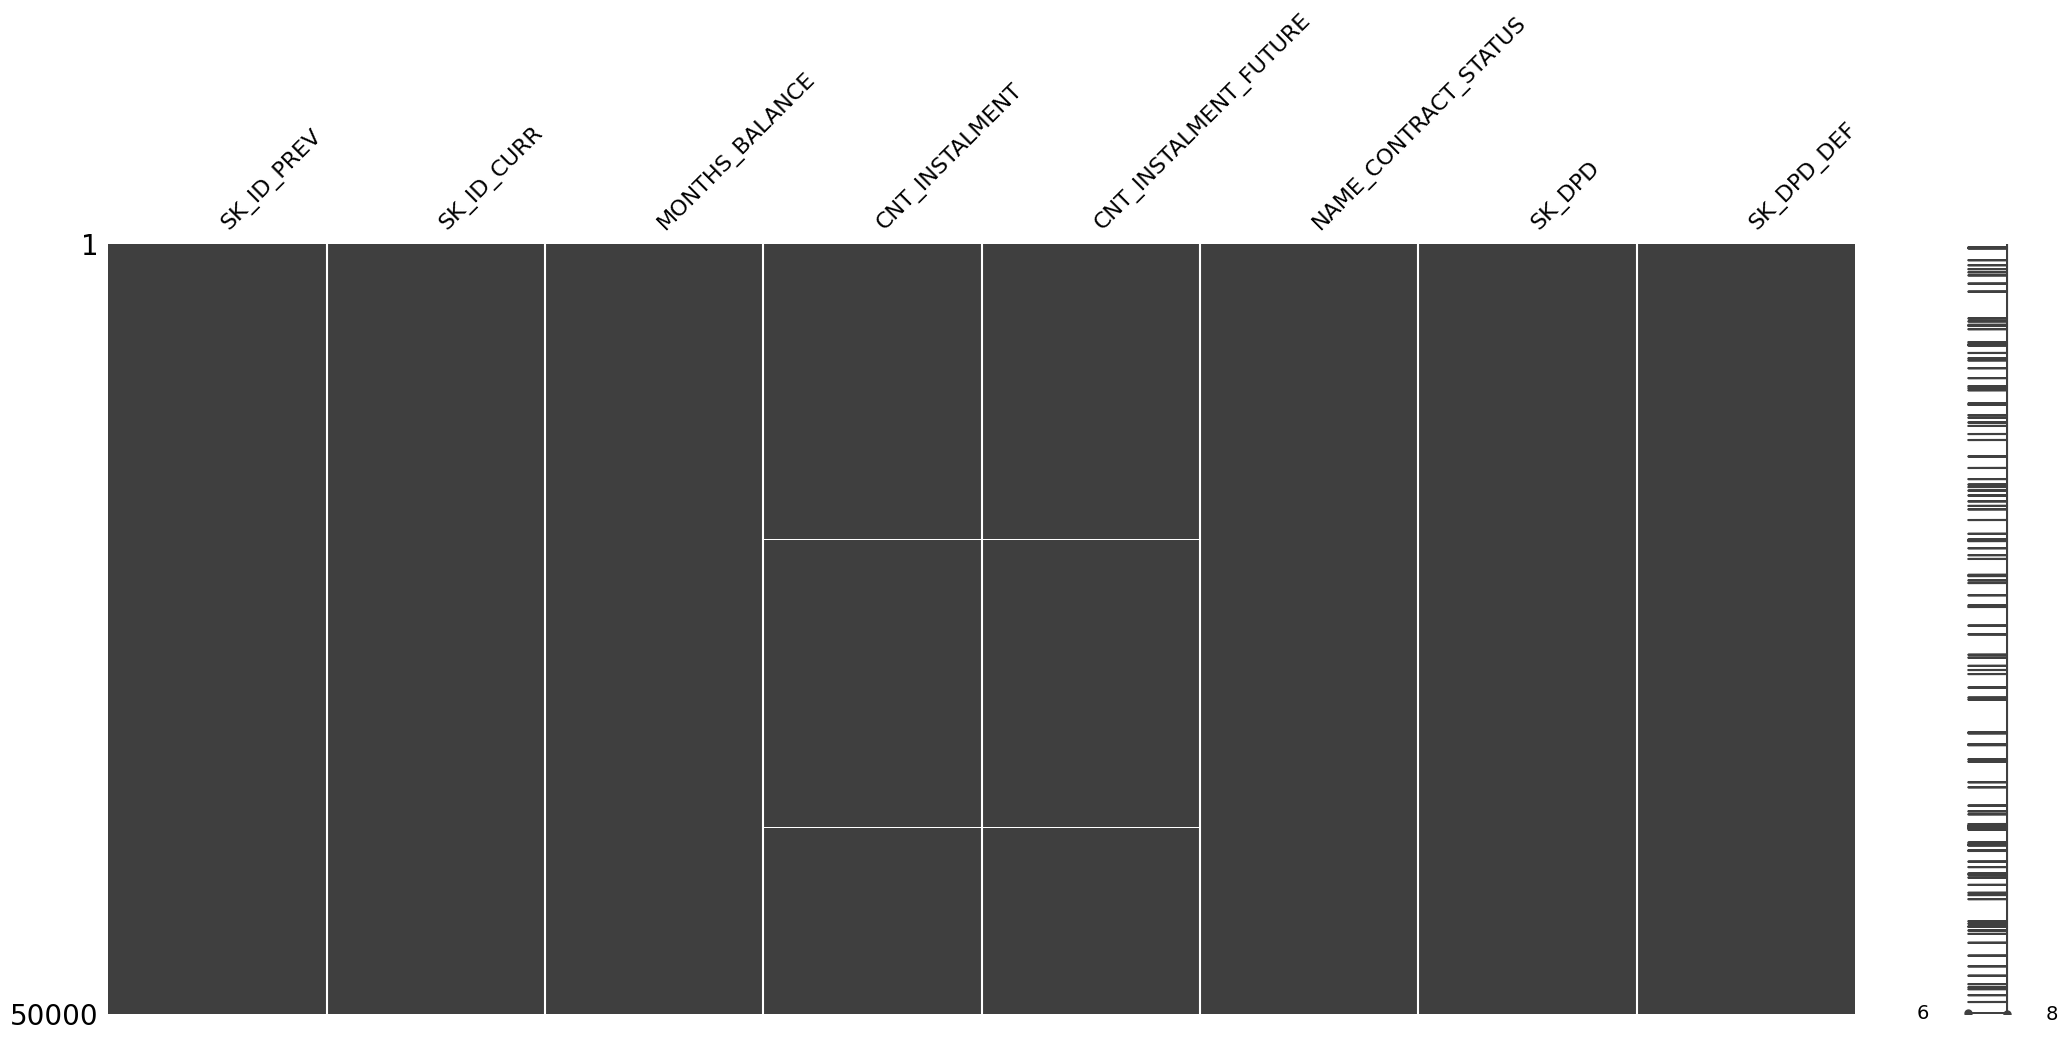

In [299]:
%matplotlib inline
msno.matrix(dfs['POS_CASH'].sample(50000))

In [300]:
dfs['POS_CASH'].dtypes

SK_ID_PREV                 int64
SK_ID_CURR                 int64
MONTHS_BALANCE             int64
CNT_INSTALMENT           float64
CNT_INSTALMENT_FUTURE    float64
NAME_CONTRACT_STATUS      object
SK_DPD                     int64
SK_DPD_DEF                 int64
dtype: object

In [301]:
dfs['POS_CASH'].value_counts()

SK_ID_PREV  SK_ID_CURR  MONTHS_BALANCE  CNT_INSTALMENT  CNT_INSTALMENT_FUTURE  NAME_CONTRACT_STATUS  SK_DPD  SK_DPD_DEF
1000001     158271      -10             12.00           12.00                  Active                0       0             1
2211150     122580      -75             12.00           0.00                   Completed             0       0             1
                        -82             12.00           7.00                   Active                0       0             1
                        -81             12.00           6.00                   Active                0       0             1
                        -80             12.00           5.00                   Active                0       0             1
                                                                                                                          ..
1576022     145134      -27             10.00           10.00                  Active                0       0             1
     

In [302]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['POS_CASH'].nunique().sort_values(ascending=False)
    )

SK_ID_PREV               936325
SK_ID_CURR               337252
SK_DPD                     3400
SK_DPD_DEF                 2307
MONTHS_BALANCE               96
CNT_INSTALMENT_FUTURE        79
CNT_INSTALMENT               73
NAME_CONTRACT_STATUS          9
dtype: int64

In [303]:
for col in ['MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS']:
    print(f'{col}', dfs["POS_CASH"][col].unique(), '\n')

MONTHS_BALANCE [-31 -33 -32 -35 -38 -39 -34 -41 -37 -40 -43 -36 -42 -47 -44 -46 -45 -27
 -25 -24 -30 -28 -26 -29 -48 -15 -19 -22 -14 -18 -16 -21 -17 -20 -23  -1
  -6  -2  -3  -5  -4 -13 -11 -10  -9  -7  -8 -54 -49 -52 -53 -50 -51 -55
 -12 -94 -95 -92 -91 -96 -93 -57 -64 -56 -59 -60 -66 -65 -58 -63 -62 -61
 -87 -86 -88 -89 -90 -72 -74 -73 -82 -78 -81 -75 -77 -80 -76 -79 -69 -70
 -71 -68 -67 -83 -85 -84] 

CNT_INSTALMENT [48. 36. 12. 24. 60. 18.  4. 42. 25. 14. 16. 13.  8. 10. 15. 11. 30. 54.
  6.  9.  5. 17.  3.  2. 20. 32. nan  1.  7. 47. 49. 28. 43. 23. 21. 19.
 39. 37. 35. 27. 22. 41. 31. 61. 26. 34. 29. 44. 55. 33. 66. 46. 59. 38.
 72. 40. 57. 45. 92. 56. 84. 51. 52. 58. 62. 53. 64. 50. 77. 70. 81. 63.
 71. 68.] 

CNT_INSTALMENT_FUTURE [45. 35.  9. 42. 12. 43. 36. 16. 24.  5. 15.  1. 28. 23. 56. 11.  7. 18.
 17. 46. 21.  0.  4. 40. 32. 19.  8. 10.  2. 13. 14.  3.  6. 48. 22. 34.
 47. 30. 29. 41. 54. 20. 37. 31. 27. 26. nan 25. 38. 33. 39. 53. 58. 50.
 51. 52. 55. 59. 57. 60. 49. 44.

In [304]:
dfs['POS_CASH'].describe().round(2)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,SK_DPD,SK_DPD_DEF
count,"10,001,358.00","10,001,358.00","10,001,358.00","9,975,287.00","9,975,271.00","10,001,358.00","10,001,358.00"
mean,"1,903,216.60","278,403.86",-35.01,17.09,10.48,11.61,0.65
std,"535,846.53","102,763.75",26.07,12.00,11.11,132.71,32.76
min,"1,000,001.00","100,001.00",-96.00,1.00,0.00,0.00,0.00
25%,"1,434,405.00","189,550.00",-54.00,10.00,3.00,0.00,0.00
50%,"1,896,565.00","278,654.00",-28.00,12.00,7.00,0.00,0.00
75%,"2,368,963.00","367,429.00",-13.00,24.00,14.00,0.00,0.00
max,"2,843,499.00","456,255.00",-1.00,92.00,85.00,"4,231.00","3,595.00"


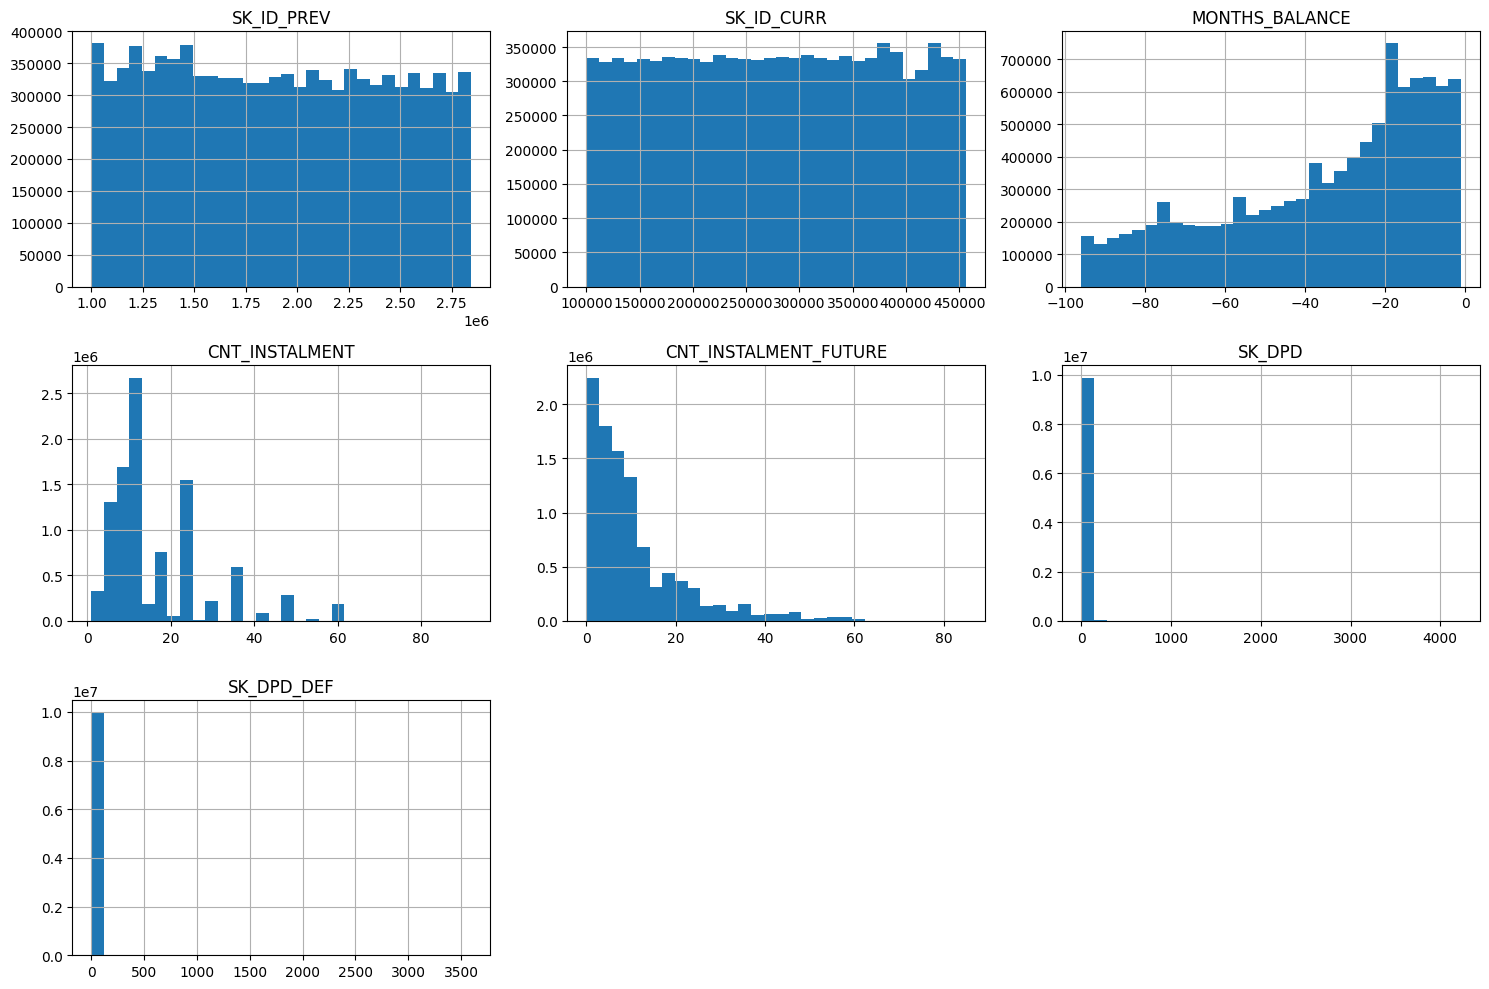

In [305]:
import matplotlib.pyplot as plt

dfs["POS_CASH"].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

In [306]:
dfs["POS_CASH"]["NAME_CONTRACT_STATUS"].value_counts()

NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2
Name: count, dtype: int64

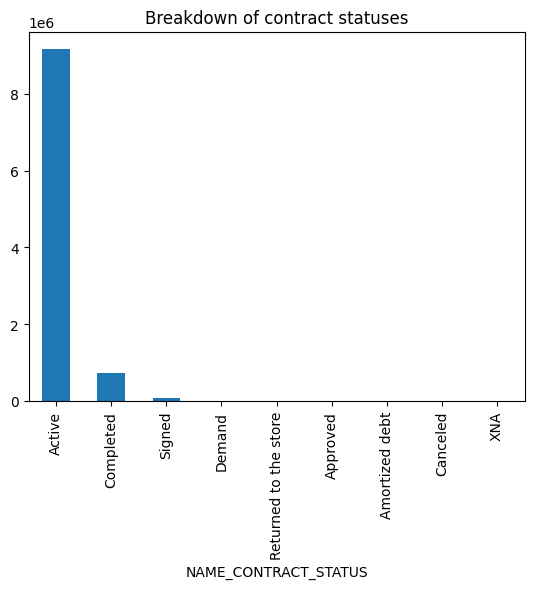

In [307]:
dfs["POS_CASH"]["NAME_CONTRACT_STATUS"].value_counts().plot(kind="bar")
plt.title("Breakdown of contract statuses")
plt.show()

##### 3. application_train table

In [308]:
with pd.option_context('display.max_columns', None):
    display(dfs['application_train'])

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,"-3,648.00",-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,"-1,134.00",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,"-1,186.00",-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,"-4,260.00",-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0

In [309]:
dfs['application_train'].info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [310]:
with pd.option_context('display.max_rows', 130):
    display(
        (dfs['application_train'].isnull().sum() / len(dfs['application_train']) * 100)
        .round(2)
        .sort_values(ascending=False)
    )

COMMONAREA_MEDI                69.87
COMMONAREA_AVG                 69.87
COMMONAREA_MODE                69.87
NONLIVINGAPARTMENTS_MODE       69.43
NONLIVINGAPARTMENTS_AVG        69.43
NONLIVINGAPARTMENTS_MEDI       69.43
FONDKAPREMONT_MODE             68.39
LIVINGAPARTMENTS_MODE          68.35
LIVINGAPARTMENTS_AVG           68.35
LIVINGAPARTMENTS_MEDI          68.35
FLOORSMIN_AVG                  67.85
FLOORSMIN_MODE                 67.85
FLOORSMIN_MEDI                 67.85
YEARS_BUILD_MEDI               66.50
YEARS_BUILD_MODE               66.50
YEARS_BUILD_AVG                66.50
OWN_CAR_AGE                    65.99
LANDAREA_MEDI                  59.38
LANDAREA_MODE                  59.38
LANDAREA_AVG                   59.38
BASEMENTAREA_MEDI              58.52
BASEMENTAREA_AVG               58.52
BASEMENTAREA_MODE              58.52
EXT_SOURCE_1                   56.38
NONLIVINGAREA_MODE             55.18
NONLIVINGAREA_AVG              55.18
NONLIVINGAREA_MEDI             55.18
E

<Axes: >

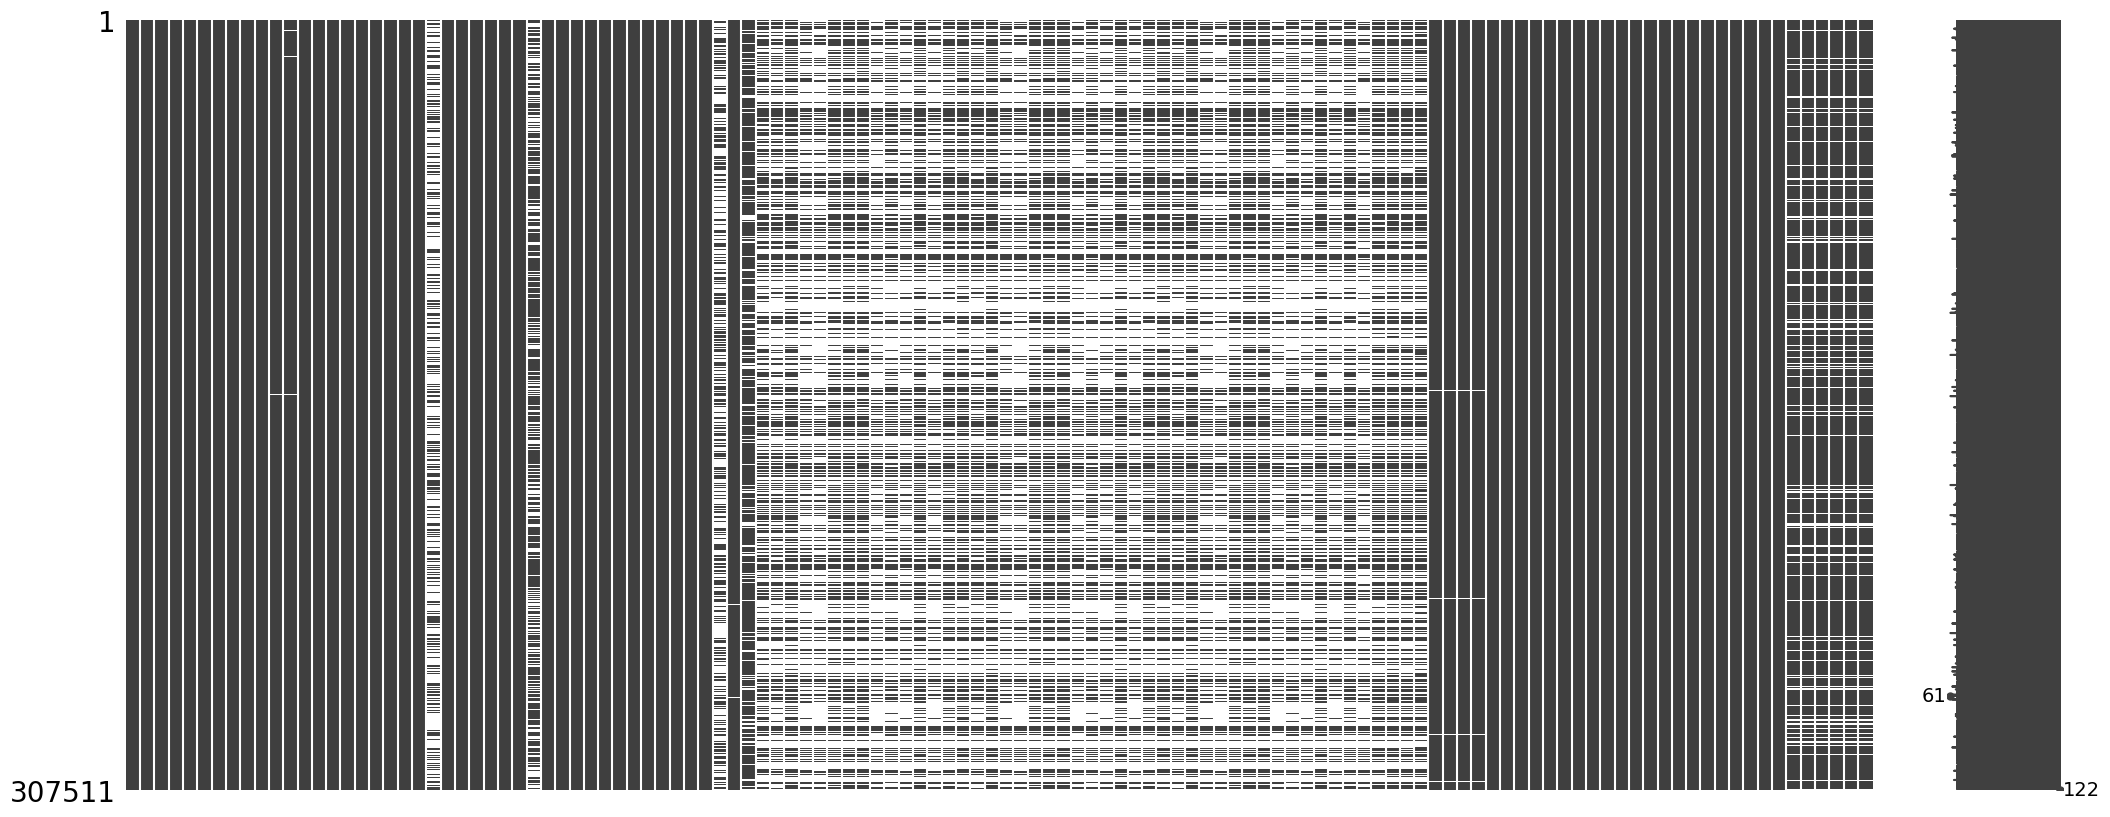

In [311]:
%matplotlib inline
msno.matrix(dfs['application_train'])

<Axes: >

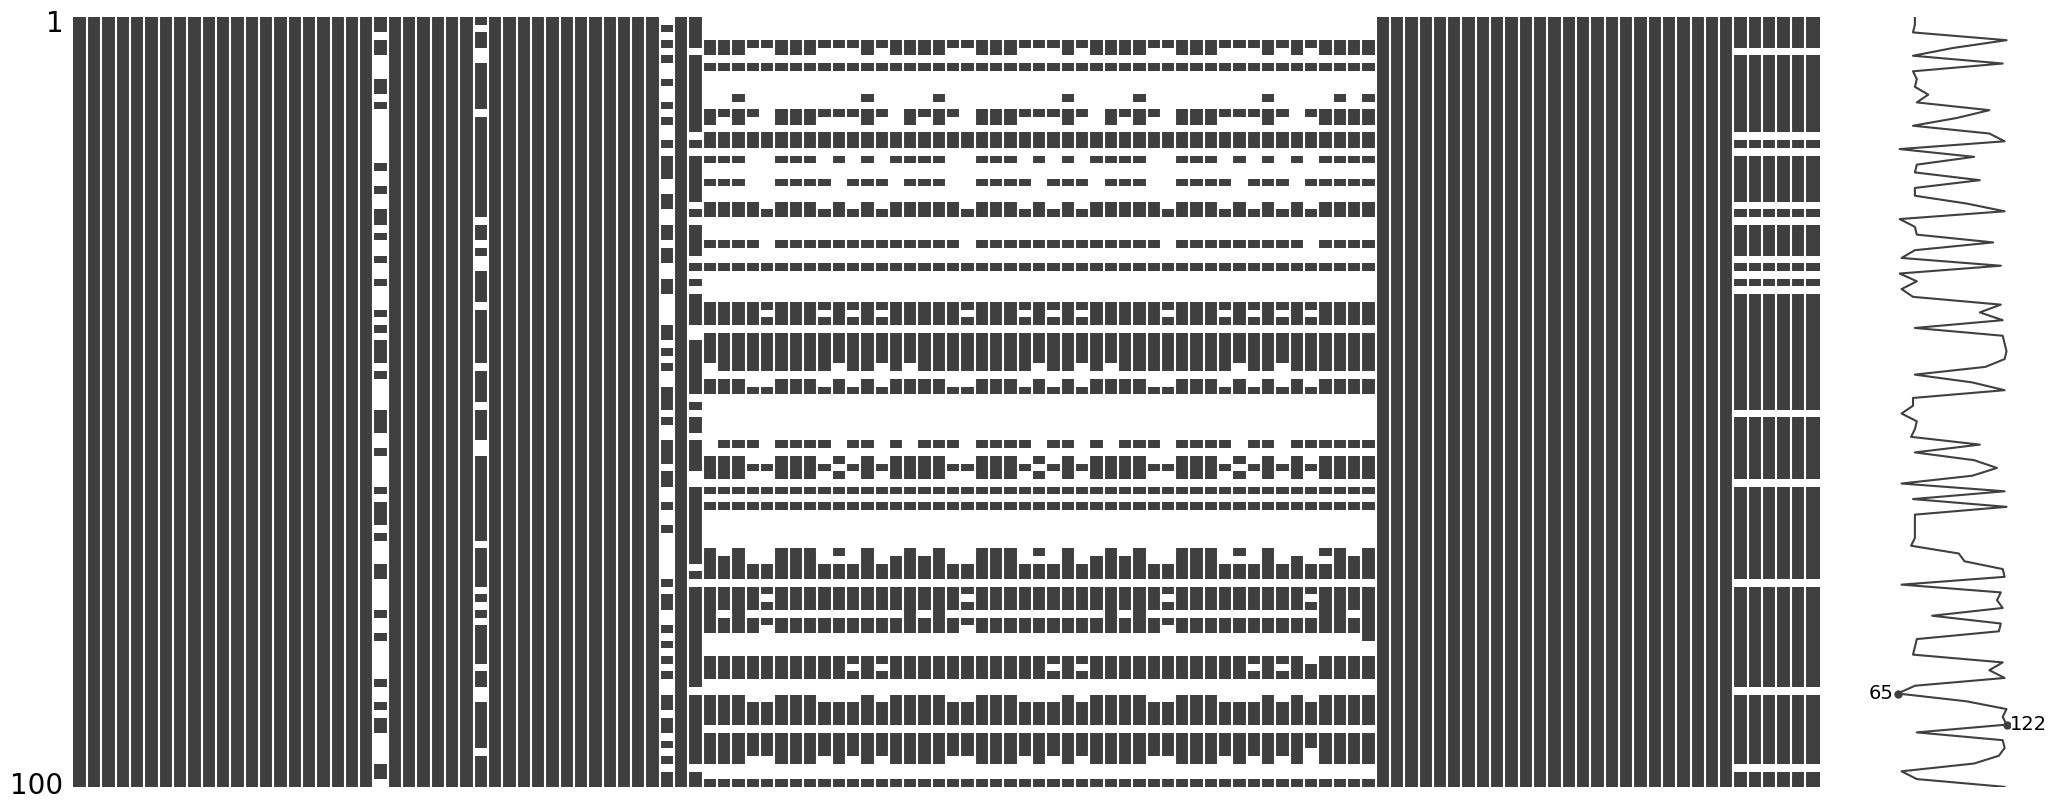

In [312]:
%matplotlib inline
msno.matrix(dfs['application_train'].sample(100))

<Axes: >

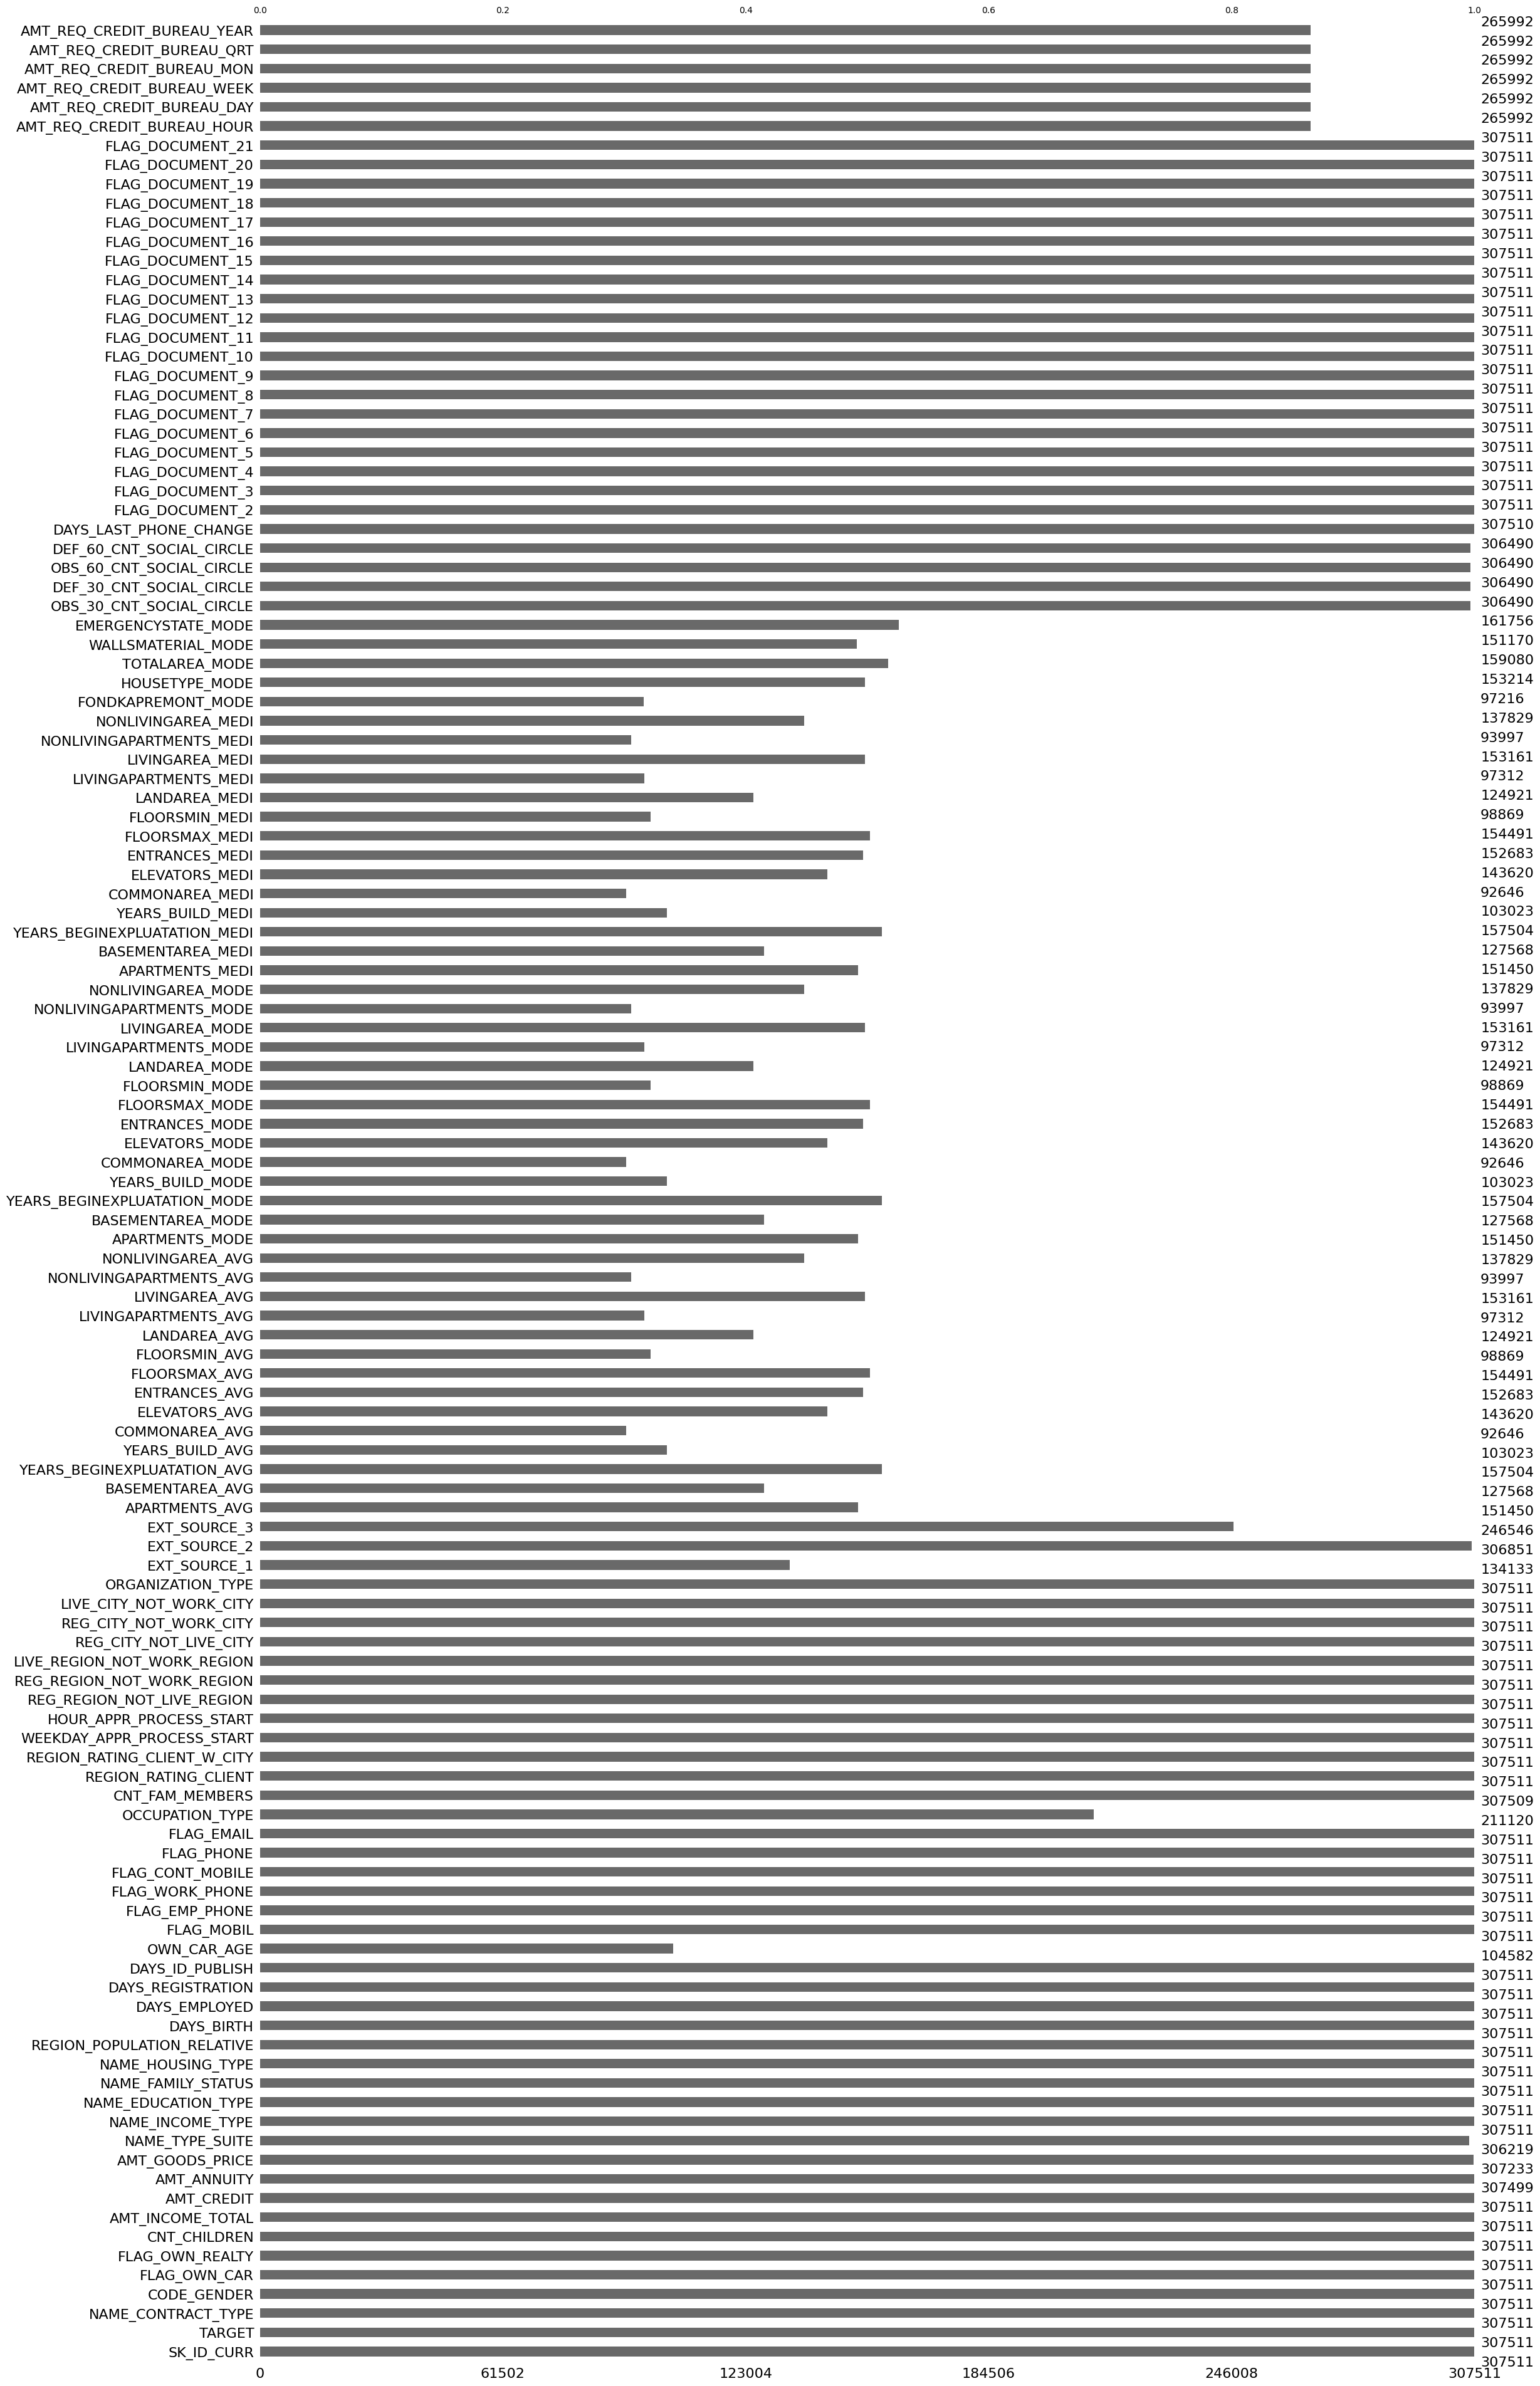

In [313]:
msno.bar(dfs['application_train'])

In [314]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['application_train'].nunique().sort_values(ascending=False)
    )

SK_ID_CURR                      307511
EXT_SOURCE_2                    119831
EXT_SOURCE_1                    114584
DAYS_BIRTH                       17460
DAYS_REGISTRATION                15688
AMT_ANNUITY                      13672
DAYS_EMPLOYED                    12574
DAYS_ID_PUBLISH                   6168
AMT_CREDIT                        5603
LIVINGAREA_MODE                   5301
LIVINGAREA_MEDI                   5281
LIVINGAREA_AVG                    5199
TOTALAREA_MODE                    5116
BASEMENTAREA_MODE                 3841
BASEMENTAREA_AVG                  3780
DAYS_LAST_PHONE_CHANGE            3773
BASEMENTAREA_MEDI                 3772
LANDAREA_MODE                     3563
LANDAREA_MEDI                     3560
LANDAREA_AVG                      3527
NONLIVINGAREA_MODE                3327
NONLIVINGAREA_MEDI                3323
NONLIVINGAREA_AVG                 3290
COMMONAREA_MEDI                   3202
COMMONAREA_AVG                    3181
COMMONAREA_MODE          

In [315]:
for col in dfs["application_train"].columns:
    n = dfs["application_train"][col].nunique()
    if (n <= 30 and n > 2): # Only columns with fewer than 30 unique values, but more than 2, are displayed (this excludes flags and other binary columns)
        print(f"{col} ({n} values) :", dfs["application_train"][col].unique(), "\n")

CODE_GENDER (3 values) : ['M' 'F' 'XNA'] 

CNT_CHILDREN (15 values) : [ 0  1  2  3  4  7  5  6  8  9 11 12 10 19 14] 

NAME_TYPE_SUITE (7 values) : ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' nan
 'Other_B' 'Group of people'] 

NAME_INCOME_TYPE (8 values) : ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave'] 

NAME_EDUCATION_TYPE (5 values) : ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree'] 

NAME_FAMILY_STATUS (6 values) : ['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated'
 'Unknown'] 

NAME_HOUSING_TYPE (6 values) : ['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartment' 'Office apartment' 'Co-op apartment'] 

OCCUPATION_TYPE (18 values) : ['Laborers' 'Core staff' 'Accountants' 'Managers' nan 'Drivers'
 'Sales staff' 'Cleaning staff' 'Cooking staff' 'Private service staff'
 'Medicine staff' 'Secu

In [316]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['application_train'].value_counts()
    )

SK_ID_CURR  TARGET  NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  NAME_TYPE_SUITE  NAME_INCOME_TYPE      NAME_EDUCATION_TYPE            NAME_FAMILY_STATUS    NAME_HOUSING_TYPE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  OWN_CAR_AGE  FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  FLAG_CONT_MOBILE  FLAG_PHONE  FLAG_EMAIL  OCCUPATION_TYPE        CNT_FAM_MEMBERS  REGION_RATING_CLIENT  REGION_RATING_CLIENT_W_CITY  WEEKDAY_APPR_PROCESS_START  HOUR_APPR_PROCESS_START  REG_REGION_NOT_LIVE_REGION  REG_REGION_NOT_WORK_REGION  LIVE_REGION_NOT_WORK_REGION  REG_CITY_NOT_LIVE_CITY  REG_CITY_NOT_WORK_CITY  LIVE_CITY_NOT_WORK_CITY  ORGANIZATION_TYPE       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  APARTMENTS_AVG  BASEMENTAREA_AVG  YEARS_BEGINEXPLUATATION_AVG  YEARS_BUILD_AVG  COMMONAREA_AVG  ELEVATORS_AVG  ENTRANCES_AVG  FLOORSMAX_AVG  FLOORSMIN_AVG  LANDAREA_AVG  

In [317]:
len(dfs["application_train"].select_dtypes(include="number").columns)

106

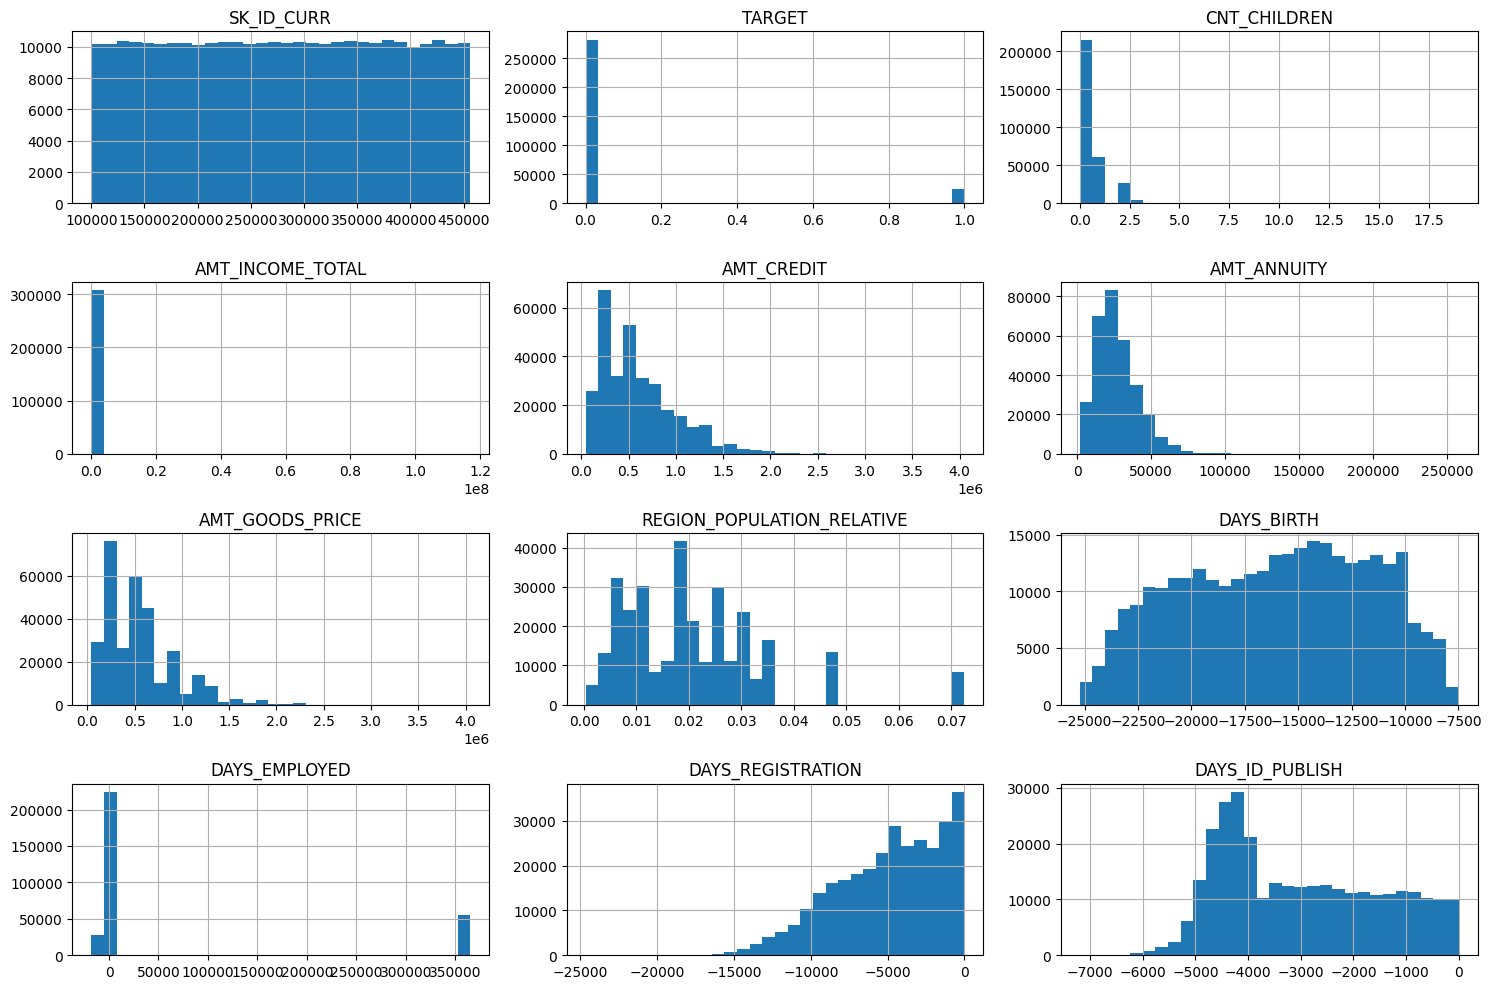

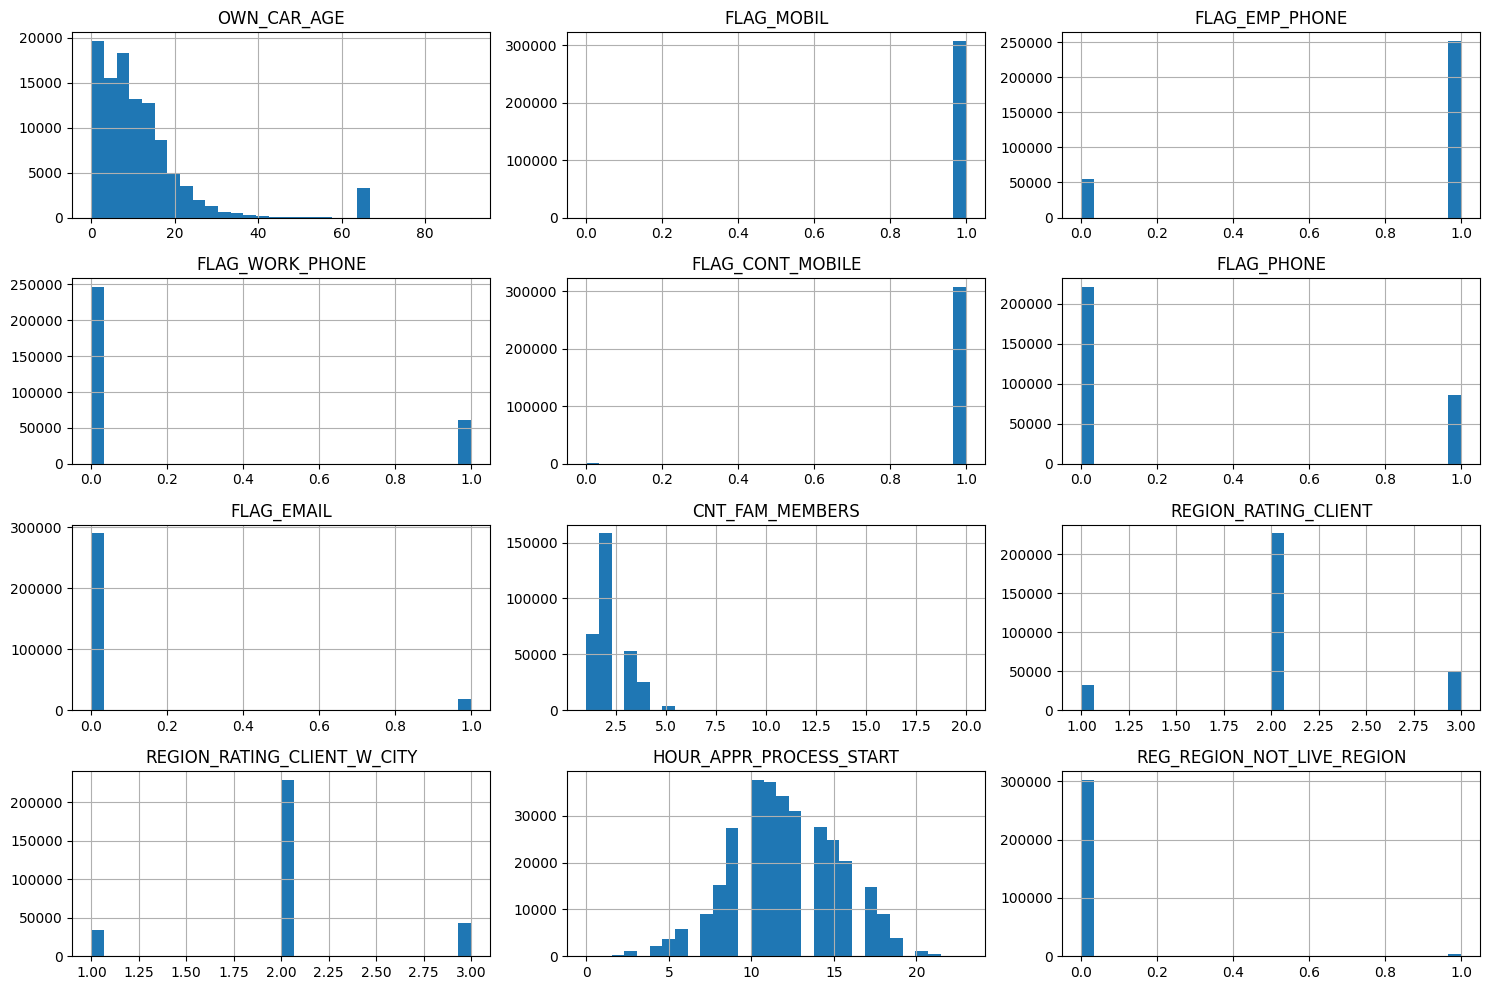

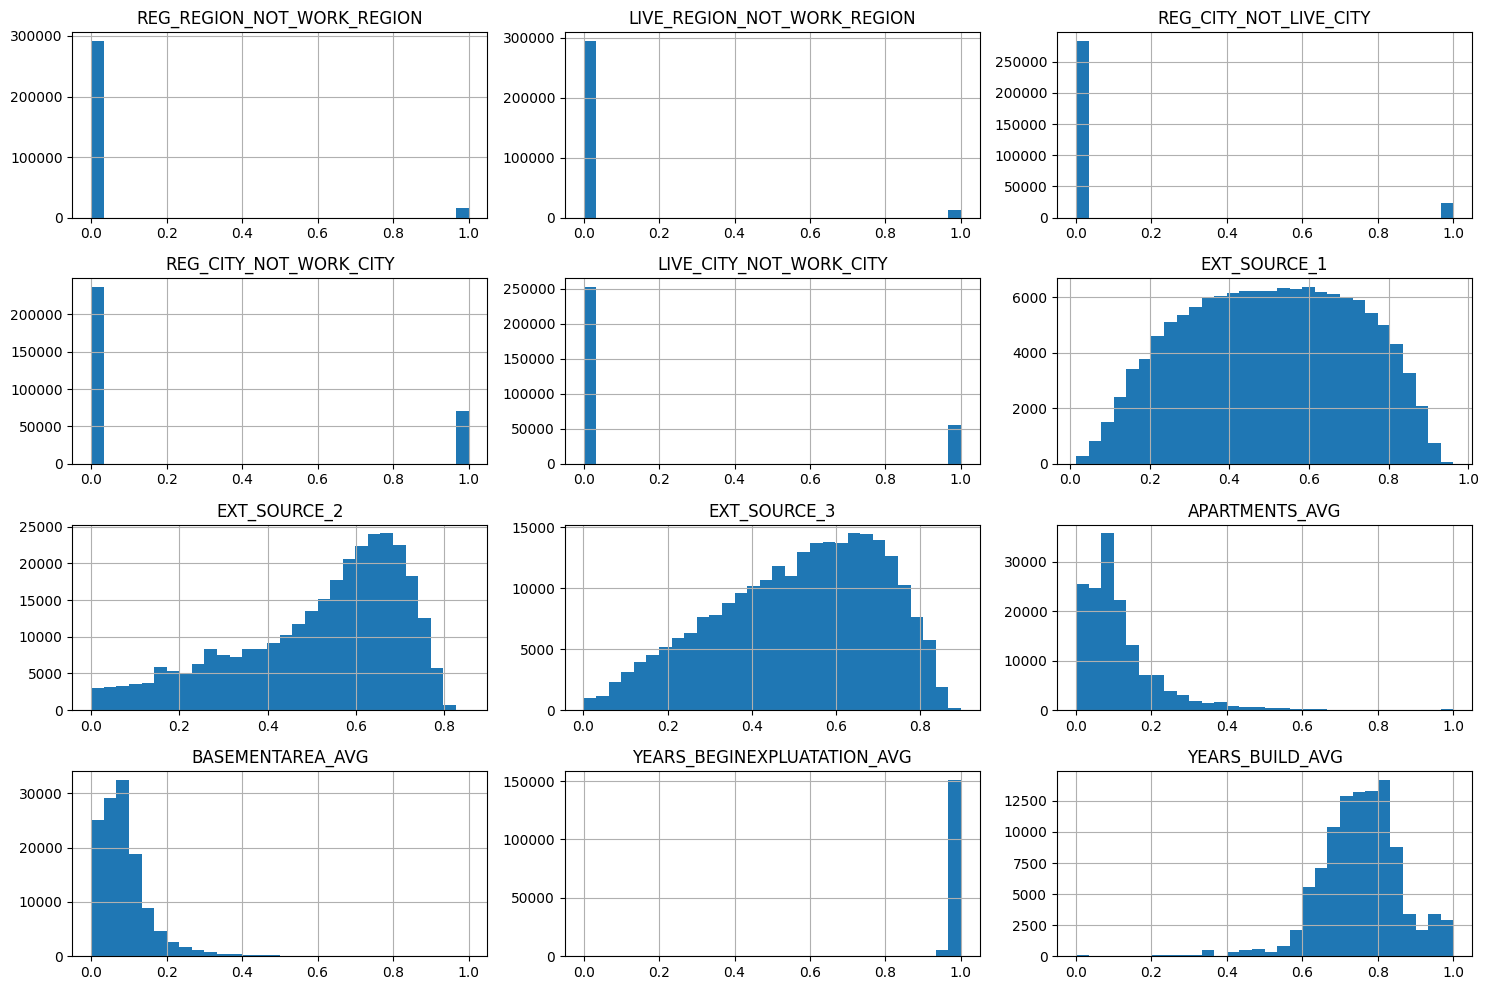

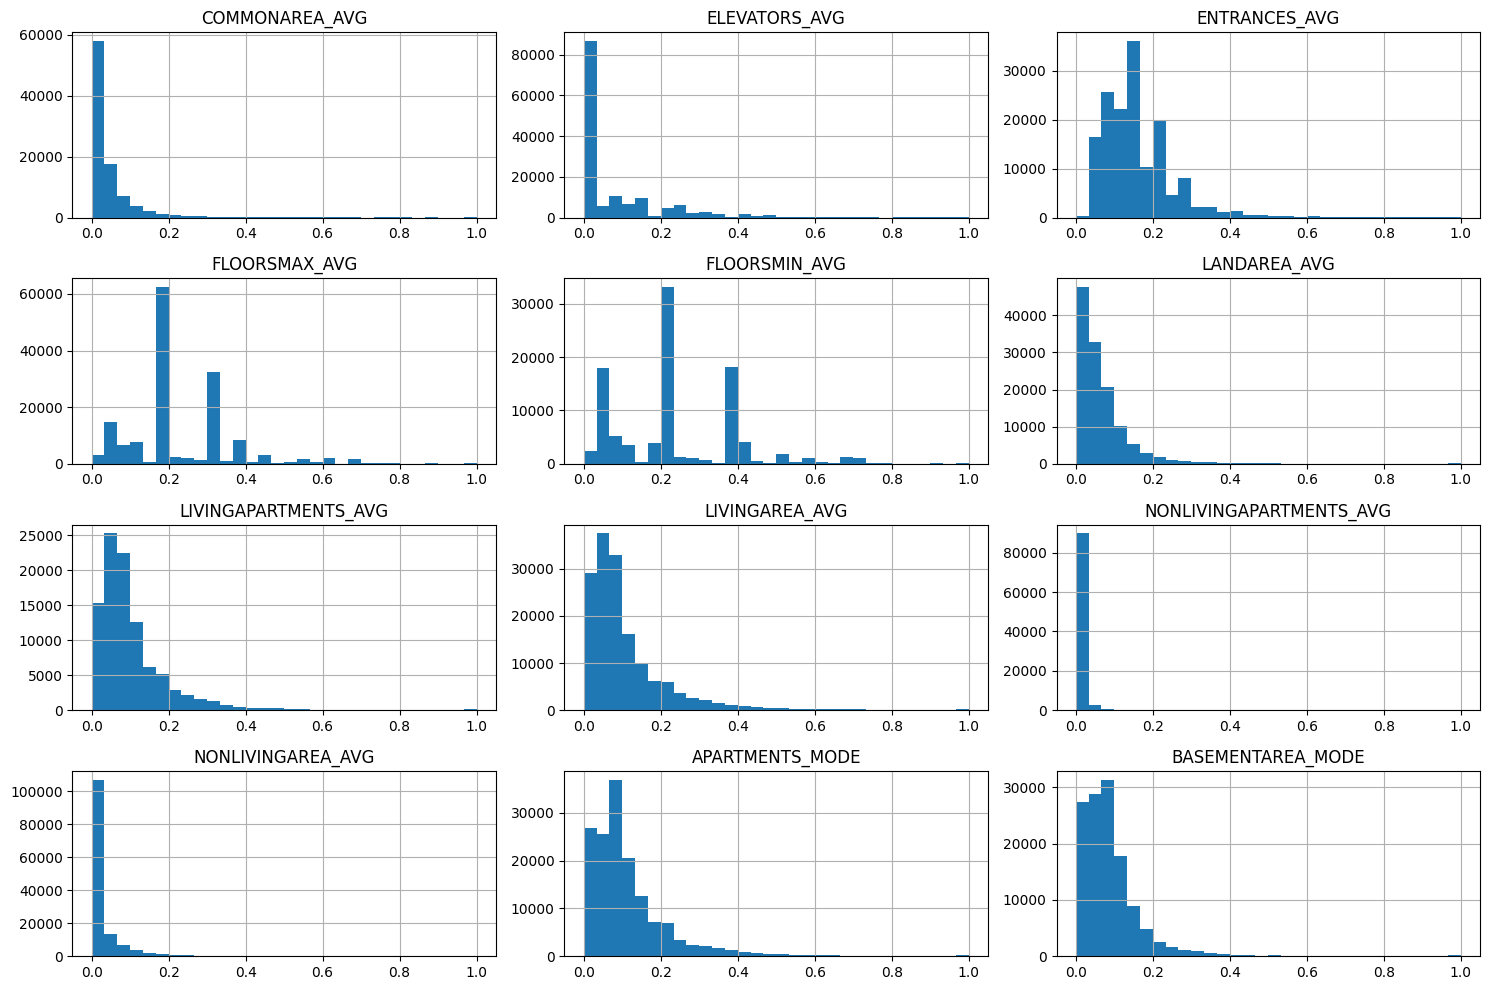

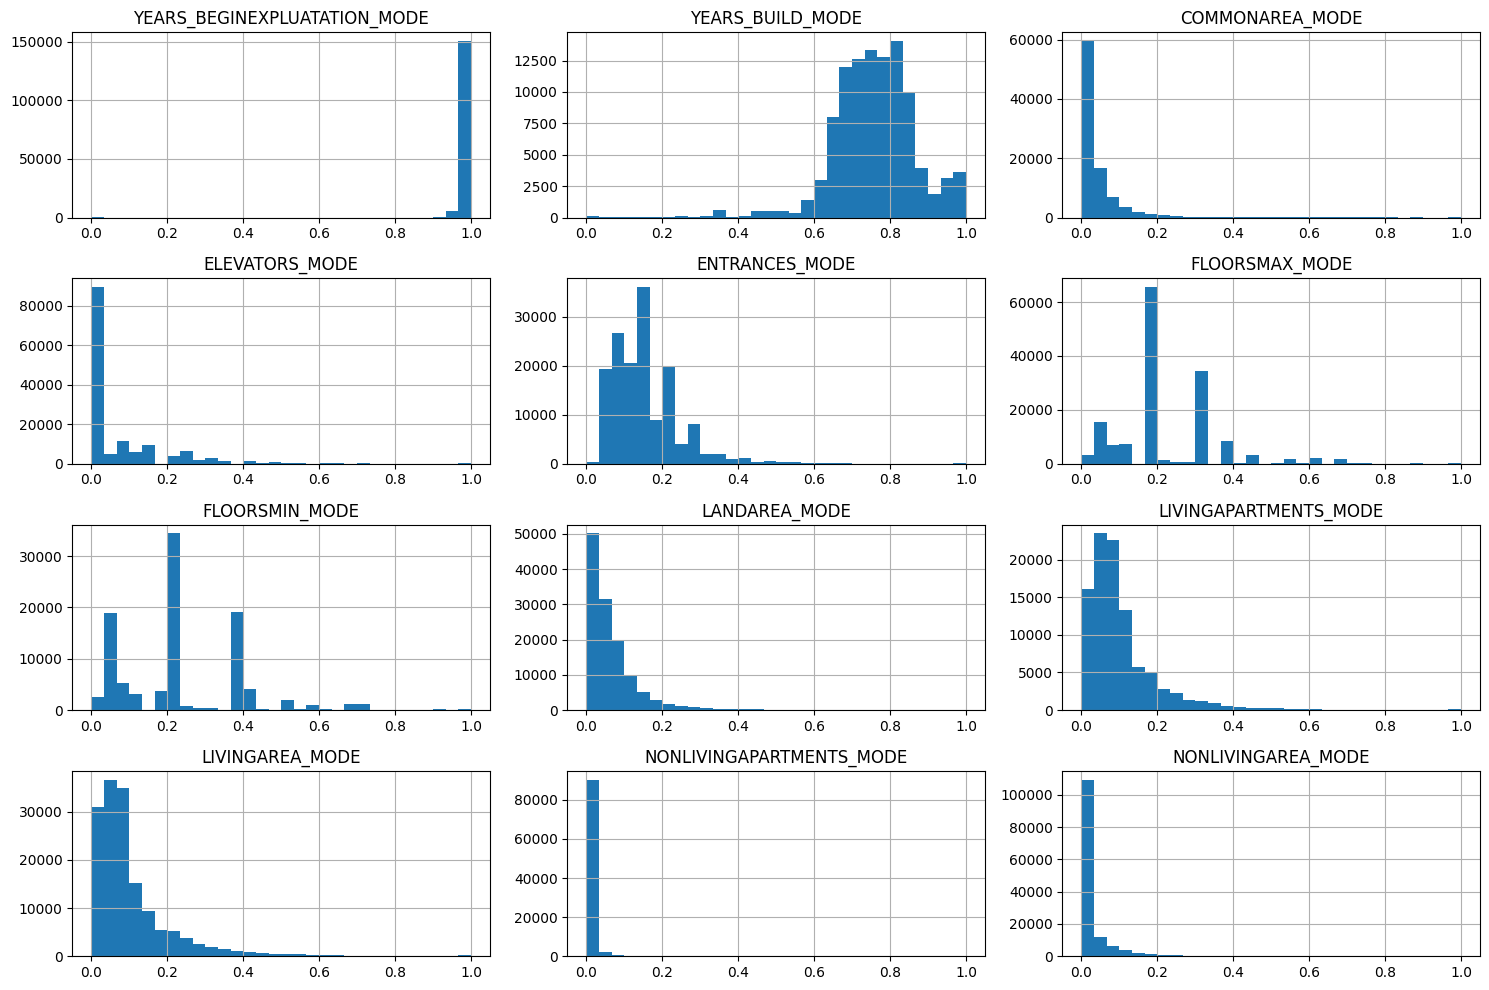

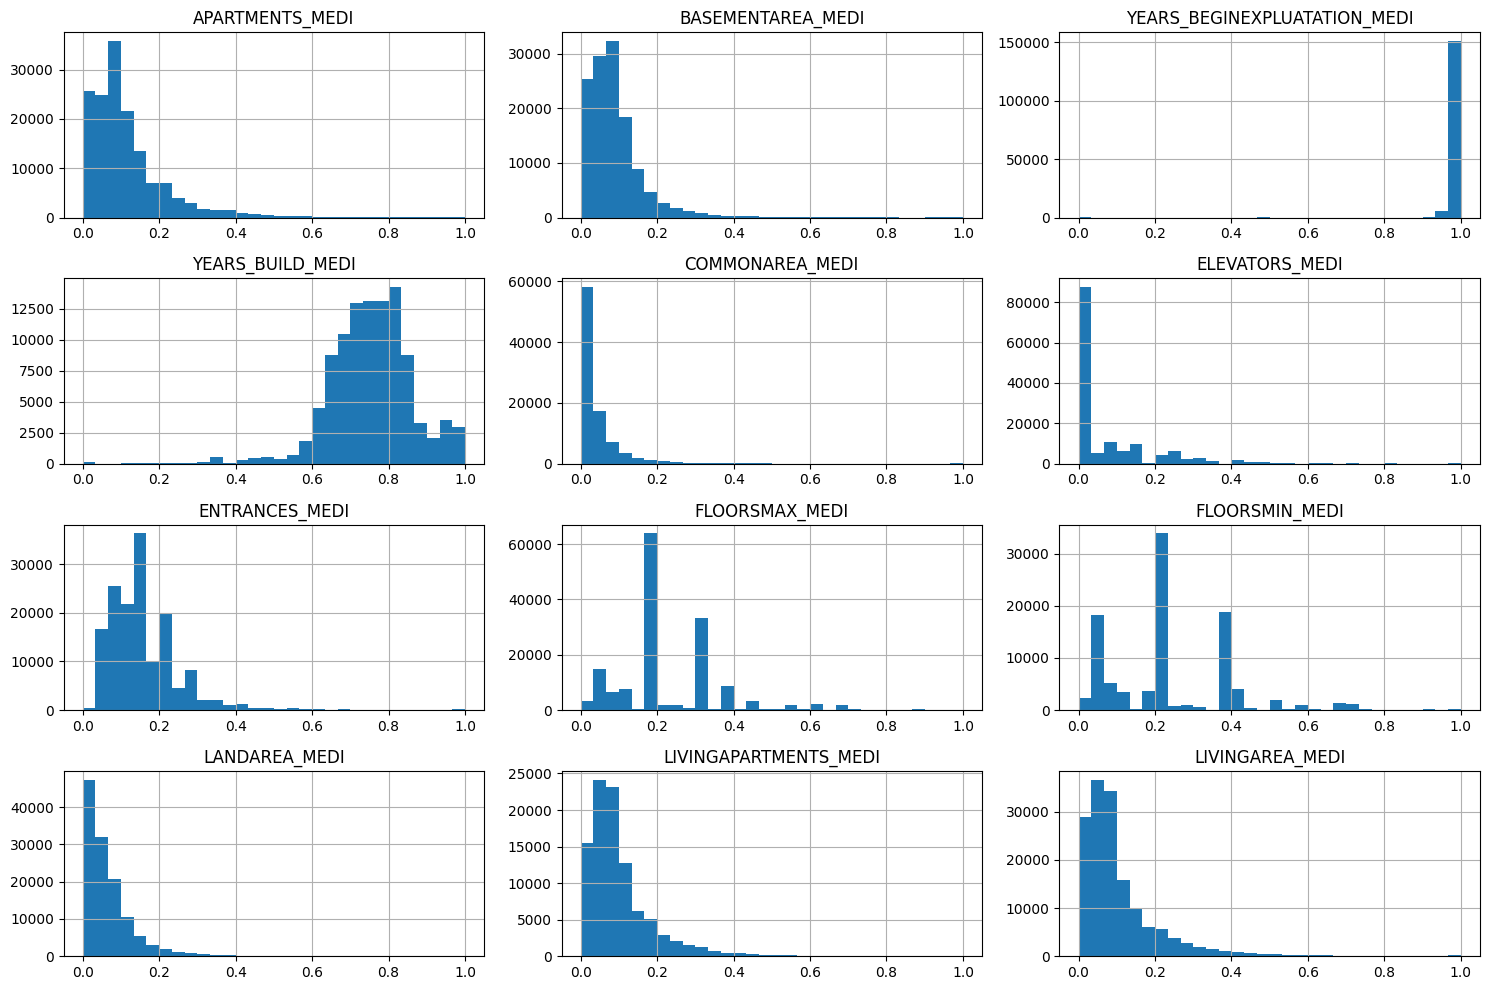

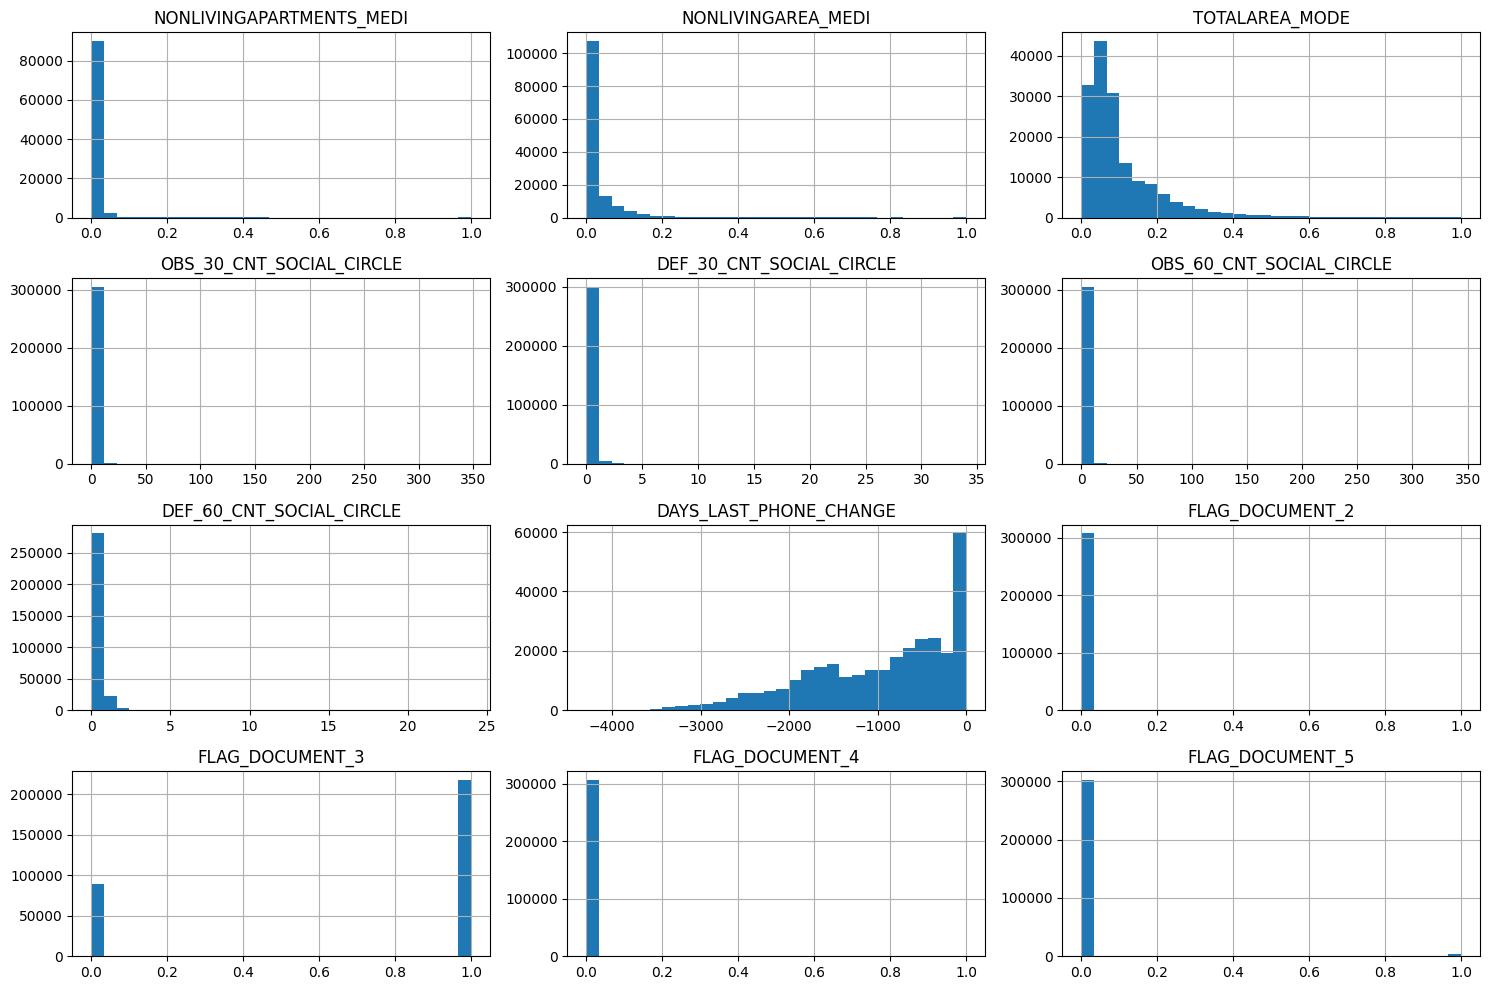

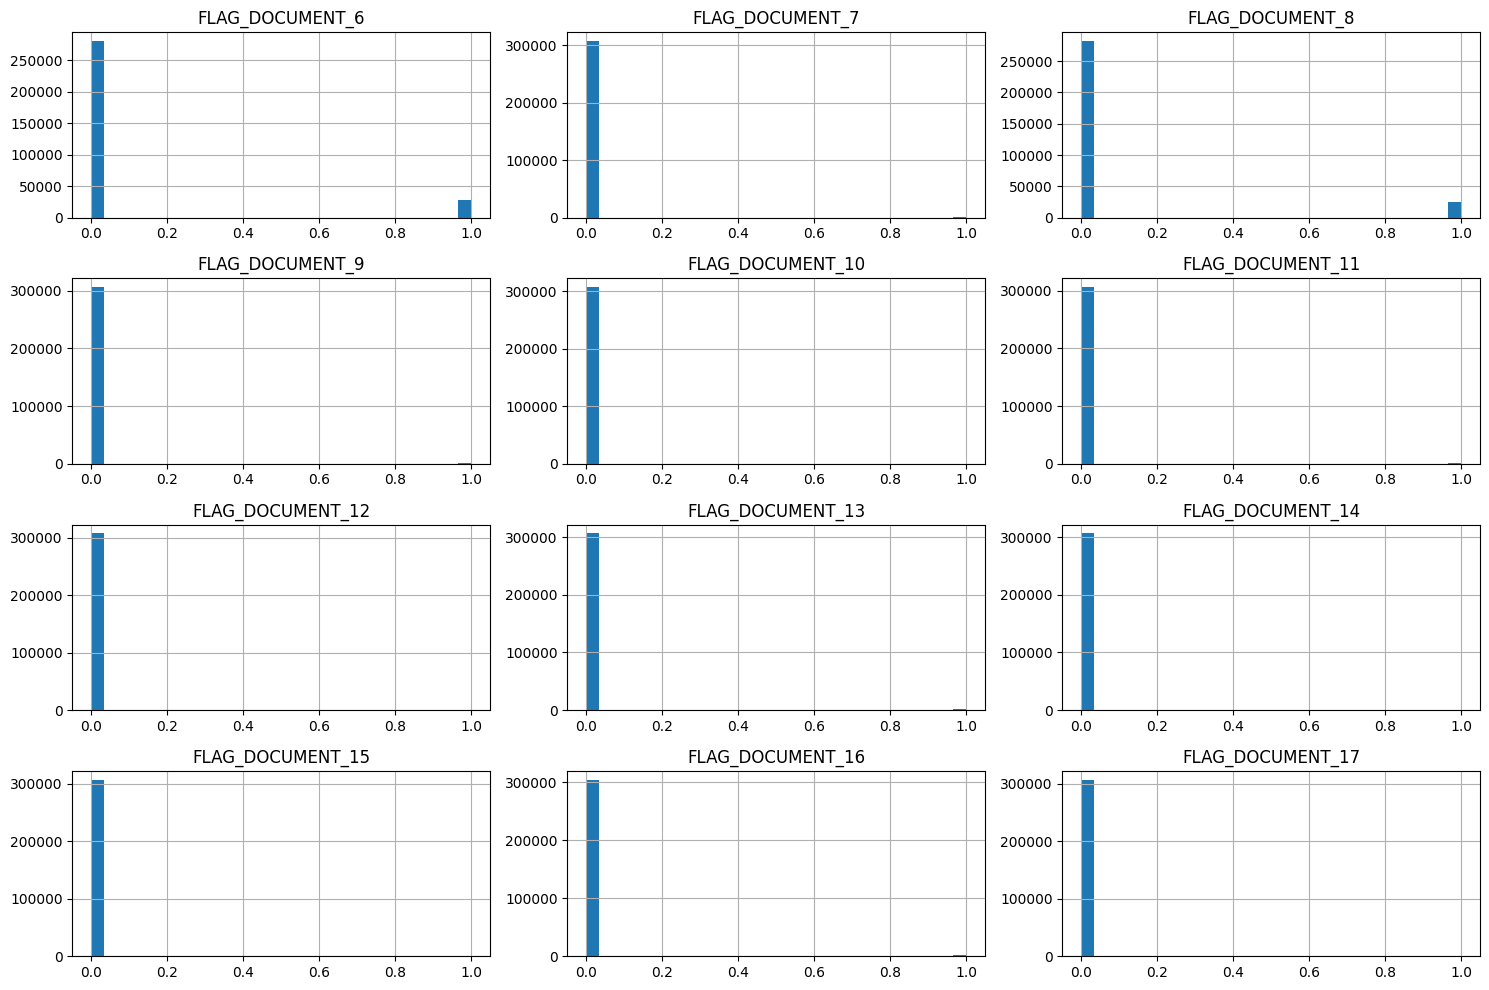

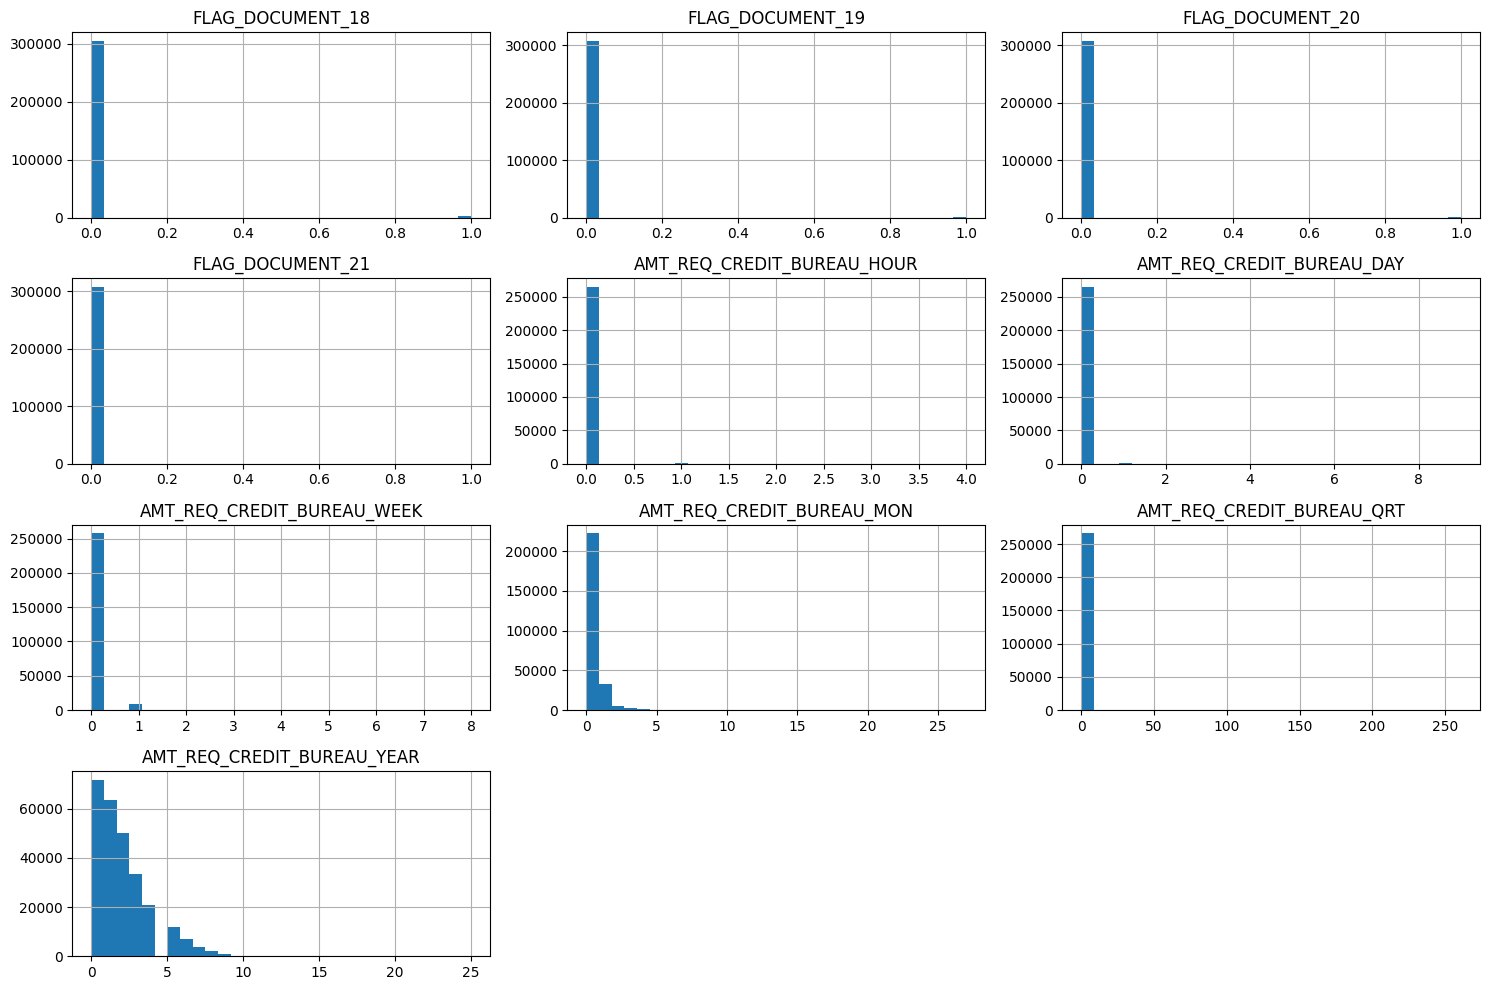

In [318]:
numeric_cols = dfs["application_train"].select_dtypes(include="number").columns
chunk_size = 12

for i in range(0, len(numeric_cols), chunk_size):
    cols_chunk = numeric_cols[i:i + chunk_size]
    dfs["application_train"][cols_chunk].hist(figsize=(15, 10), bins=30)
    plt.tight_layout()
    plt.show()

In [319]:
dfs["application_train"][[
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH"
]]

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH
0,-9461,-637,"-3,648.00",-2120
1,-16765,-1188,"-1,186.00",-291
2,-19046,-225,"-4,260.00",-2531
3,-19005,-3039,"-9,833.00",-2437
4,-19932,-3038,"-4,311.00",-3458
...,...,...,...,...
307506,-9327,-236,"-8,456.00",-1982
307507,-20775,365243,"-4,388.00",-4090
307508,-14966,-7921,"-6,737.00",-5150
307509,-11961,-4786,"-2,562.00",-931


In [320]:
dfs["application_train"][[
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH"
]].describe()

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH
count,"307,511.00","307,511.00","307,511.00","307,511.00"
mean,"-16,037.00","63,815.05","-4,986.12","-2,994.20"
std,"4,363.99","141,275.77","3,522.89","1,509.45"
min,"-25,229.00","-17,912.00","-24,672.00","-7,197.00"
25%,"-19,682.00","-2,760.00","-7,479.50","-4,299.00"
50%,"-15,750.00","-1,213.00","-4,504.00","-3,254.00"
75%,"-12,413.00",-289.00,"-2,010.00","-1,720.00"
max,"-7,489.00","365,243.00",0.00,0.00


In [321]:
days_cols = [c for c in [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH"
]]
(dfs['application_train'][days_cols].mask(dfs['application_train'][days_cols] > 0) / -365.25).describe().round(1)

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH
count,"307,511.00","252,137.00","307,511.00","307,511.00"
mean,43.90,6.50,13.70,8.20
std,11.90,6.40,9.60,4.10
min,20.50,-0.00,-0.00,-0.00
25%,34.00,2.10,5.50,4.70
50%,43.10,4.50,12.30,8.90
75%,53.90,8.70,20.50,11.80
max,69.10,49.00,67.50,19.70


In [322]:
for c in ['DAYS_BIRTH', 'DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']:
    print(c, (dfs["application_train"][c] == 0).sum())

DAYS_BIRTH 0
DAYS_EMPLOYED 2
DAYS_REGISTRATION 80
DAYS_ID_PUBLISH 16
DAYS_LAST_PHONE_CHANGE 37672


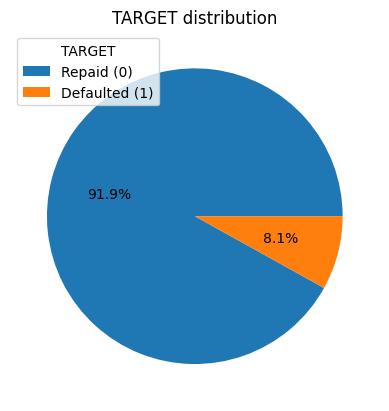

In [323]:
counts = dfs['application_train']['TARGET'].value_counts()

plt.pie(counts, autopct="%1.1f%%")
plt.legend(labels=["Repaid (0)", "Defaulted (1)"], title="TARGET", loc="best")
plt.title("TARGET distribution")
plt.show()

In [324]:
with pd.option_context('display.max_columns', None):
    display(dfs['application_test'])

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,"135,000.00","568,800.00","20,560.50","450,000.00",Unaccompanied,Working,Higher education,Married,House / apartment,0.02,-19241,-2329,"-5,170.00",-812,NaN,1,1,0,1,0,1,NaN,2.00,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.75,0.79,0.16,0.07,0.06,0.97,NaN,NaN,NaN,0.14,0.12,NaN,NaN,NaN,0.05,NaN,NaN,0.07,0.06,0.97,NaN,NaN,NaN,0.14,0.12,NaN,NaN,NaN,0.05,NaN,NaN,0.07,0.06,0.97,NaN,NaN,NaN,0.14,0.12,NaN,NaN,NaN,0.05,NaN,NaN,NaN,block of flats,0.04,"Stone, brick",No,0.00,0.00,0.00,0.00,"-1,740.00",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
1,100005,Cash loans,M,N,Y,0,"99,000.00","222,768.00","17,370.00","180,000.00",Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.04,-18064,-4469,"-9,118.00",-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.00,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.56,0.29,0.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,3.00
2,100013,Cash loans,M,Y,Y,0,"202,500.00","663,264.00","69,777.00","630,000.00",NaN,Working,Higher education,Married,House / apartment,0.02,-20038,-4458,"-2,175.00",-3503,5.00,1,1,0,1,0,0,Drivers,2.00,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.70,0.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-856.00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,1.00,4.00
3,100028,Cash loans,F,N,Y,2,"315,000.00","1,575,000.00","49,018.50","1,575,000.00",Unaccompanied,Workin

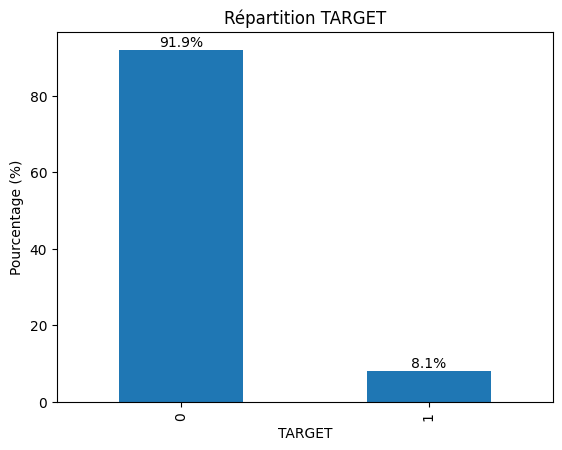

In [325]:
counts = dfs['application_train']['TARGET'].value_counts(normalize=True) * 100
counts.plot(kind='bar')
plt.ylabel("Pourcentage (%)")
plt.title("Répartition TARGET")
for i, v in enumerate(counts):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()

The defaulted class, which is what we want to detect, is much less frequent than the repaid class. This is the classical **class imbalance problem**, which we will address using *stratify* in the train/test split, along with a few other dedicated methods.

##### 4. application_test table

In [326]:
dfs['application_test']

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,"135,000.00","568,800.00","20,560.50","450,000.00",...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
1,100005,Cash loans,M,N,Y,0,"99,000.00","222,768.00","17,370.00","180,000.00",...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,3.00
2,100013,Cash loans,M,Y,Y,0,"202,500.00","663,264.00","69,777.00","630,000.00",...,0,0,0,0,0.00,0.00,0.00,0.00,1.00,4.00
3,100028,Cash loans,F,N,Y,2,"315,000.00","1,575,000.00","49,018.50","1,575,000.00",...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,3.00
4,100038,Cash loans,M,Y,N,1,"180,000.00","625,500.00","32,067.00","625,500.00",...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,"121,500.00","412,560.00","17,473.50","270,000.00",...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
48740,456222,Cash loans,F,N,N,2,"157,500.00","622,413.00","31,909.50","495,000.00",...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
48741,456223,Cash loans,F,Y,Y,1,"202,500.00","315,000.00","33,205.50","315,000.00",...,0,0,0,0,0.00,0.00,0.00,0.00,3.00,1.00
48742,456224,Cash loans,M,N,N,0,"225,000.00","450,000.00","25,128.00","450,000.00",...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,2.00


In [327]:
dfs['application_test'].info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 121 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 int64  
 18   DAYS

In [328]:
cols_train = set(dfs['application_train'].columns)
cols_test = set(dfs['application_test'].columns)
cols_train - cols_test

{'TARGET'}

This is simply to check that the columns are identical between the `application_train` and `application_test` tables (which is confirmed, with the exception of the ‘Target’ column, which is present in `application_train`). 

In [329]:
with pd.option_context('display.max_rows', 130):
    display(
        (dfs['application_test'].isnull().sum() / len(dfs['application_test']) * 100)
        .round(2)
        .sort_values(ascending=False)
    )

COMMONAREA_AVG                 68.72
COMMONAREA_MODE                68.72
COMMONAREA_MEDI                68.72
NONLIVINGAPARTMENTS_AVG        68.41
NONLIVINGAPARTMENTS_MODE       68.41
NONLIVINGAPARTMENTS_MEDI       68.41
FONDKAPREMONT_MODE             67.28
LIVINGAPARTMENTS_AVG           67.25
LIVINGAPARTMENTS_MODE          67.25
LIVINGAPARTMENTS_MEDI          67.25
FLOORSMIN_MEDI                 66.61
FLOORSMIN_AVG                  66.61
FLOORSMIN_MODE                 66.61
OWN_CAR_AGE                    66.29
YEARS_BUILD_AVG                65.28
YEARS_BUILD_MEDI               65.28
YEARS_BUILD_MODE               65.28
LANDAREA_MEDI                  57.96
LANDAREA_AVG                   57.96
LANDAREA_MODE                  57.96
BASEMENTAREA_MEDI              56.71
BASEMENTAREA_AVG               56.71
BASEMENTAREA_MODE              56.71
NONLIVINGAREA_AVG              53.51
NONLIVINGAREA_MODE             53.51
NONLIVINGAREA_MEDI             53.51
ELEVATORS_MODE                 51.68
E

<Axes: >

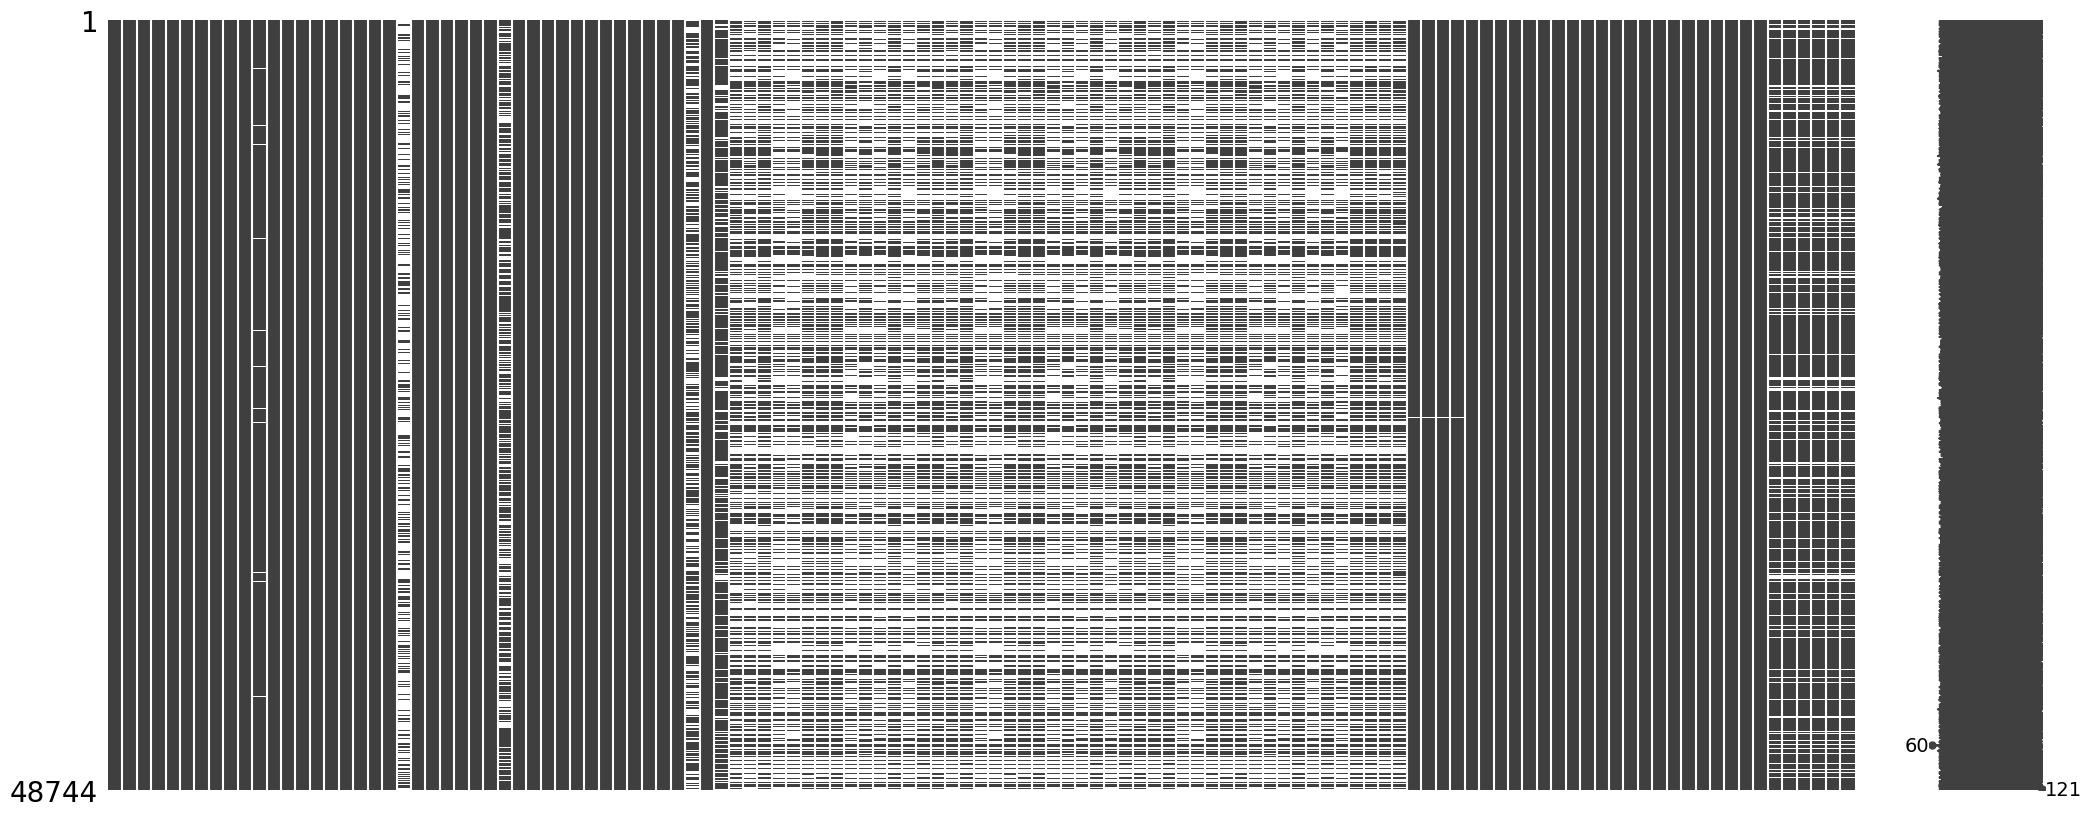

In [330]:
%matplotlib inline
msno.matrix(dfs['application_test'])

<Axes: >

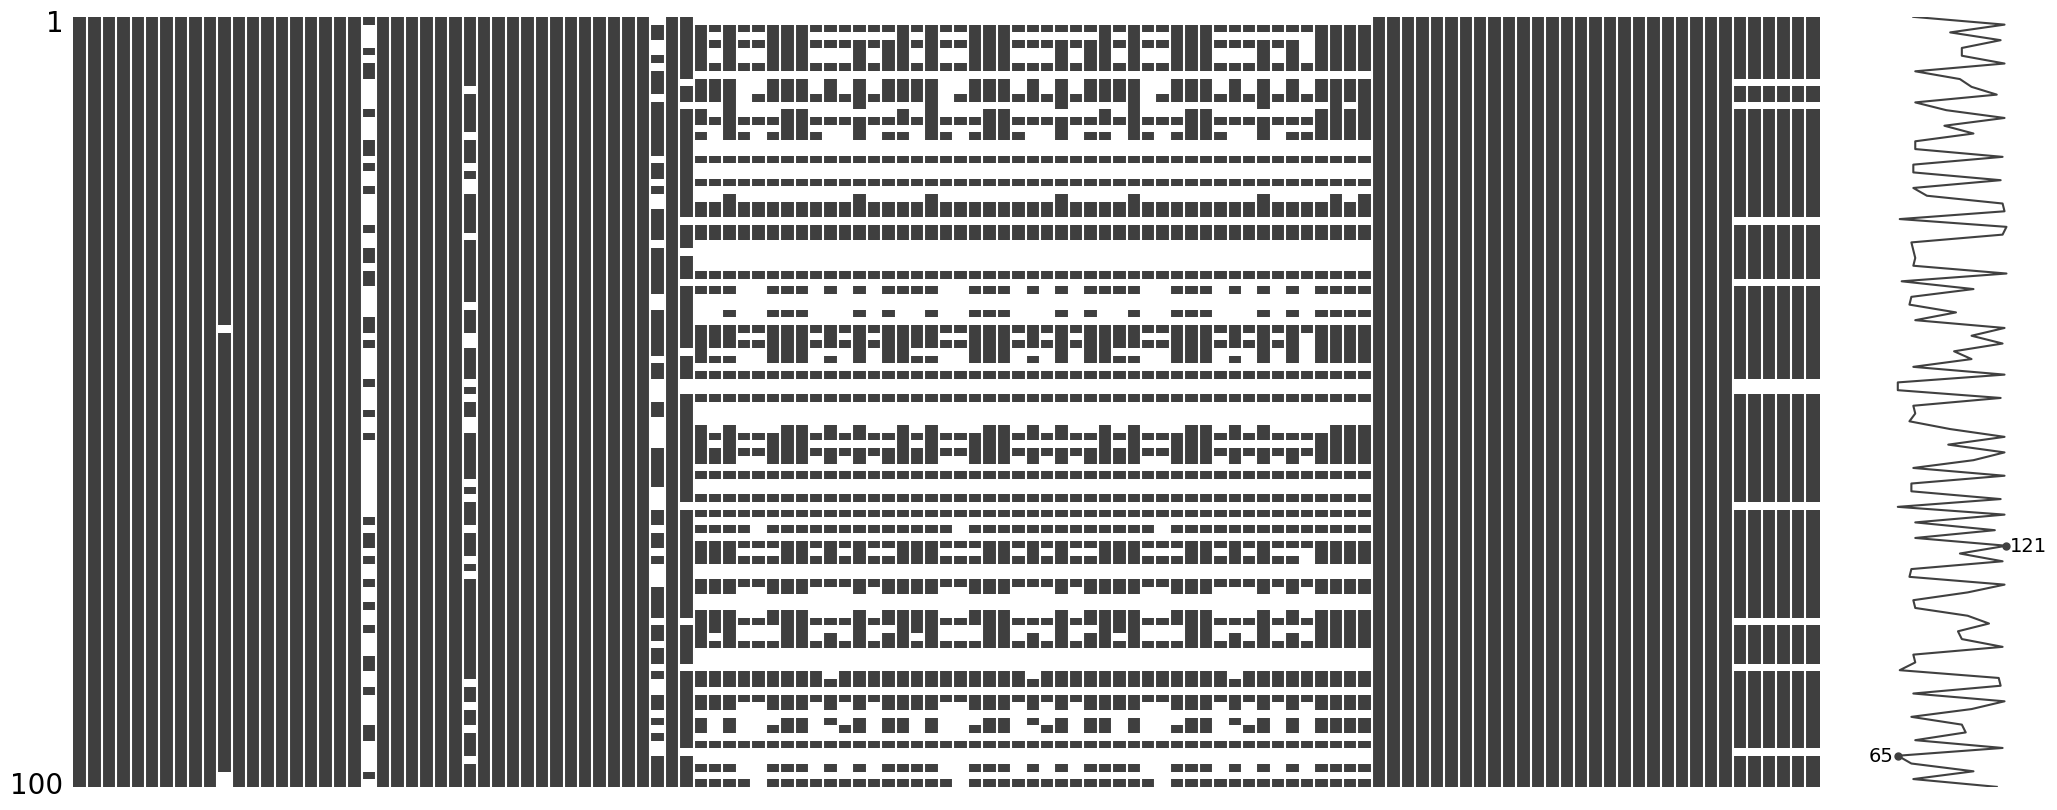

In [331]:
%matplotlib inline
msno.matrix(dfs['application_test'].sample(100))

<Axes: >

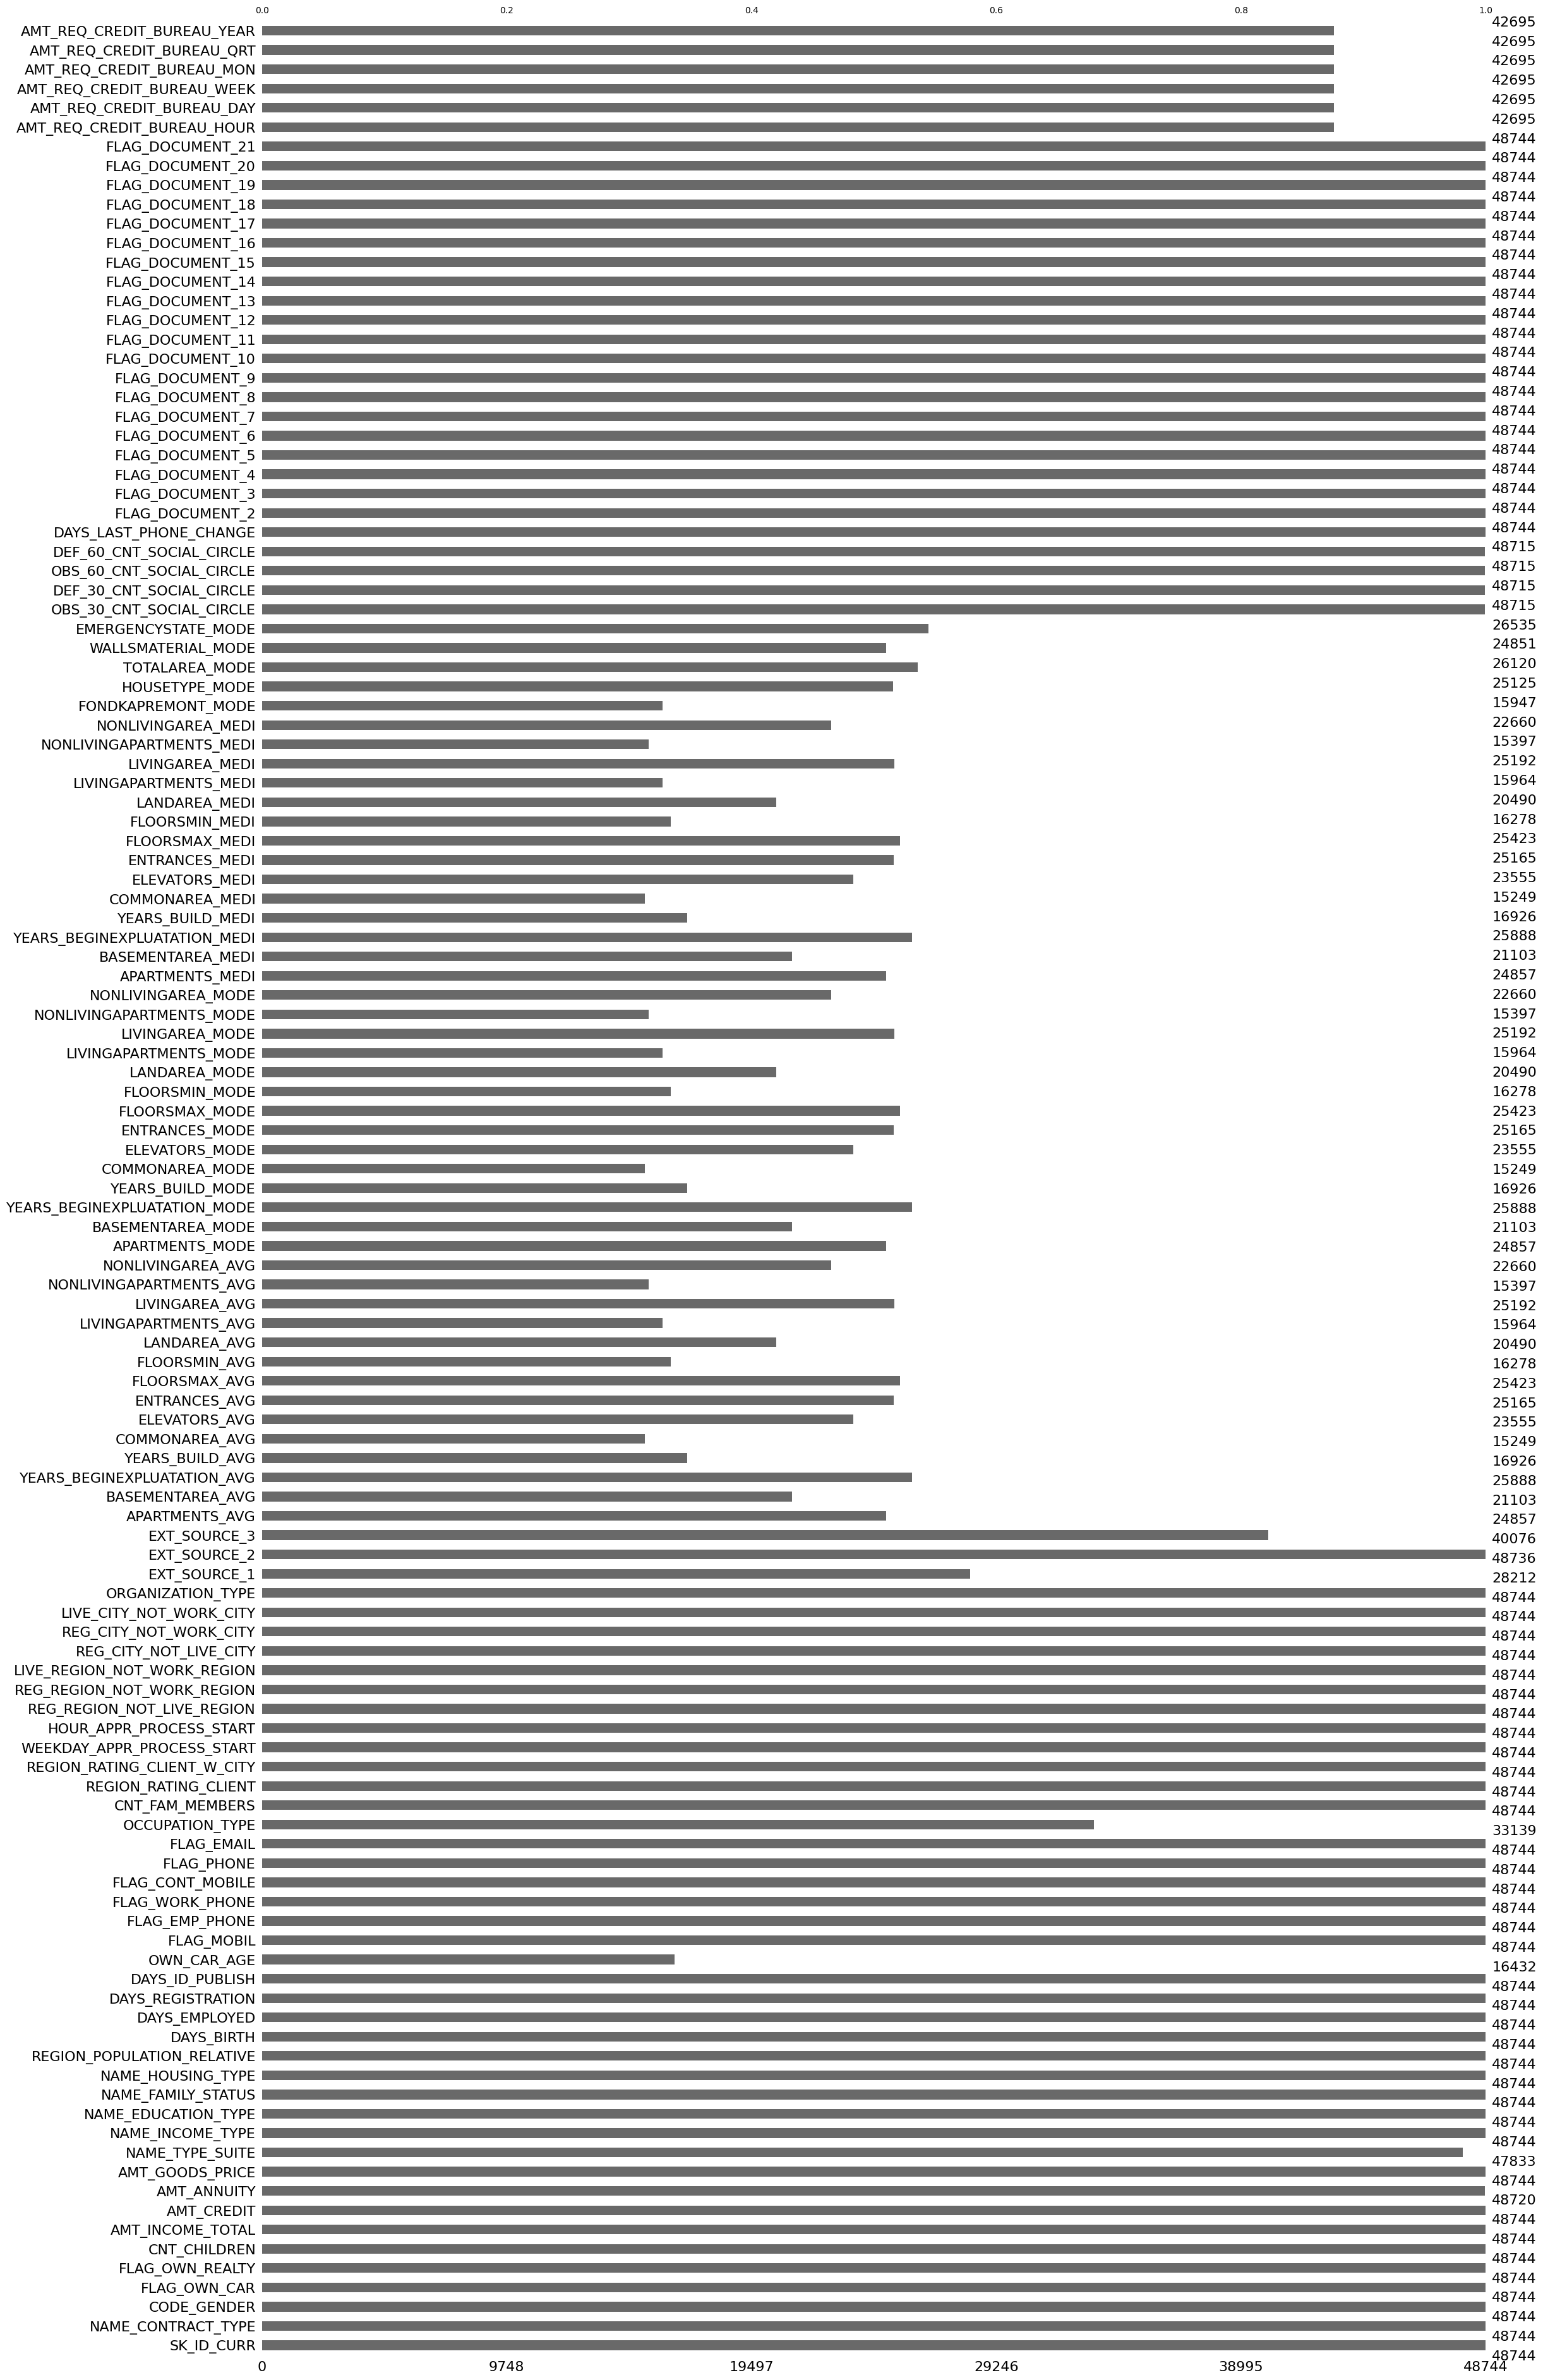

In [332]:
msno.bar(dfs['application_test'])

In [333]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['application_test'].nunique().sort_values(ascending=False)
    )

SK_ID_CURR                      48744
EXT_SOURCE_2                    38885
EXT_SOURCE_1                    27207
DAYS_BIRTH                      15477
DAYS_REGISTRATION               12618
DAYS_EMPLOYED                    7863
AMT_ANNUITY                      7491
DAYS_ID_PUBLISH                  5880
LIVINGAREA_MEDI                  3885
LIVINGAREA_AVG                   3848
LIVINGAREA_MODE                  3842
TOTALAREA_MODE                   3820
DAYS_LAST_PHONE_CHANGE           3579
AMT_CREDIT                       2937
BASEMENTAREA_MODE                2835
BASEMENTAREA_AVG                 2816
BASEMENTAREA_MEDI                2805
LANDAREA_MEDI                    2562
LANDAREA_MODE                    2560
LANDAREA_AVG                     2540
COMMONAREA_AVG                   2042
COMMONAREA_MEDI                  2034
NONLIVINGAREA_MEDI               2030
NONLIVINGAREA_AVG                2026
NONLIVINGAREA_MODE               2025
COMMONAREA_MODE                  2001
APARTMENTS_A

In [334]:
for col in dfs["application_test"].columns:
    n = dfs["application_test"][col].nunique()
    if (n <= 30 and n > 2): # Only columns with fewer than 30 unique values, but more than 2, are displayed (this excludes flags and other binary columns)
        print(f"{col} ({n} values) :", dfs["application_test"][col].unique(), "\n")

CNT_CHILDREN (11 values) : [ 0  2  1  3  8  4  6  5  7 20 11] 

NAME_TYPE_SUITE (7 values) : ['Unaccompanied' nan 'Family' 'Spouse, partner' 'Group of people'
 'Other_B' 'Children' 'Other_A'] 

NAME_INCOME_TYPE (7 values) : ['Working' 'State servant' 'Pensioner' 'Commercial associate'
 'Businessman' 'Student' 'Unemployed'] 

NAME_EDUCATION_TYPE (5 values) : ['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree'] 

NAME_FAMILY_STATUS (5 values) : ['Married' 'Single / not married' 'Civil marriage' 'Widow' 'Separated'] 

NAME_HOUSING_TYPE (6 values) : ['House / apartment' 'With parents' 'Rented apartment'
 'Municipal apartment' 'Office apartment' 'Co-op apartment'] 

OCCUPATION_TYPE (18 values) : [nan 'Low-skill Laborers' 'Drivers' 'Sales staff' 'High skill tech staff'
 'Core staff' 'Laborers' 'Managers' 'Accountants' 'Medicine staff'
 'Security staff' 'Private service staff' 'Secretaries' 'Cleaning staff'
 'Cooking staff' 'HR staff' '

In [335]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['application_test'].value_counts()
    )

SK_ID_CURR  NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  NAME_TYPE_SUITE  NAME_INCOME_TYPE      NAME_EDUCATION_TYPE            NAME_FAMILY_STATUS    NAME_HOUSING_TYPE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  OWN_CAR_AGE  FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  FLAG_CONT_MOBILE  FLAG_PHONE  FLAG_EMAIL  OCCUPATION_TYPE  CNT_FAM_MEMBERS  REGION_RATING_CLIENT  REGION_RATING_CLIENT_W_CITY  WEEKDAY_APPR_PROCESS_START  HOUR_APPR_PROCESS_START  REG_REGION_NOT_LIVE_REGION  REG_REGION_NOT_WORK_REGION  LIVE_REGION_NOT_WORK_REGION  REG_CITY_NOT_LIVE_CITY  REG_CITY_NOT_WORK_CITY  LIVE_CITY_NOT_WORK_CITY  ORGANIZATION_TYPE       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  APARTMENTS_AVG  BASEMENTAREA_AVG  YEARS_BEGINEXPLUATATION_AVG  YEARS_BUILD_AVG  COMMONAREA_AVG  ELEVATORS_AVG  ENTRANCES_AVG  FLOORSMAX_AVG  FLOORSMIN_AVG  LANDAREA_AVG  LIVINGAPARTMEN

In [336]:
len(dfs["application_test"].select_dtypes(include="number").columns)

105

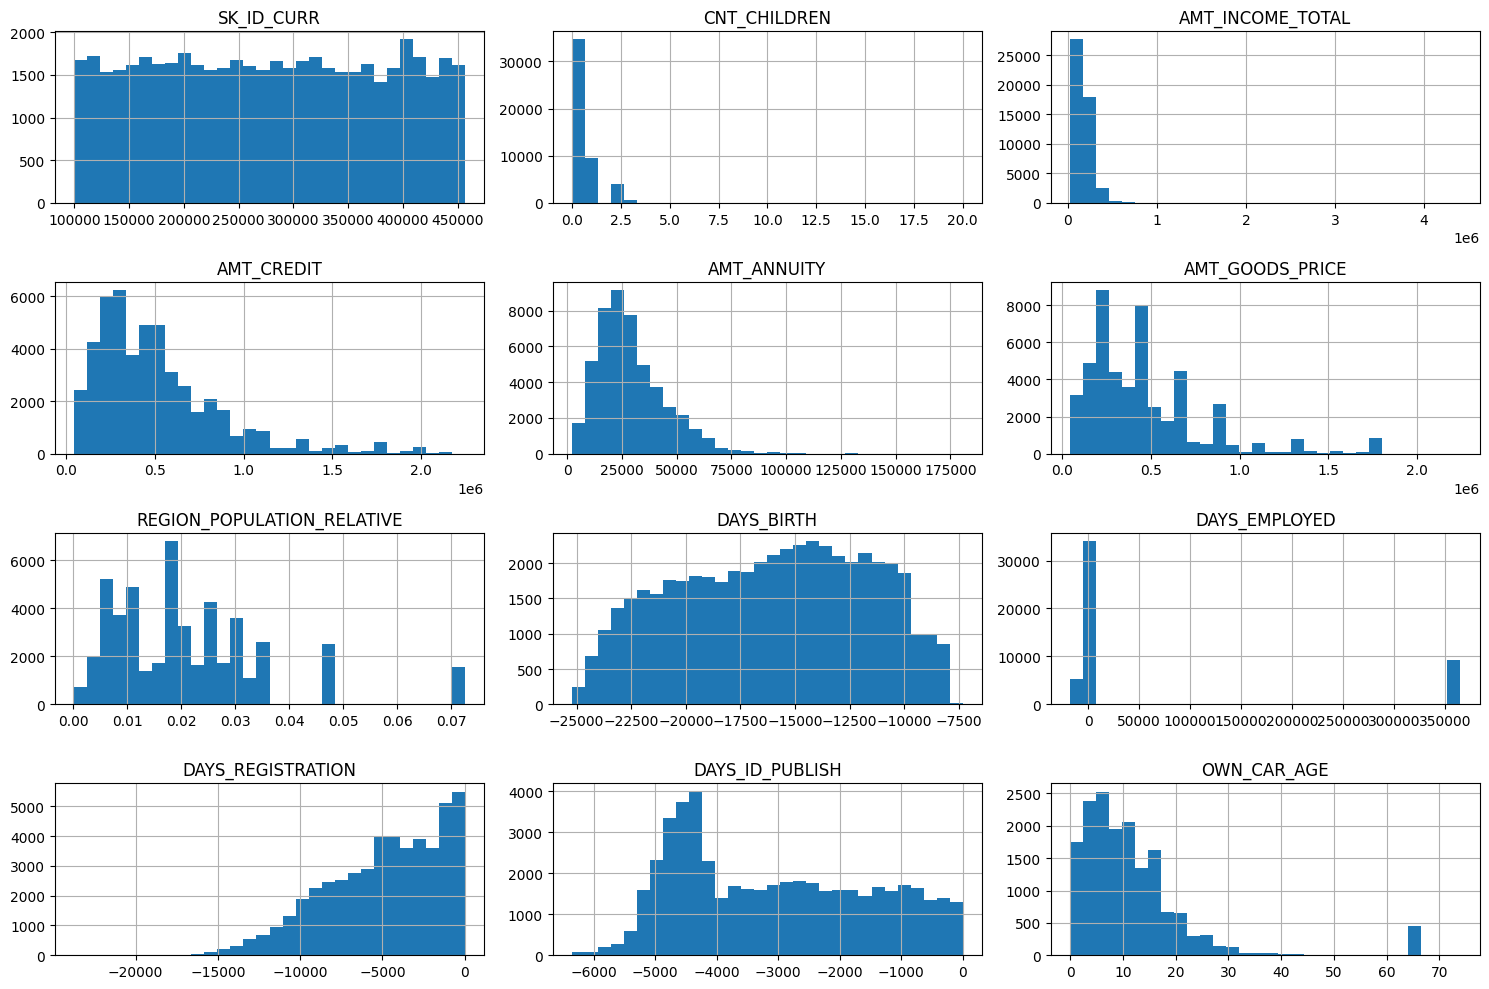

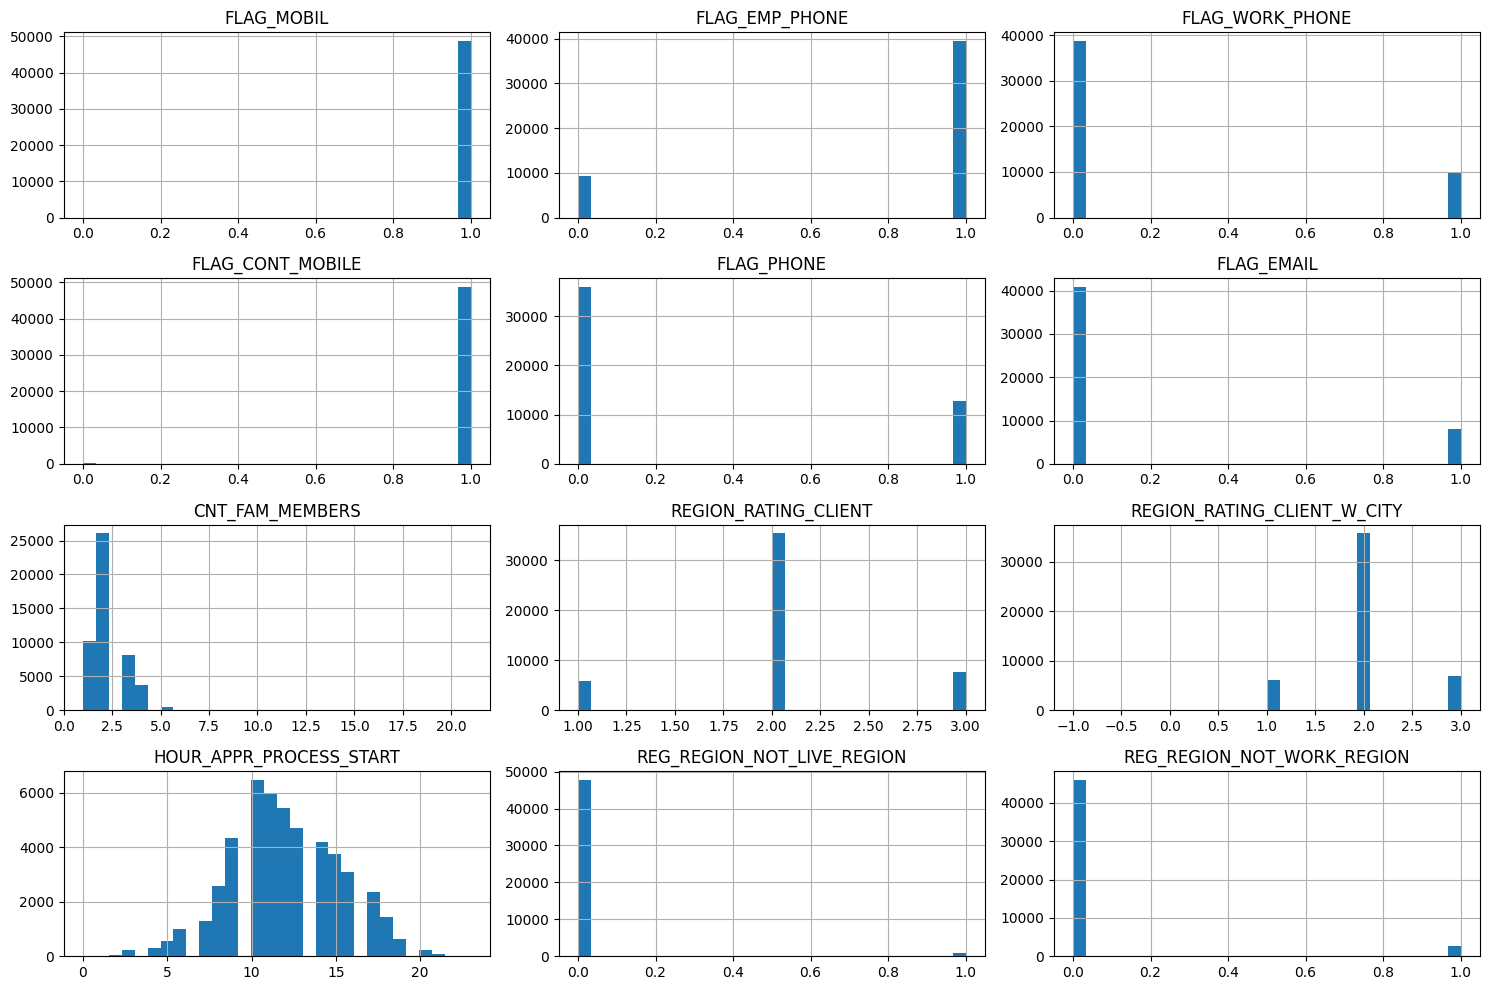

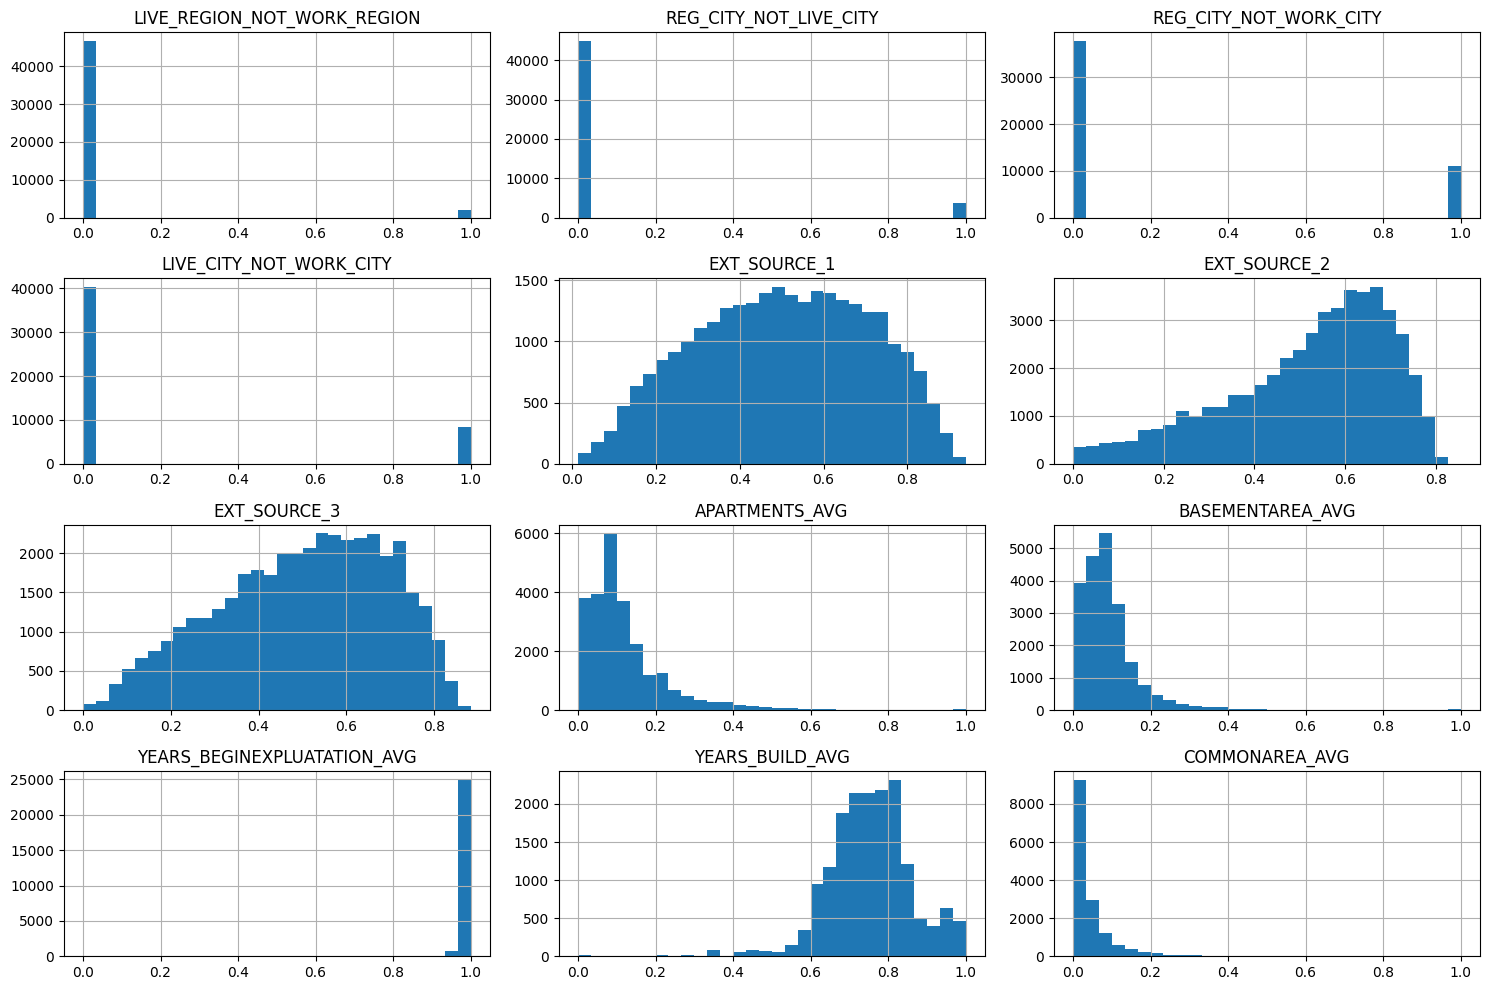

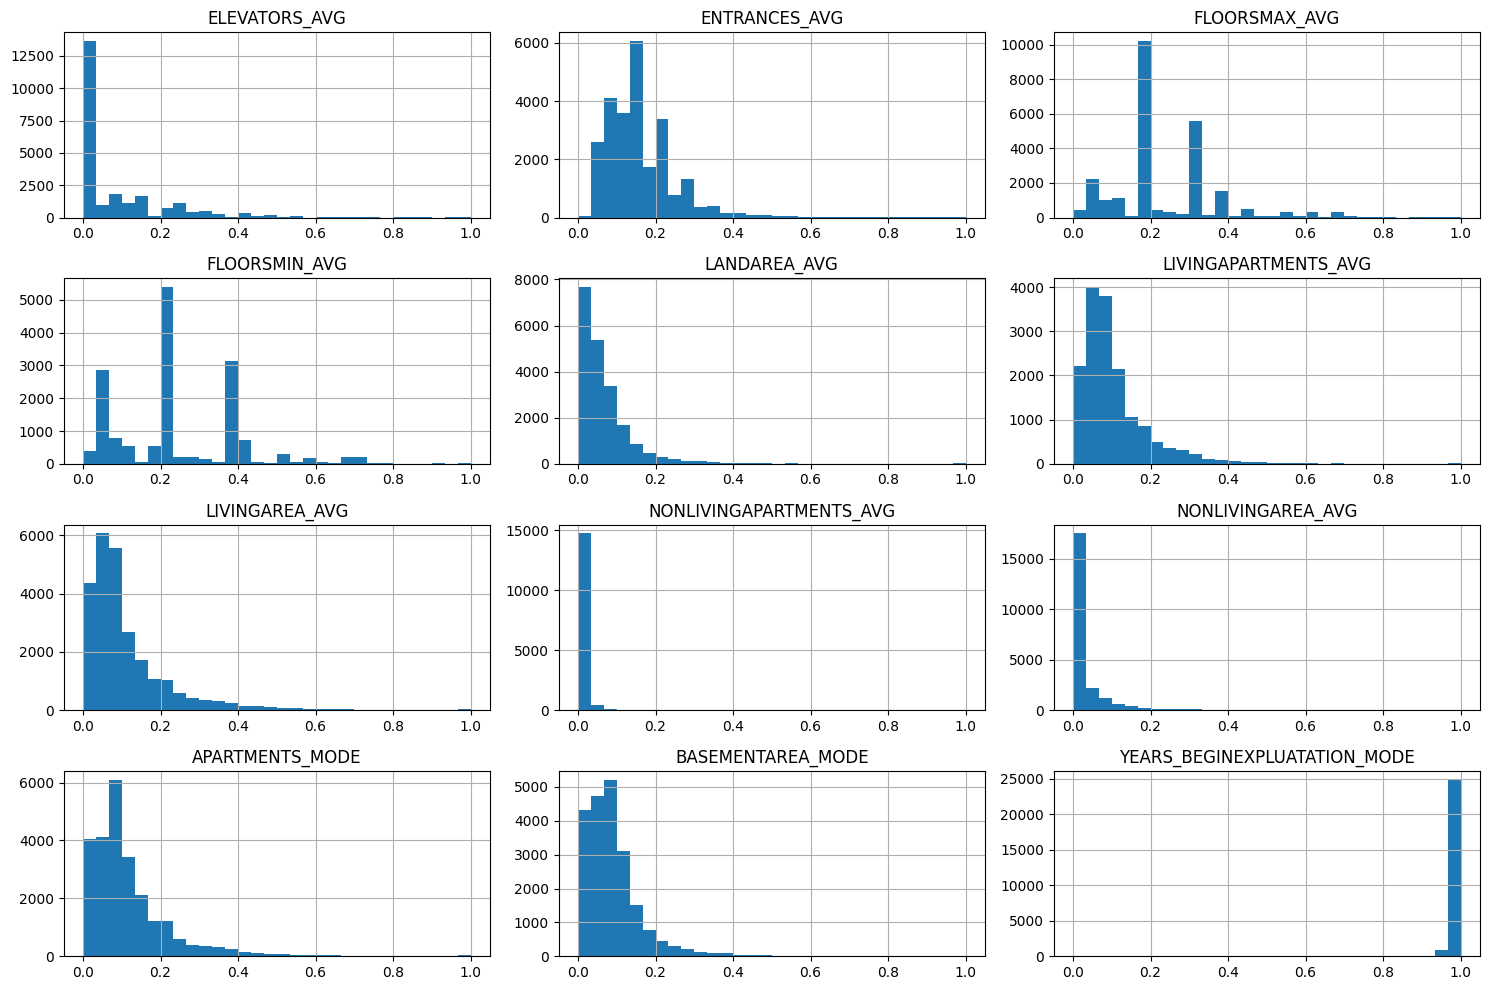

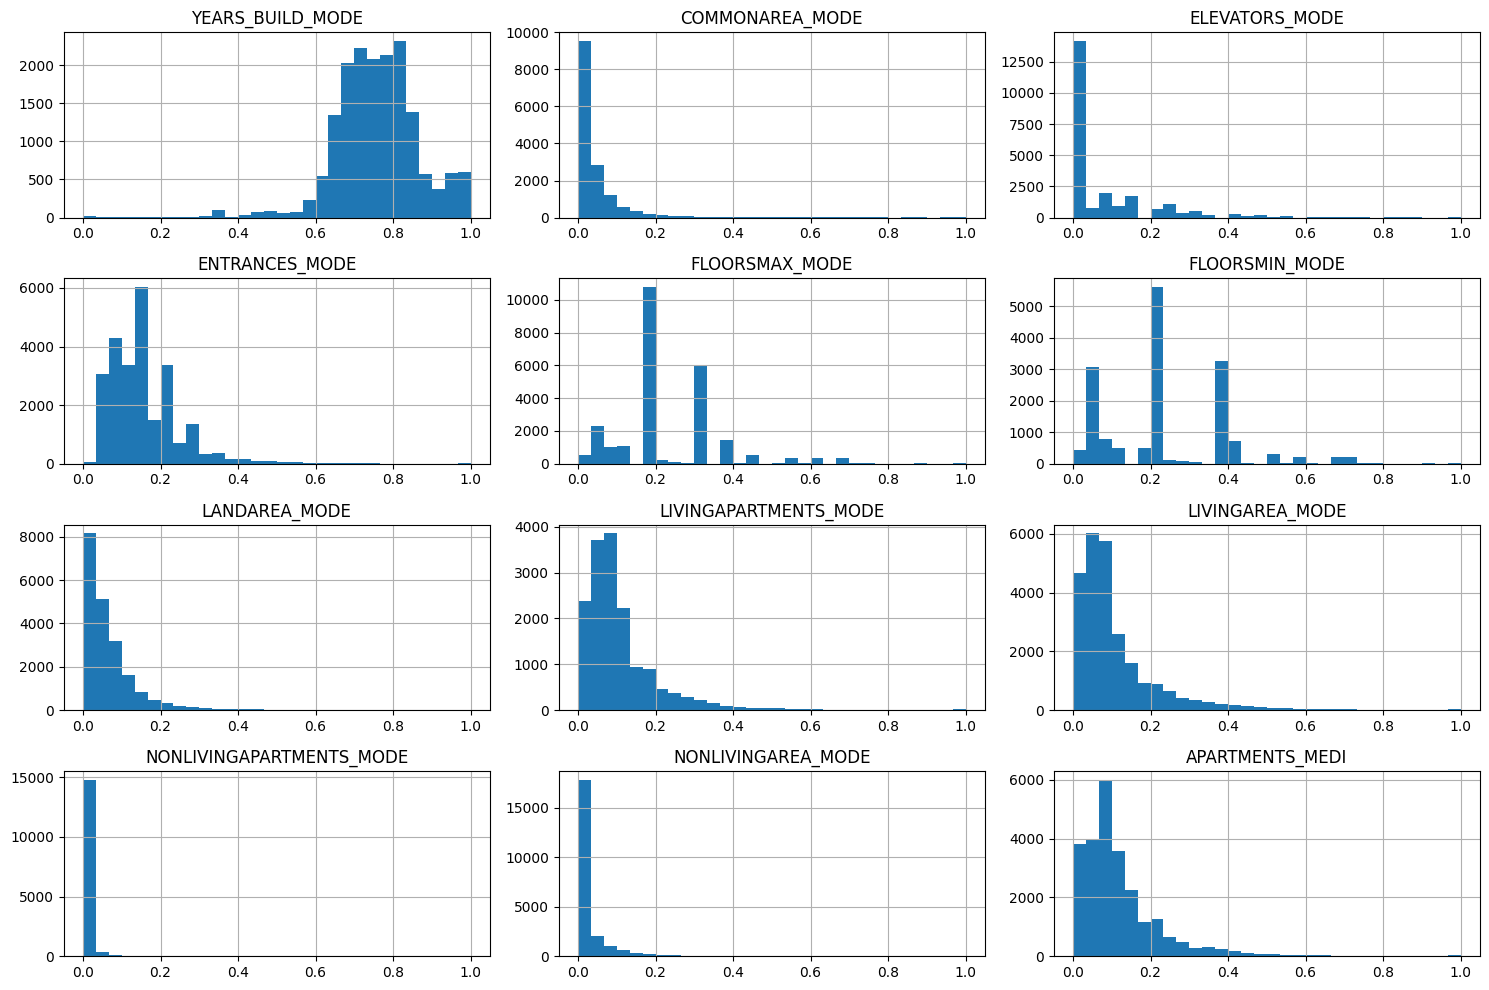

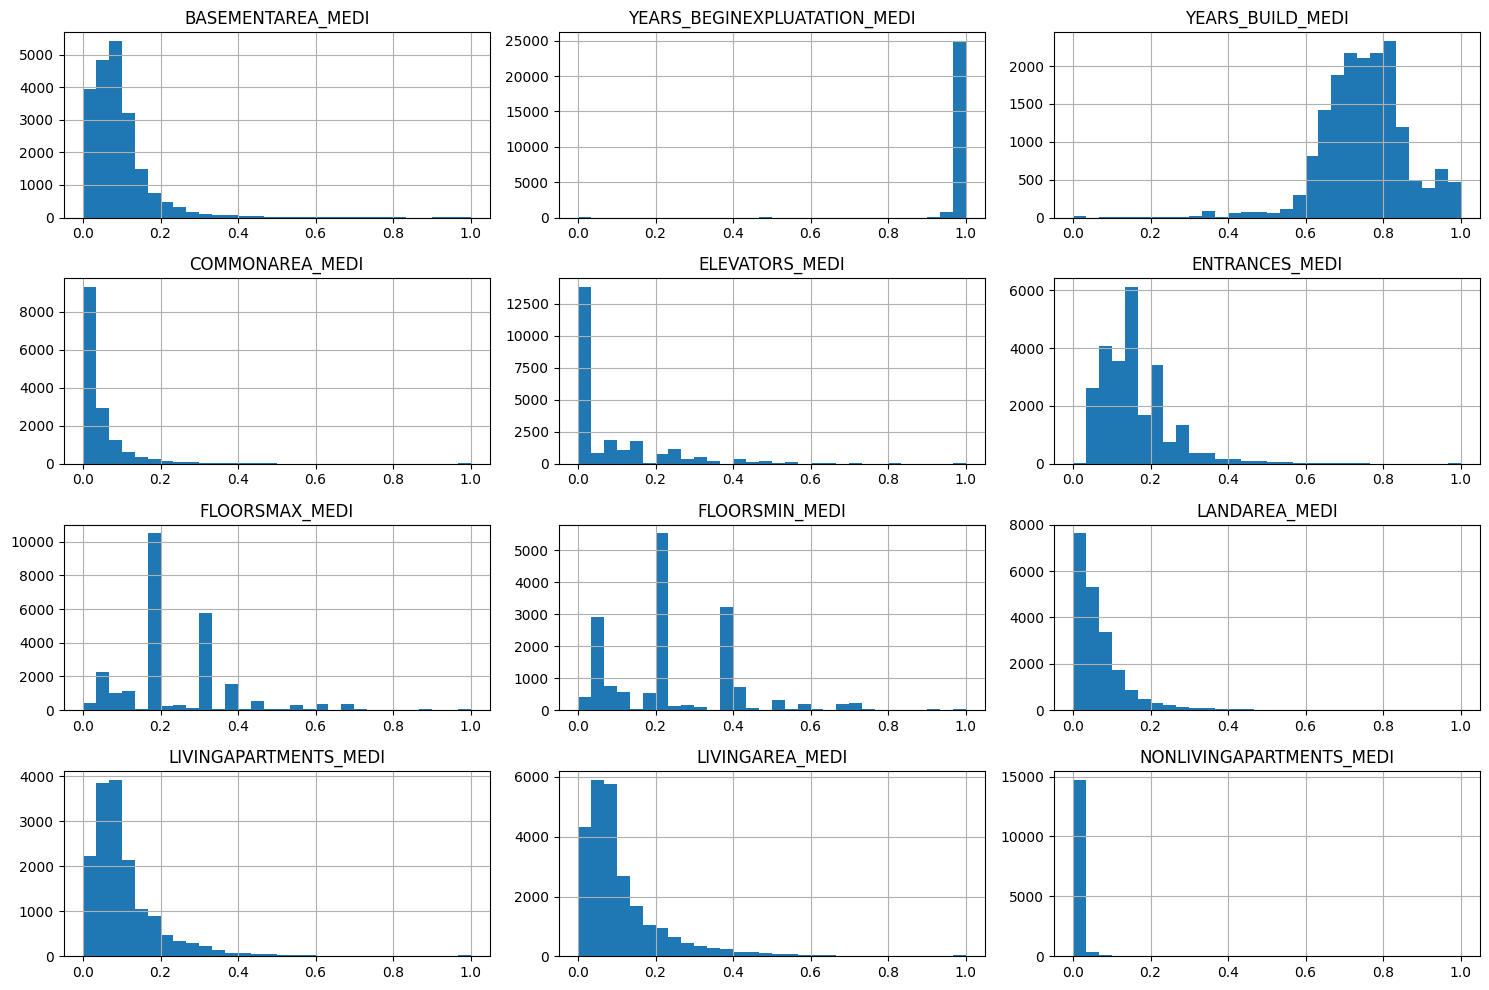

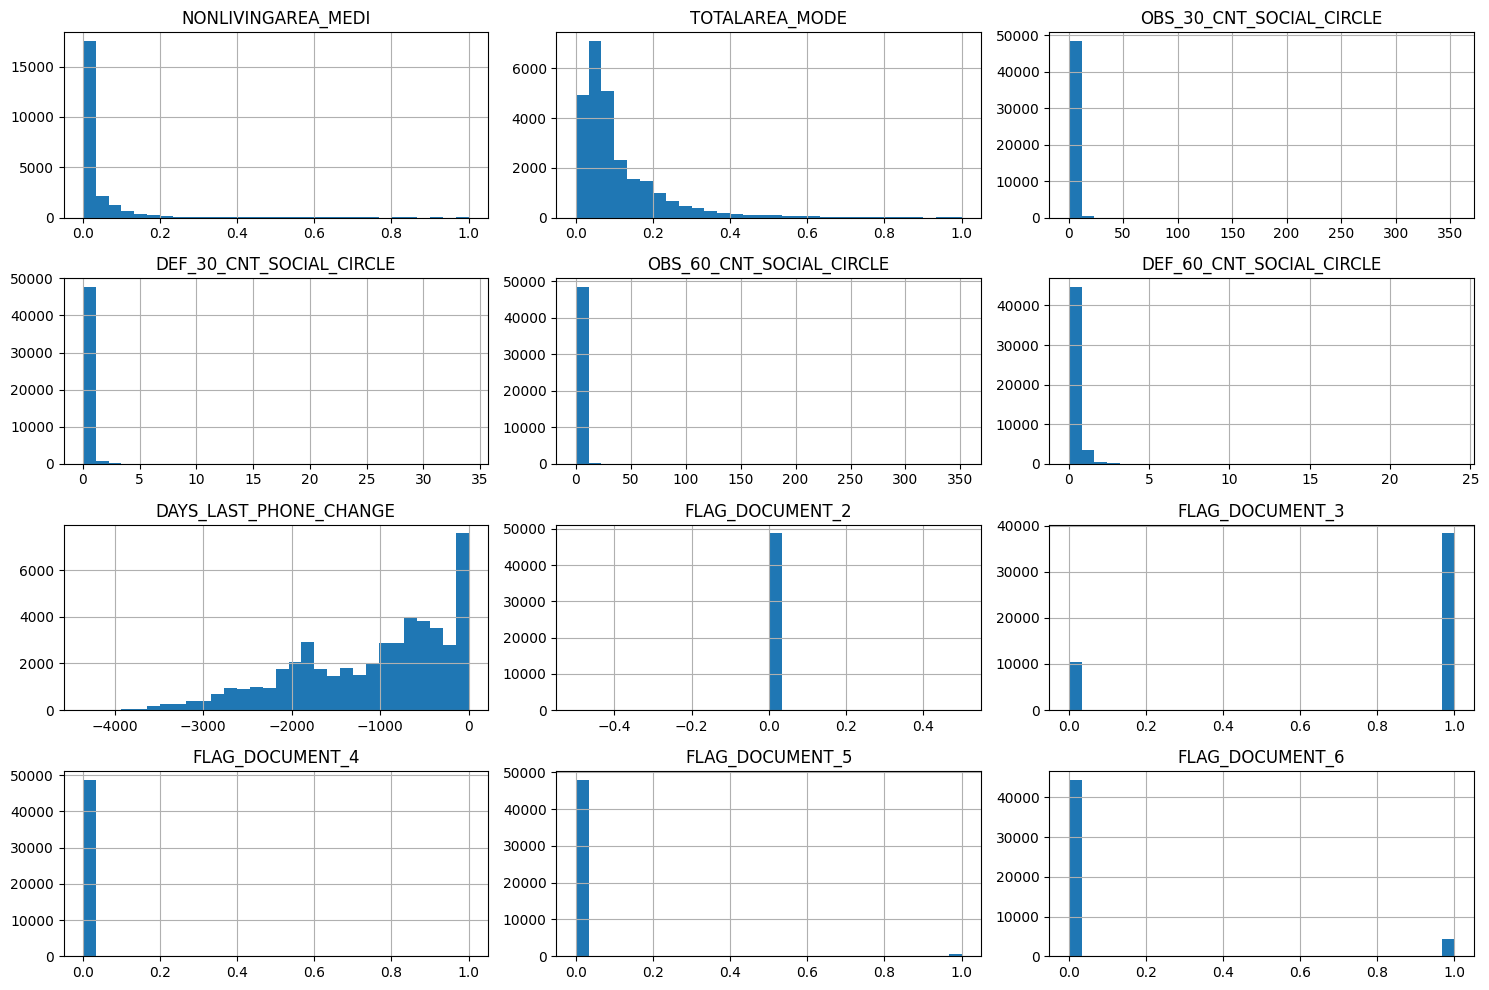

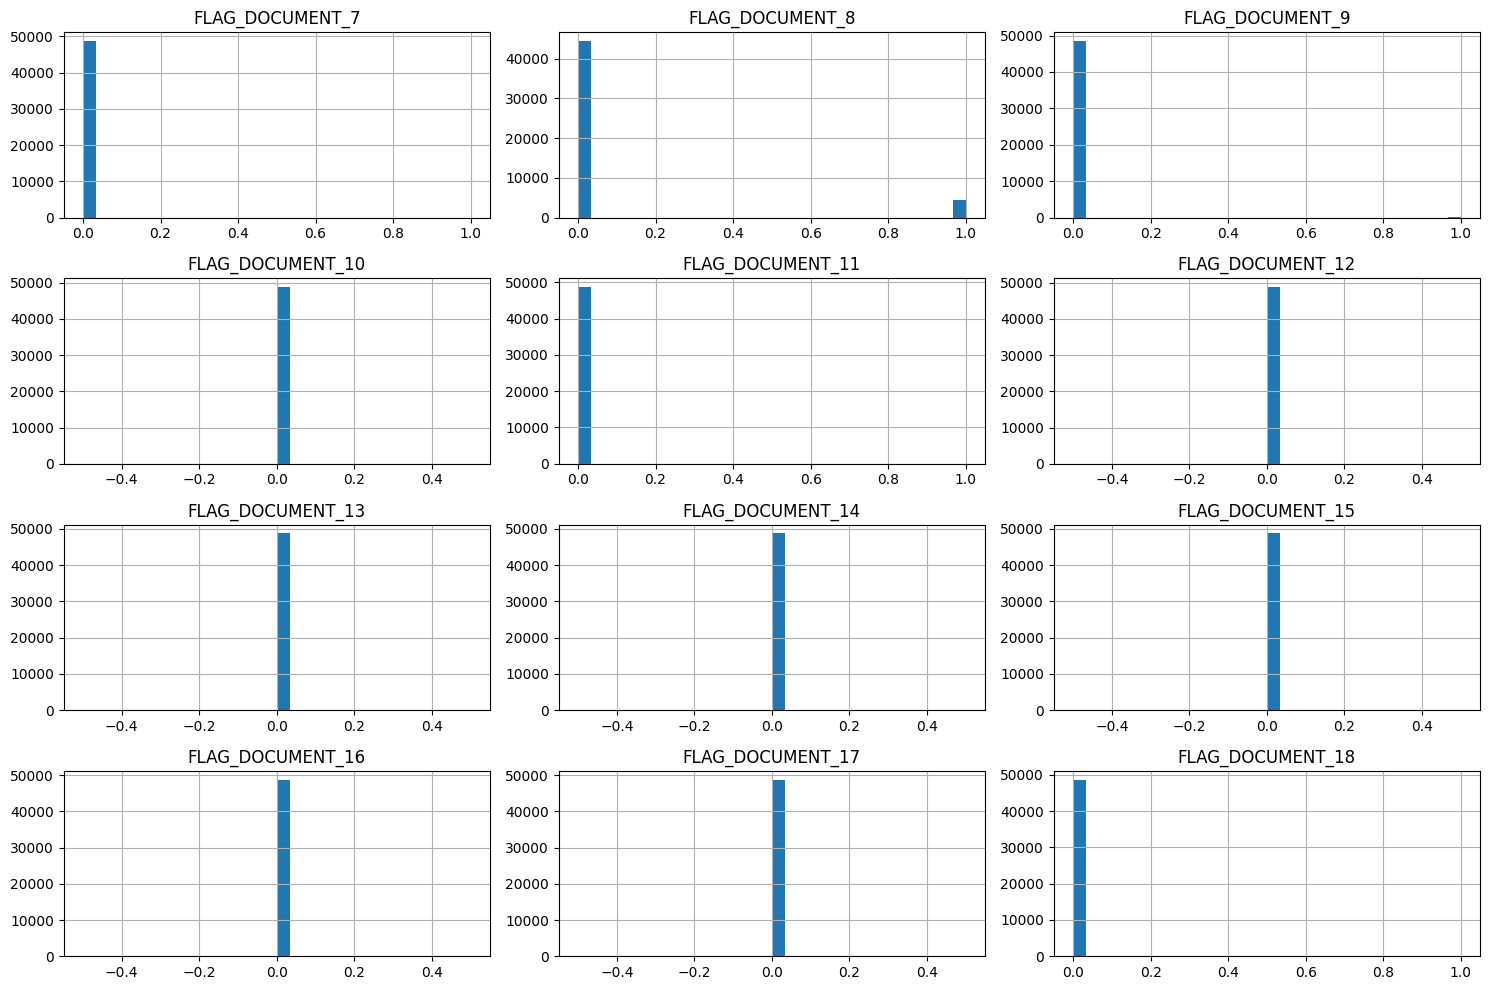

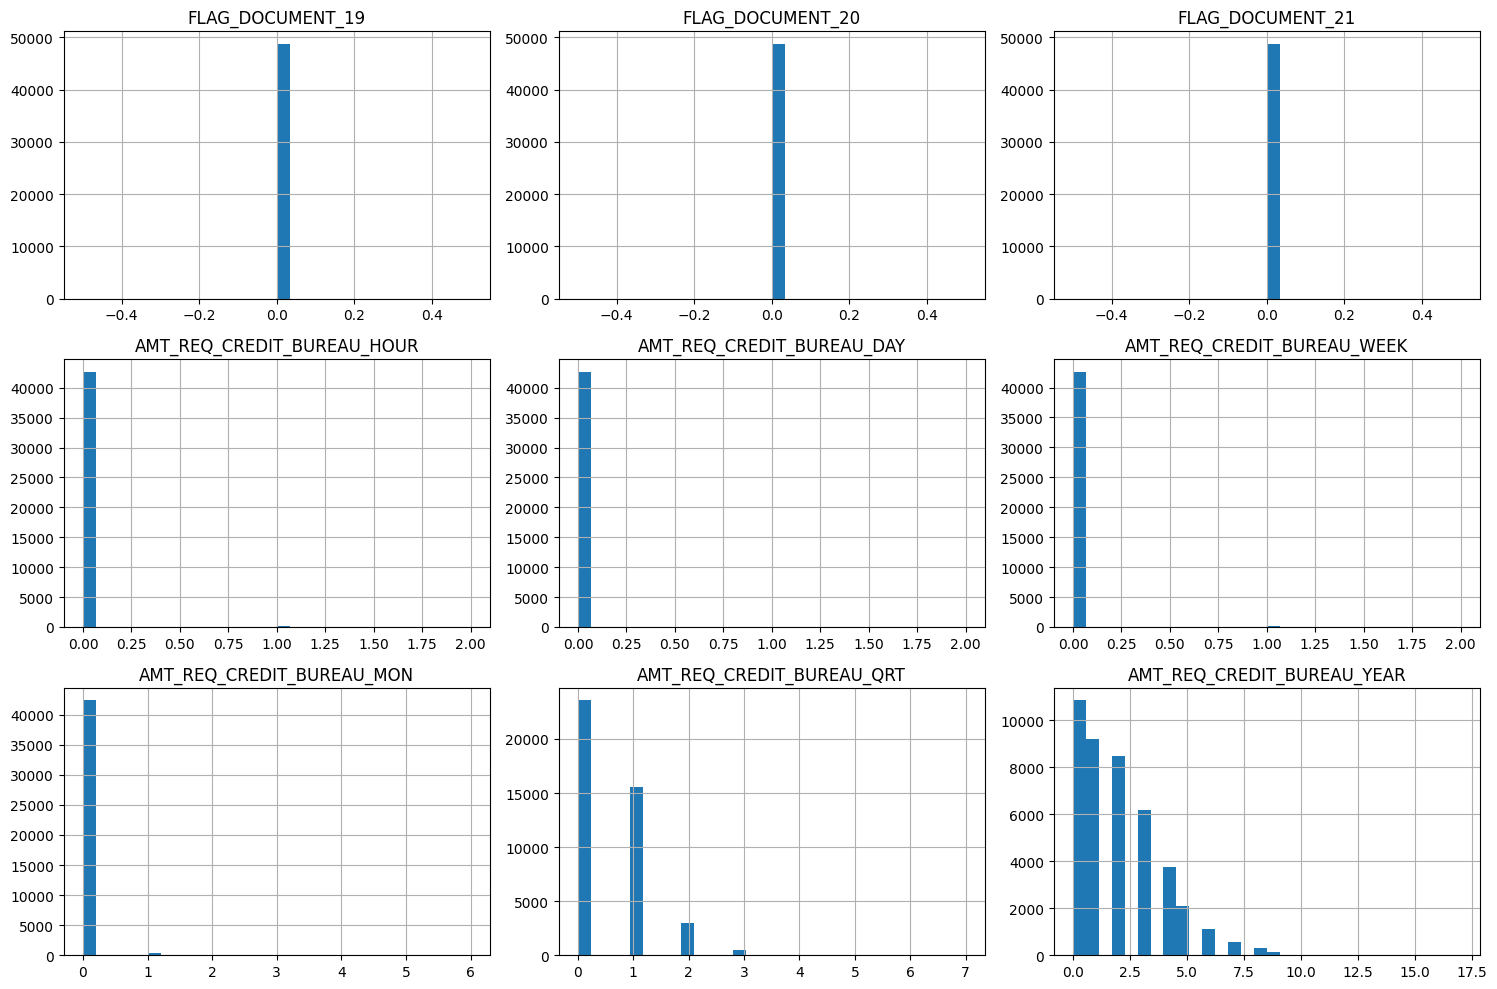

In [337]:
numeric_cols = dfs["application_test"].select_dtypes(include="number").columns
chunk_size = 12

for i in range(0, len(numeric_cols), chunk_size):
    cols_chunk = numeric_cols[i:i + chunk_size]
    dfs["application_test"][cols_chunk].hist(figsize=(15, 10), bins=30)
    plt.tight_layout()
    plt.show()

In [338]:
for c in ['DAYS_BIRTH', 'DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']:
    print(c, (dfs["application_test"][c] == 0).sum())

DAYS_BIRTH 0
DAYS_EMPLOYED 0
DAYS_REGISTRATION 13
DAYS_ID_PUBLISH 5
DAYS_LAST_PHONE_CHANGE 5801


##### 5. bureau table

In [339]:
dfs['bureau']

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.00,-153.00,NaN,0,"91,323.00",0.00,NaN,0.00,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,"1,075.00",NaN,NaN,0,"225,000.00","171,342.00",NaN,0.00,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.00,NaN,NaN,0,"464,323.50",NaN,NaN,0.00,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,"90,000.00",NaN,NaN,0.00,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,"1,197.00",NaN,"77,674.50",0,"2,700,000.00",NaN,NaN,0.00,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.00,NaN,0.00,0,"11,250.00","11,250.00",0.00,0.00,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,"-2,433.00","-2,493.00","5,476.50",0,"38,130.84",0.00,0.00,0.00,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,"-1,628.00",-970.00,NaN,0,"15,570.00",NaN,NaN,0.00,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,"-1,513.00","-1,513.00",NaN,0,"36,000.00",0.00,0.00,0.00,Consumer credit,-1508,NaN


In [340]:
dfs['bureau'].info(verbose=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [341]:
((dfs['bureau'].isnull().sum() / len(dfs['bureau'])) * 100).round(2).sort_values(ascending=False)

AMT_ANNUITY              71.47
AMT_CREDIT_MAX_OVERDUE   65.51
DAYS_ENDDATE_FACT        36.92
AMT_CREDIT_SUM_LIMIT     34.48
AMT_CREDIT_SUM_DEBT      15.01
DAYS_CREDIT_ENDDATE       6.15
CREDIT_ACTIVE             0.00
CREDIT_CURRENCY           0.00
DAYS_CREDIT               0.00
CREDIT_DAY_OVERDUE        0.00
SK_ID_BUREAU              0.00
CNT_CREDIT_PROLONG        0.00
AMT_CREDIT_SUM            0.00
AMT_CREDIT_SUM_OVERDUE    0.00
CREDIT_TYPE               0.00
DAYS_CREDIT_UPDATE        0.00
SK_ID_CURR                0.00
dtype: float64

<Axes: >

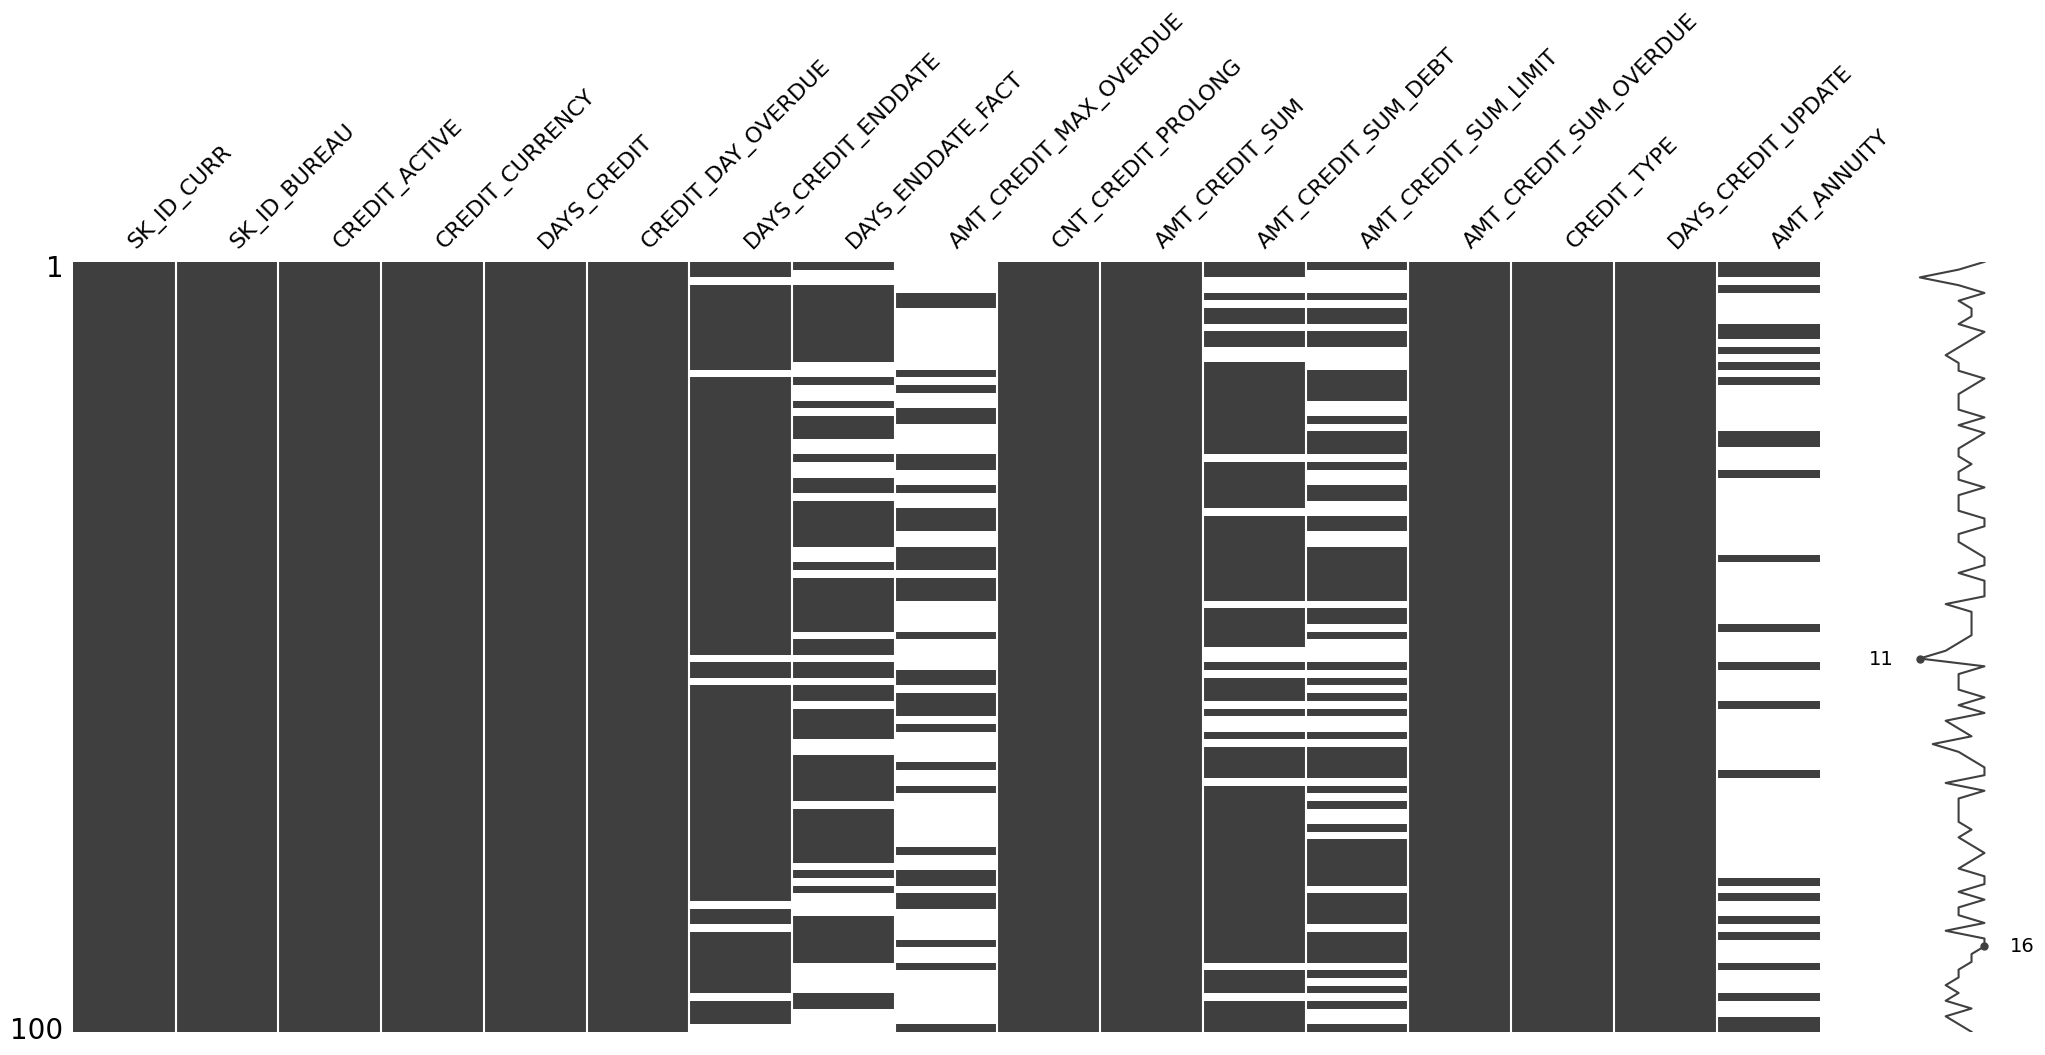

In [342]:
%matplotlib inline
msno.matrix(dfs['bureau'].sample(100))

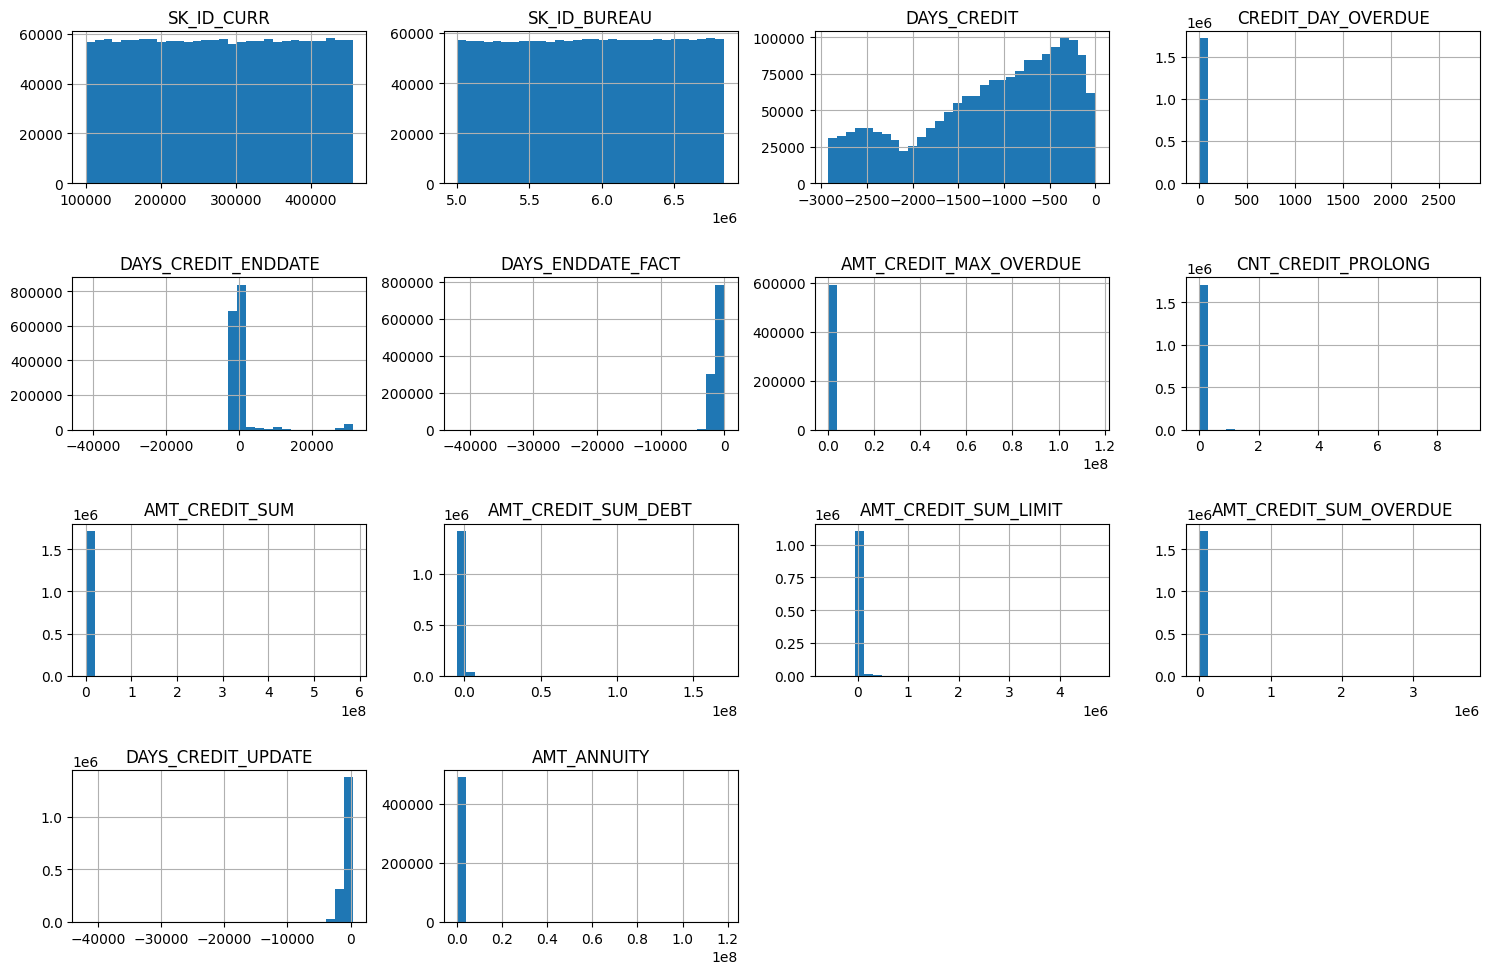

In [343]:
import matplotlib.pyplot as plt

dfs["bureau"].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 6. bureau_balance table

In [344]:
dfs['bureau_balance'].iloc[:200]

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
...,...,...,...
195,5715455,-69,X
196,5715455,-70,X
197,5715455,-71,X
198,5715455,-72,X


In [345]:
dfs['bureau_balance'].info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [346]:
dfs['bureau_balance']['STATUS'].unique()

array(['C', '0', 'X', '1', '2', '3', '5', '4'], dtype=object)

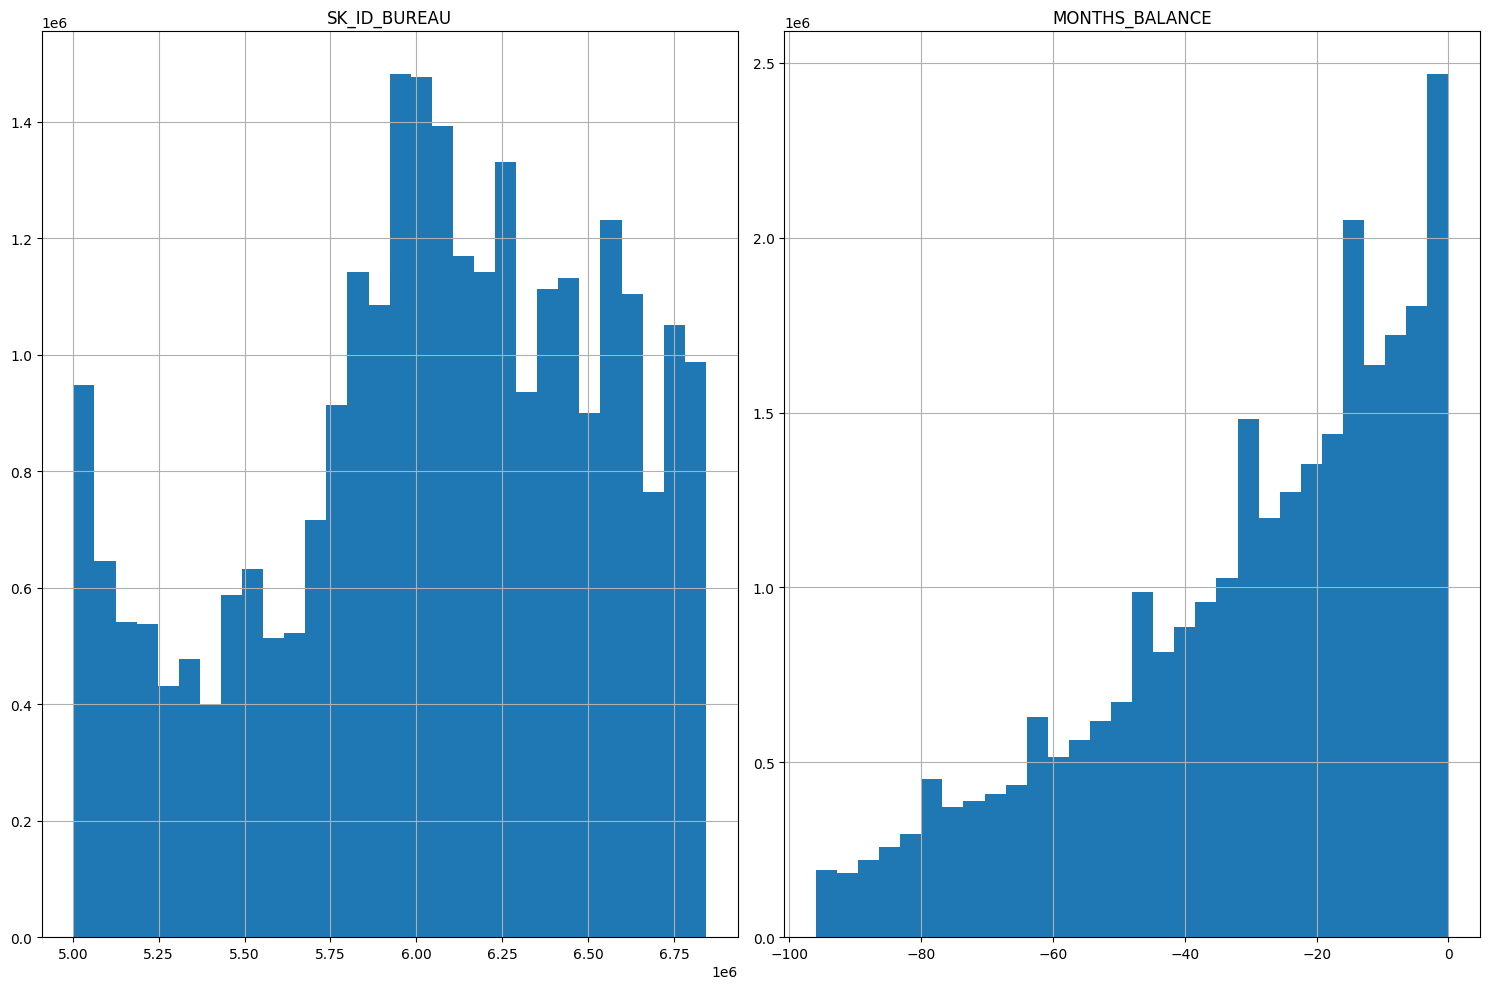

In [347]:
import matplotlib.pyplot as plt

dfs["bureau_balance"].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 7. credit_card_balance table

In [348]:
dfs['credit_card_balance']

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.97,135000,0.00,877.50,0.00,877.50,"1,700.33",...,0.00,0.00,0.00,1,0.00,1.00,35.00,Active,0,0
1,2582071,363914,-1,"63,975.56",45000,"2,250.00","2,250.00",0.00,0.00,"2,250.00",...,"64,875.56","64,875.56",1.00,1,0.00,0.00,69.00,Active,0,0
2,1740877,371185,-7,"31,815.22",450000,0.00,0.00,0.00,0.00,"2,250.00",...,"31,460.08","31,460.08",0.00,0,0.00,0.00,30.00,Active,0,0
3,1389973,337855,-4,"236,572.11",225000,"2,250.00","2,250.00",0.00,0.00,"11,795.76",...,"233,048.97","233,048.97",1.00,1,0.00,0.00,10.00,Active,0,0
4,1891521,126868,-1,"453,919.46",450000,0.00,"11,547.00",0.00,"11,547.00","22,924.89",...,"453,919.46","453,919.46",0.00,1,0.00,1.00,101.00,Active,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3840307,1036507,328243,-9,0.00,45000,NaN,0.00,NaN,NaN,0.00,...,0.00,0.00,NaN,0,NaN,NaN,0.00,Active,0,0
3840308,1714892,347207,-9,0.00,45000,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0,0.00,0.00,23.00,Active,0,0
3840309,1302323,215757,-9,"275,784.97",585000,"270,000.00","270,000.00",0.00,0.00,"2,250.00",...,"273,093.97","273,093.97",2.00,2,0.00,0.00,18.00,Active,0,0
3840310,1624872,430337,-10,0.00,450000,NaN,0.00,NaN,NaN,0.00,...,0.00,0.00,NaN,0,NaN,NaN,0.00,Active,0,0


In [349]:
dfs['credit_card_balance'].info(verbose=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

In [350]:
((dfs['credit_card_balance'].isnull().sum() / len(dfs['credit_card_balance'])) * 100).round(2).sort_values(ascending=False)

AMT_PAYMENT_CURRENT          20.00
AMT_DRAWINGS_ATM_CURRENT     19.52
CNT_DRAWINGS_POS_CURRENT     19.52
AMT_DRAWINGS_OTHER_CURRENT   19.52
AMT_DRAWINGS_POS_CURRENT     19.52
CNT_DRAWINGS_OTHER_CURRENT   19.52
CNT_DRAWINGS_ATM_CURRENT     19.52
CNT_INSTALMENT_MATURE_CUM     7.95
AMT_INST_MIN_REGULARITY       7.95
SK_ID_PREV                    0.00
AMT_TOTAL_RECEIVABLE          0.00
SK_DPD                        0.00
NAME_CONTRACT_STATUS          0.00
CNT_DRAWINGS_CURRENT          0.00
AMT_PAYMENT_TOTAL_CURRENT     0.00
AMT_RECIVABLE                 0.00
AMT_RECEIVABLE_PRINCIPAL      0.00
SK_ID_CURR                    0.00
AMT_DRAWINGS_CURRENT          0.00
AMT_CREDIT_LIMIT_ACTUAL       0.00
AMT_BALANCE                   0.00
MONTHS_BALANCE                0.00
SK_DPD_DEF                    0.00
dtype: float64

<Axes: >

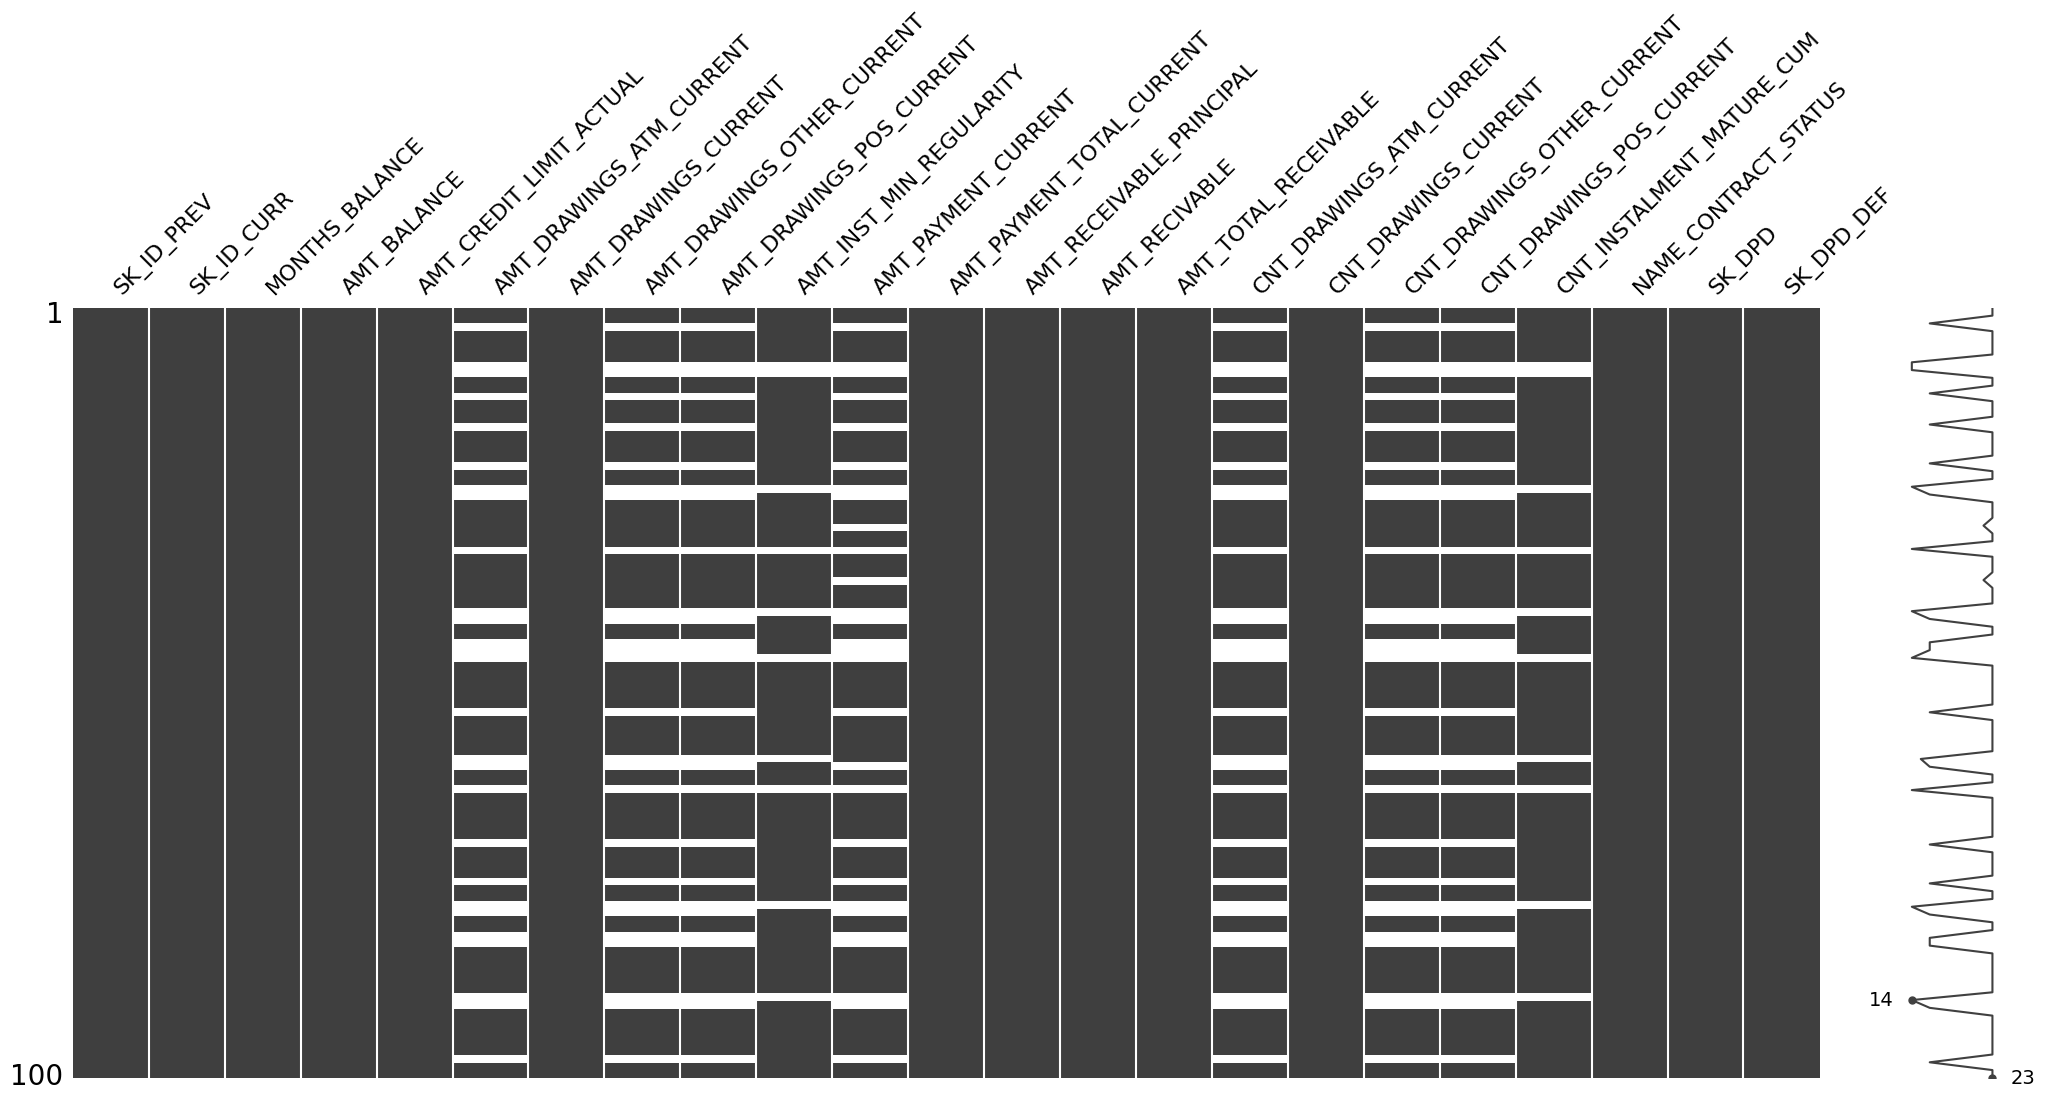

In [351]:
%matplotlib inline
msno.matrix(dfs['credit_card_balance'].sample(100))

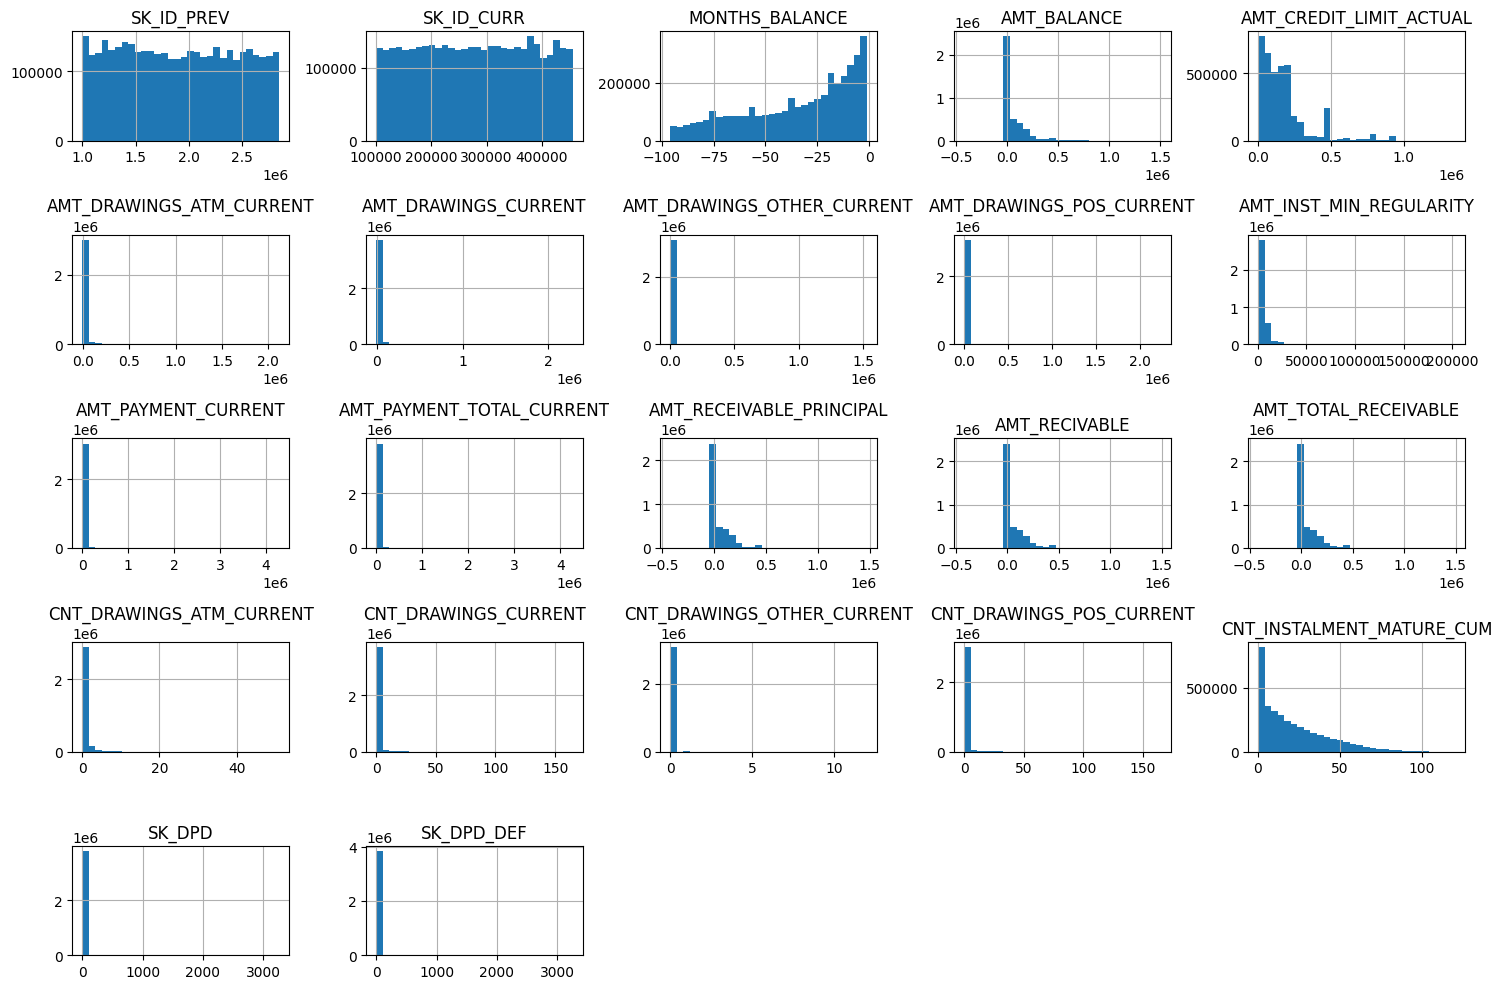

In [352]:
dfs['credit_card_balance'].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 8. installments_payments table

In [353]:
dfs['installments_payments']

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.00,6,"-1,180.00","-1,187.00","6,948.36","6,948.36"
1,1330831,151639,0.00,34,"-2,156.00","-2,156.00","1,716.53","1,716.53"
2,2085231,193053,2.00,1,-63.00,-63.00,"25,425.00","25,425.00"
3,2452527,199697,1.00,3,"-2,418.00","-2,426.00","24,350.13","24,350.13"
4,2714724,167756,1.00,2,"-1,383.00","-1,366.00","2,165.04","2,160.59"
...,...,...,...,...,...,...,...,...
13605396,2186857,428057,0.00,66,"-1,624.00",NaN,67.50,NaN
13605397,1310347,414406,0.00,47,"-1,539.00",NaN,67.50,NaN
13605398,1308766,402199,0.00,43,-7.00,NaN,"43,737.43",NaN
13605399,1062206,409297,0.00,43,"-1,986.00",NaN,67.50,NaN


In [354]:
dfs['installments_payments'].info(verbose=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


In [355]:
((dfs['installments_payments'].isnull().sum() / len(dfs['installments_payments'])) * 100).round(2).sort_values(ascending=False)

DAYS_ENTRY_PAYMENT       0.02
AMT_PAYMENT              0.02
SK_ID_PREV               0.00
SK_ID_CURR               0.00
NUM_INSTALMENT_VERSION   0.00
NUM_INSTALMENT_NUMBER    0.00
DAYS_INSTALMENT          0.00
AMT_INSTALMENT           0.00
dtype: float64

<Axes: >

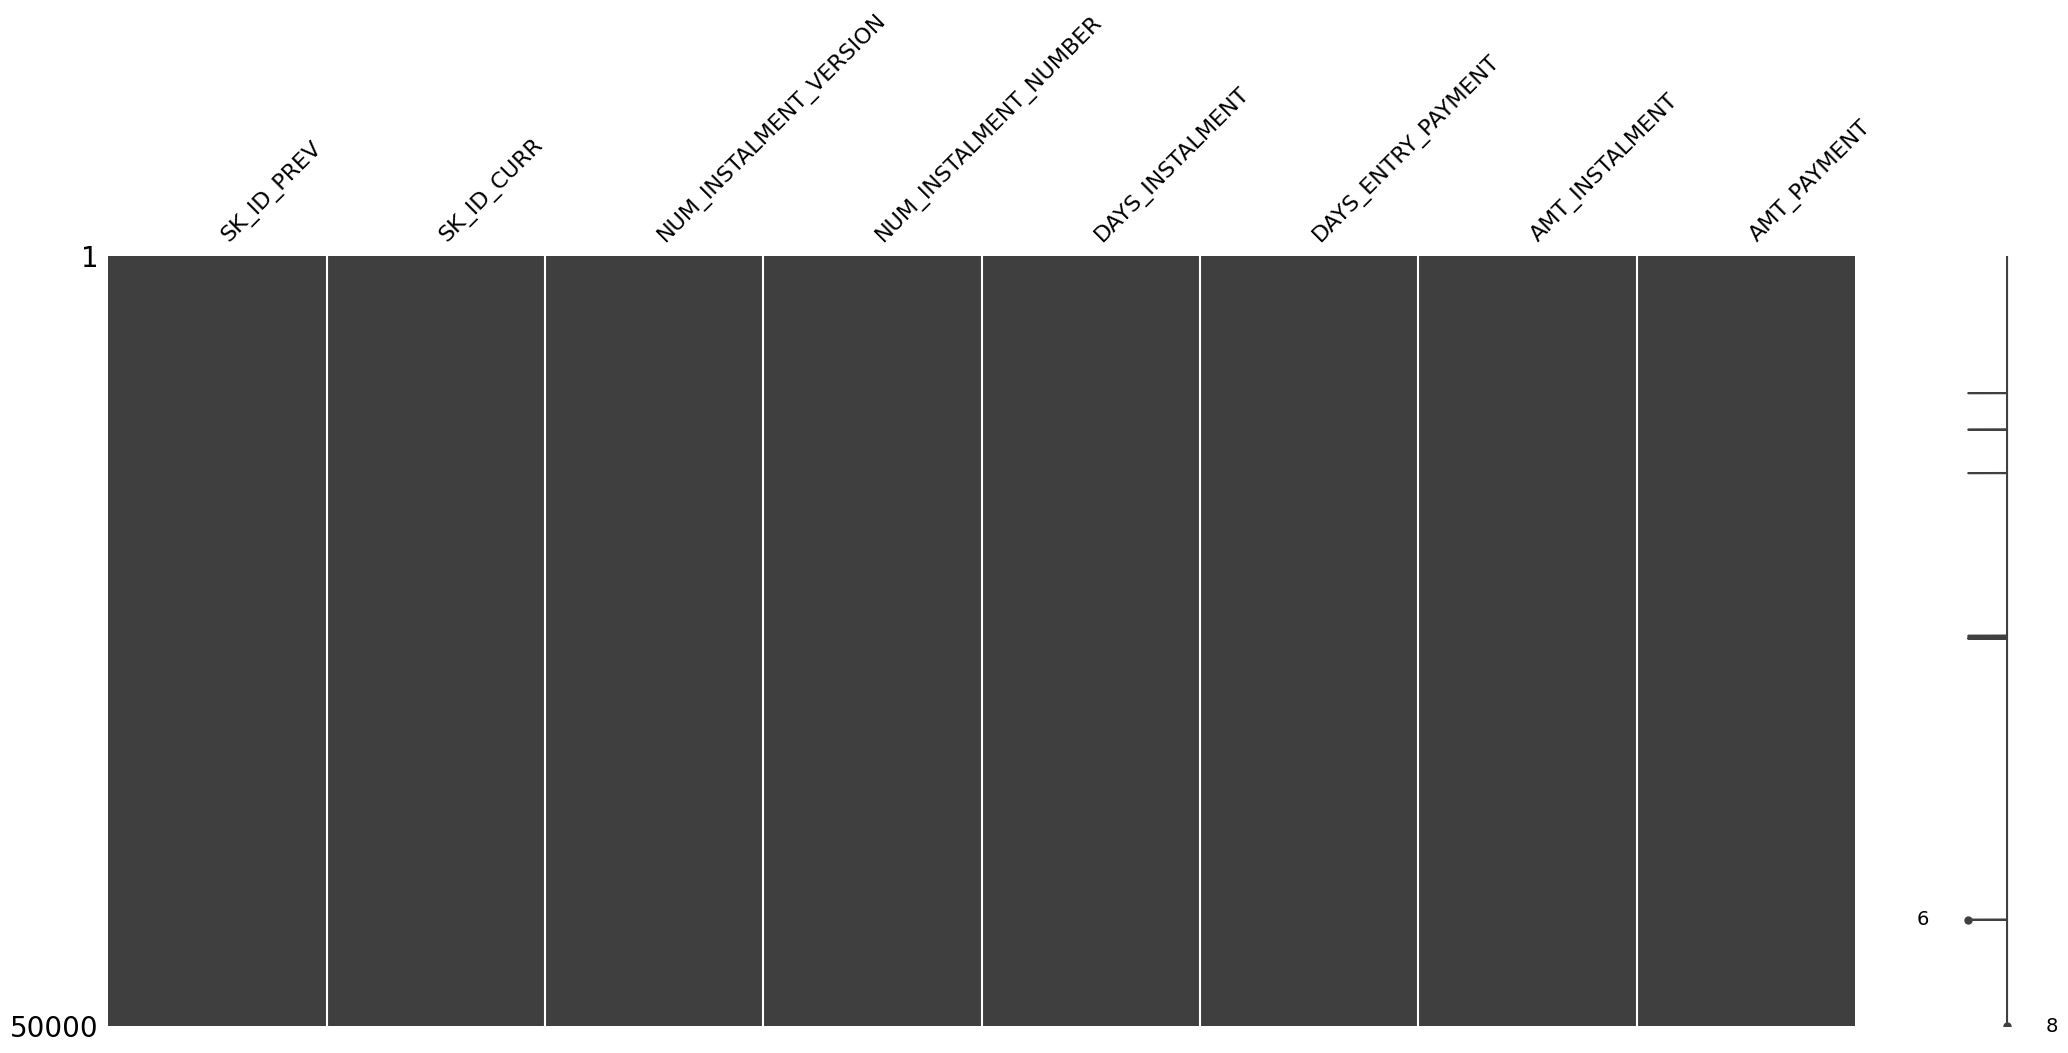

In [356]:
%matplotlib inline
msno.matrix(dfs['installments_payments'].sample(50000))

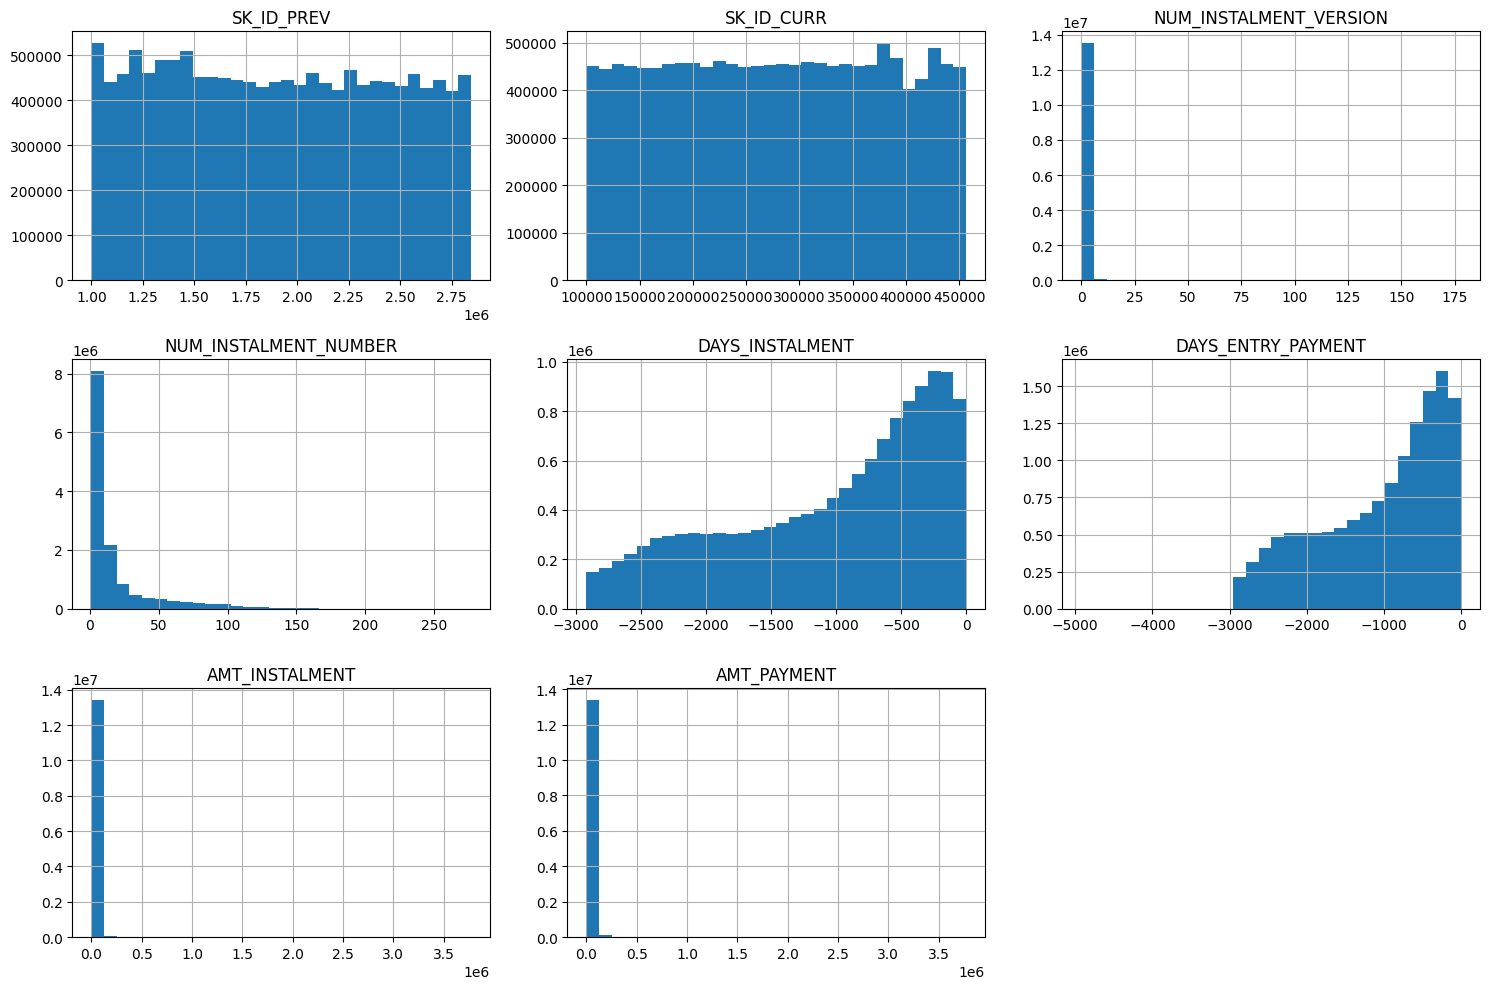

In [357]:
import matplotlib.pyplot as plt

dfs['installments_payments'].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 9. prev_application table

In [358]:
dfs['prev_application']

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,"1,730.43","17,145.00","17,145.00",0.00,"17,145.00",SATURDAY,15,...,Connectivity,12.00,middle,POS mobile with interest,"365,243.00",-42.00,300.00,-42.00,-37.00,0.00
1,2802425,108129,Cash loans,"25,188.62","607,500.00","679,671.00",NaN,"607,500.00",THURSDAY,11,...,XNA,36.00,low_action,Cash X-Sell: low,"365,243.00",-134.00,916.00,"365,243.00","365,243.00",1.00
2,2523466,122040,Cash loans,"15,060.74","112,500.00","136,444.50",NaN,"112,500.00",TUESDAY,11,...,XNA,12.00,high,Cash X-Sell: high,"365,243.00",-271.00,59.00,"365,243.00","365,243.00",1.00
3,2819243,176158,Cash loans,"47,041.33","450,000.00","470,790.00",NaN,"450,000.00",MONDAY,7,...,XNA,12.00,middle,Cash X-Sell: middle,"365,243.00",-482.00,-152.00,-182.00,-177.00,1.00
4,1784265,202054,Cash loans,"31,924.40","337,500.00","404,055.00",NaN,"337,500.00",THURSDAY,9,...,XNA,24.00,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,"14,704.29","267,295.50","311,400.00",0.00,"267,295.50",WEDNESDAY,12,...,Furniture,30.00,low_normal,POS industry with interest,"365,243.00",-508.00,362.00,-358.00,-351.00,0.00
1670210,2357031,334635,Consumer loans,"6,622.02","87,750.00","64,291.50","29,250.00","87,750.00",TUESDAY,15,...,Furniture,12.00,middle,POS industry with interest,"365,243.00","-1,604.00","-1,274.00","-1,304.00","-1,297.00",0.00
1670211,2659632,249544,Consumer loans,"11,520.85","105,237.00","102,523.50","10,525.50","105,237.00",MONDAY,12,...,Consumer electronics,10.00,low_normal,POS household with interest,"365,243.00","-1,457.00","-1,187.00","-1,187.00","-1,181.00",0.00
1670212,2785582,400317,Cash loans,"18,821.52","180,000.00","191,880.00",NaN,"180,000.00",WEDNESDAY,9,...,XNA,12.00,low_normal,Cash X-Sell: low,"365,243.00","-1,155.00",-825.00,-825.00,-817.00,1.00


In [359]:
dfs['prev_application'].info(verbose=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [360]:
((dfs['prev_application'].isnull().sum() / len(dfs['prev_application'])) * 100).round(2).sort_values(ascending=False)

RATE_INTEREST_PRIVILEGED      99.64
RATE_INTEREST_PRIMARY         99.64
RATE_DOWN_PAYMENT             53.64
AMT_DOWN_PAYMENT              53.64
NAME_TYPE_SUITE               49.12
NFLAG_INSURED_ON_APPROVAL     40.30
DAYS_FIRST_DRAWING            40.30
DAYS_FIRST_DUE                40.30
DAYS_LAST_DUE_1ST_VERSION     40.30
DAYS_LAST_DUE                 40.30
DAYS_TERMINATION              40.30
AMT_GOODS_PRICE               23.08
AMT_ANNUITY                   22.29
CNT_PAYMENT                   22.29
PRODUCT_COMBINATION            0.02
CHANNEL_TYPE                   0.00
NAME_PRODUCT_TYPE              0.00
NAME_YIELD_GROUP               0.00
SELLERPLACE_AREA               0.00
NAME_SELLER_INDUSTRY           0.00
NAME_GOODS_CATEGORY            0.00
NAME_PORTFOLIO                 0.00
SK_ID_PREV                     0.00
NAME_CLIENT_TYPE               0.00
CODE_REJECT_REASON             0.00
SK_ID_CURR                     0.00
DAYS_DECISION                  0.00
NAME_CONTRACT_STATUS        

<Axes: >

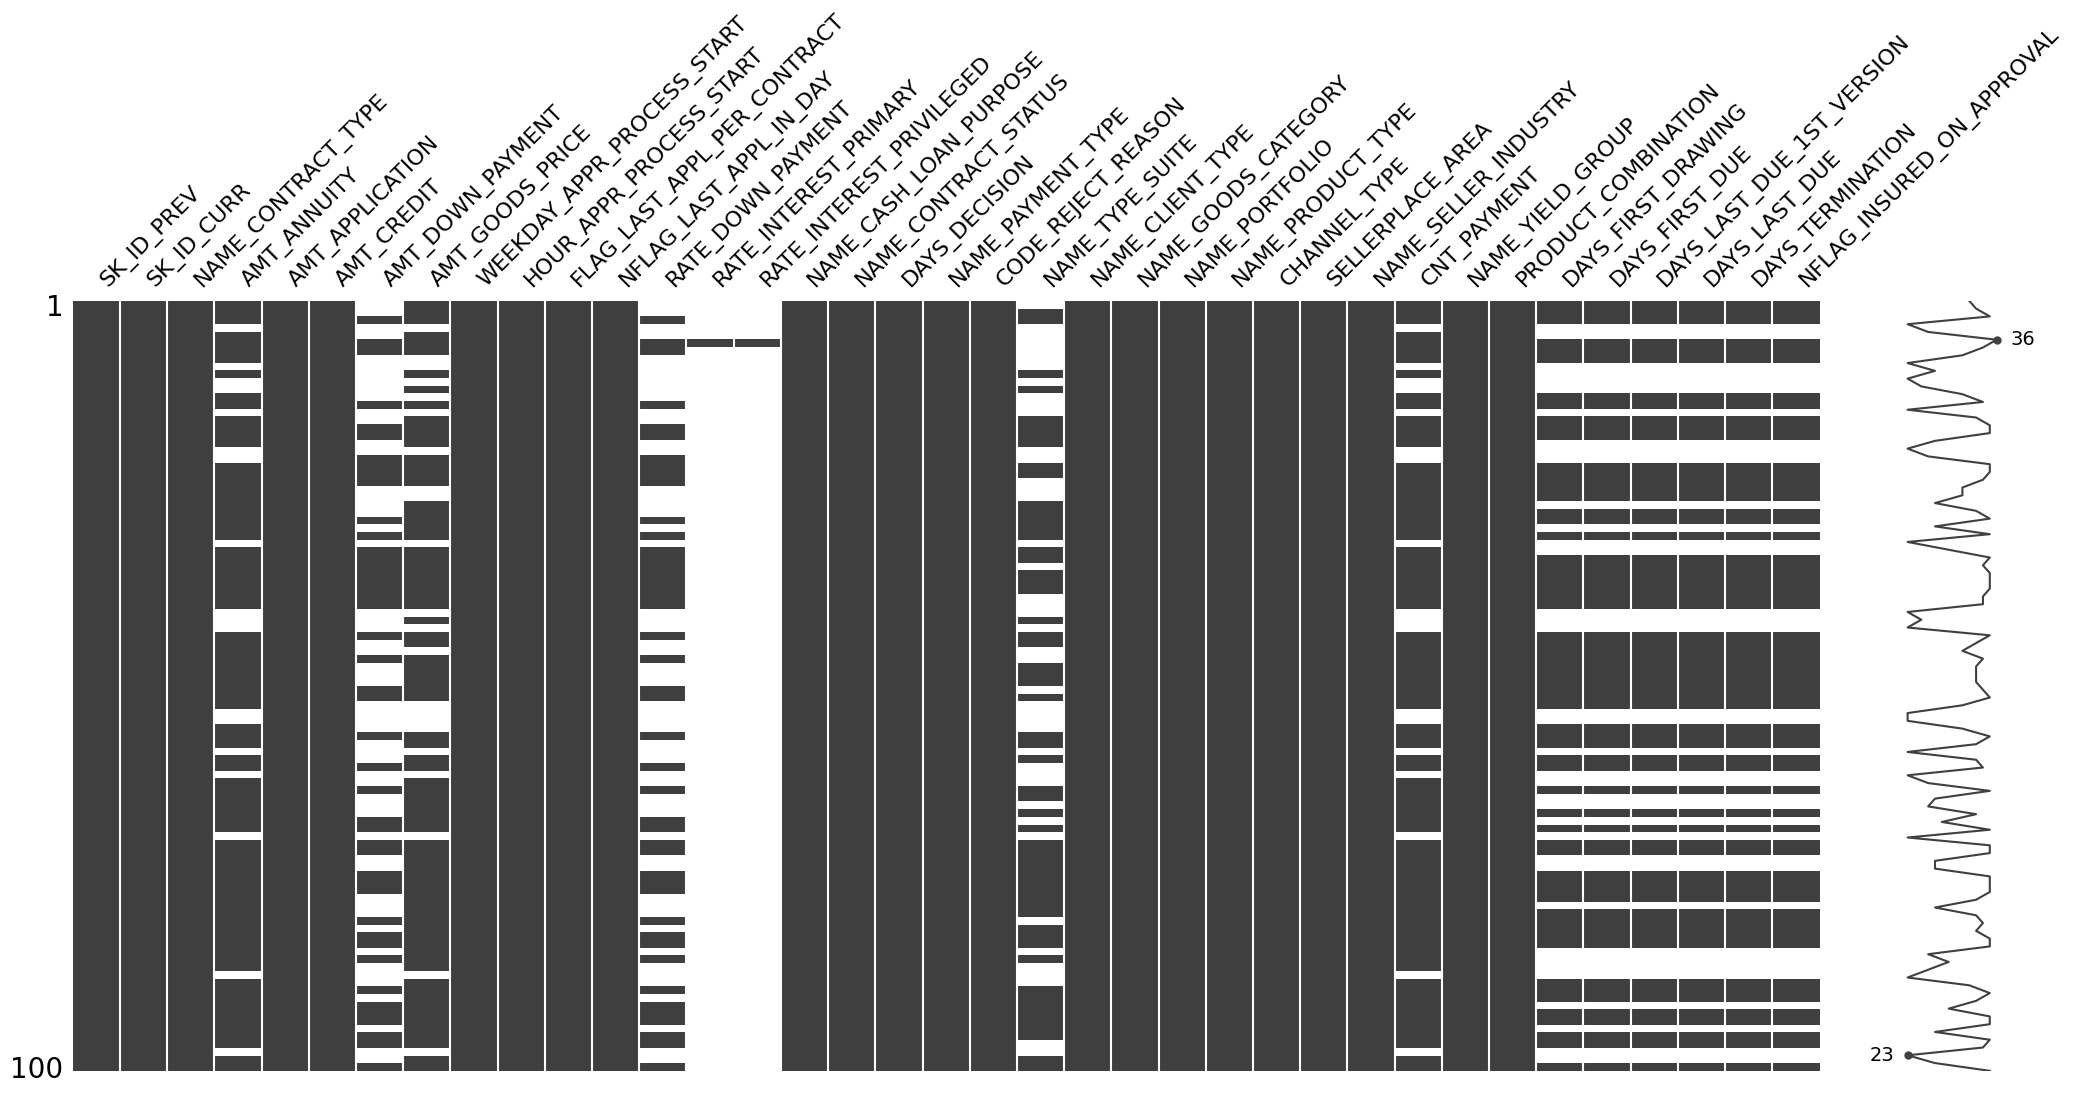

In [361]:
%matplotlib inline
msno.matrix(dfs['prev_application'].sample(100))

In [362]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['prev_application'].nunique().sort_values(ascending=False))

SK_ID_PREV                     1670214
AMT_ANNUITY                     357959
SK_ID_CURR                      338857
RATE_DOWN_PAYMENT               207033
AMT_APPLICATION                  93885
AMT_GOODS_PRICE                  93885
AMT_CREDIT                       86803
AMT_DOWN_PAYMENT                 29278
DAYS_LAST_DUE_1ST_VERSION         4605
DAYS_DECISION                     2922
DAYS_FIRST_DUE                    2892
DAYS_LAST_DUE                     2873
DAYS_FIRST_DRAWING                2838
DAYS_TERMINATION                  2830
SELLERPLACE_AREA                  2097
RATE_INTEREST_PRIMARY              148
CNT_PAYMENT                         49
NAME_GOODS_CATEGORY                 28
NAME_CASH_LOAN_PURPOSE              25
RATE_INTEREST_PRIVILEGED            25
HOUR_APPR_PROCESS_START             24
PRODUCT_COMBINATION                 17
NAME_SELLER_INDUSTRY                11
CODE_REJECT_REASON                   9
CHANNEL_TYPE                         8
NAME_TYPE_SUITE          

In [363]:
for col in dfs['prev_application'].columns:
    n = dfs['prev_application'][col].nunique()
    if (n <= 30 and n > 2): # Only columns with fewer than 30 unique values, but more than 2, are displayed (this excludes flags and other binary columns)
        print(f"{col} ({n} values) :", dfs['prev_application'][col].unique(), "\n")

NAME_CONTRACT_TYPE (4 values) : ['Consumer loans' 'Cash loans' 'Revolving loans' 'XNA'] 

WEEKDAY_APPR_PROCESS_START (7 values) : ['SATURDAY' 'THURSDAY' 'TUESDAY' 'MONDAY' 'FRIDAY' 'SUNDAY' 'WEDNESDAY'] 

HOUR_APPR_PROCESS_START (24 values) : [15 11  7  9  8 10 12 13 14 16  6  4  5 19 17 18 20 22 21  3  1  2 23  0] 

RATE_INTEREST_PRIVILEGED (25 values) : [0.86733615        nan 0.83509514 0.56871036 0.84513742 0.852537
 0.71564482 0.63794926 0.82082452 0.4244186  0.83245243 0.6448203
 0.51374207 0.54281184 0.37315011 0.80655391 0.50211416 0.63742072
 0.72515856 0.78065539 1.         0.54809725 0.79069767 0.48414376
 0.43657505 0.85465116] 

NAME_CASH_LOAN_PURPOSE (25 values) : ['XAP' 'XNA' 'Repairs' 'Everyday expenses' 'Car repairs'
 'Building a house or an annex' 'Other' 'Journey'
 'Purchase of electronic equipment' 'Medicine' 'Payments on other loans'
 'Urgent needs' 'Buying a used car' 'Buying a new car'
 'Buying a holiday home / land' 'Education' 'Buying a home' 'Furniture'
 'Buyin

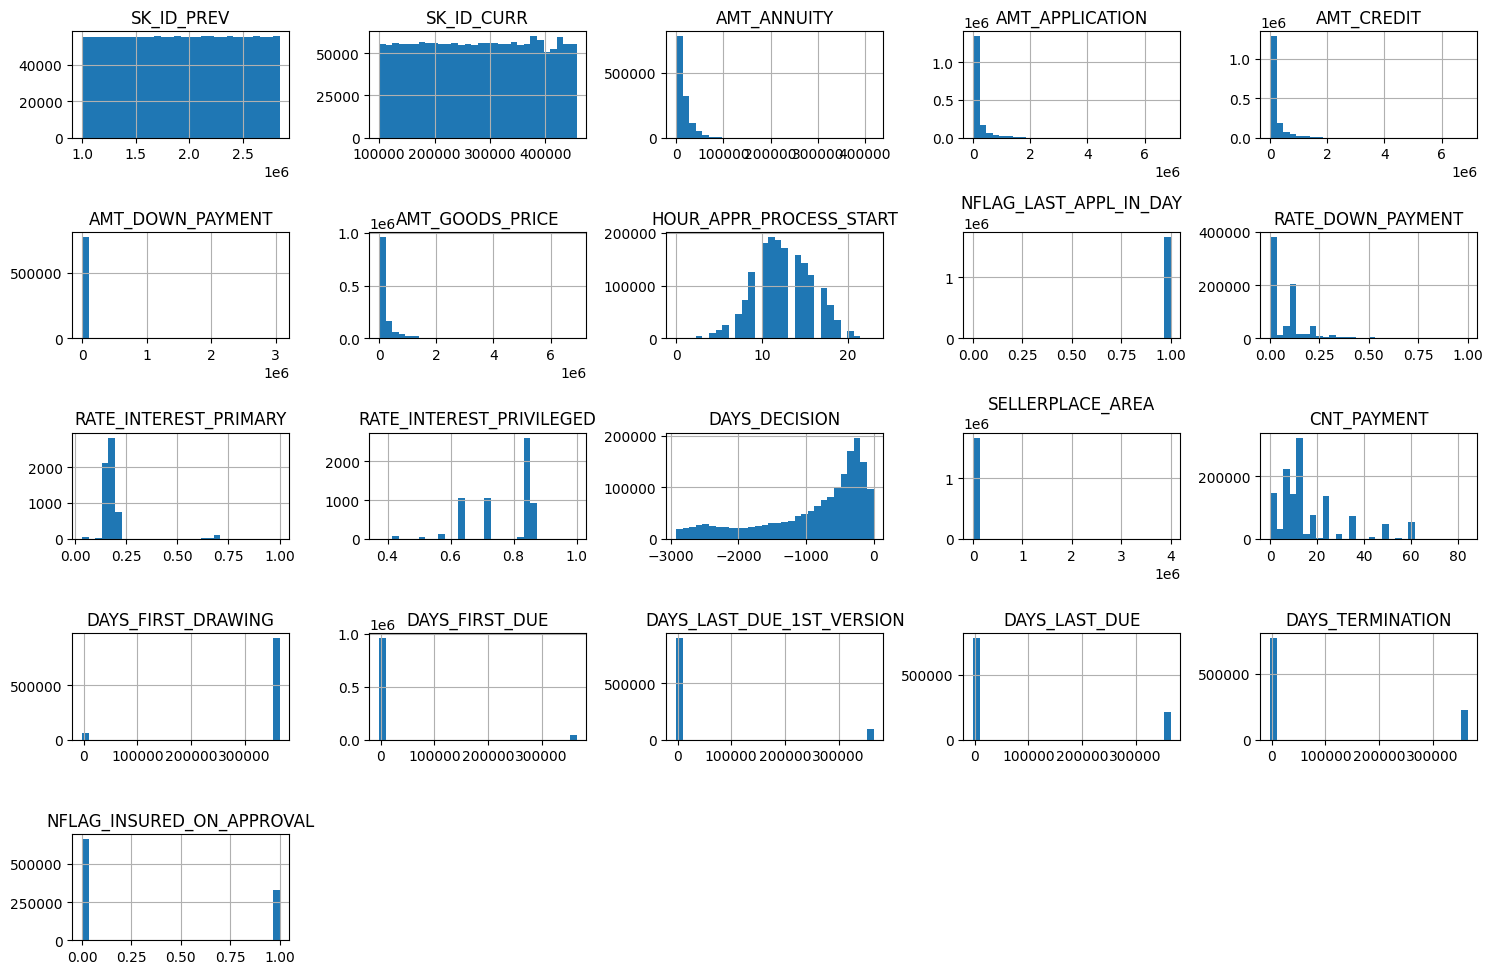

In [364]:
import matplotlib.pyplot as plt

dfs['prev_application'].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 10. sample_submission table

In [365]:
dfs['sample_submission']

,SK_ID_CURR,TARGET
0,100001,0.50
1,100005,0.50
2,100013,0.50
3,100028,0.50
4,100038,0.50
...,...,...
48739,456221,0.50
48740,456222,0.50
48741,456223,0.50
48742,456224,0.50


In [366]:
dfs['sample_submission']['TARGET'].unique()

array([0.5])

# B. AGGREGATE & MERGE

## 1. BUREAU & BUREAU_BALANCE

### 1. 1. Aggregation on SK_ID_BUREAU

#### 1. 1. a) Bureau

In [367]:
dfs['bureau']

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.00,-153.00,NaN,0,"91,323.00",0.00,NaN,0.00,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,"1,075.00",NaN,NaN,0,"225,000.00","171,342.00",NaN,0.00,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.00,NaN,NaN,0,"464,323.50",NaN,NaN,0.00,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,"90,000.00",NaN,NaN,0.00,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,"1,197.00",NaN,"77,674.50",0,"2,700,000.00",NaN,NaN,0.00,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.00,NaN,0.00,0,"11,250.00","11,250.00",0.00,0.00,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,"-2,433.00","-2,493.00","5,476.50",0,"38,130.84",0.00,0.00,0.00,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,"-1,628.00",-970.00,NaN,0,"15,570.00",NaN,NaN,0.00,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,"-1,513.00","-1,513.00",NaN,0,"36,000.00",0.00,0.00,0.00,Consumer credit,-1508,NaN


In [368]:
dfs['bureau']['CREDIT_ACTIVE'].unique()

array(['Closed', 'Active', 'Sold', 'Bad debt'], dtype=object)

In [369]:
dfs['bureau_balance']

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
...,...,...,...
27299920,5041336,-47,X
27299921,5041336,-48,X
27299922,5041336,-49,X
27299923,5041336,-50,X


In [370]:
dfs['bureau_balance'][dfs['bureau_balance']['SK_ID_BUREAU']==5715448]

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
5,5715448,-5,C
6,5715448,-6,C
7,5715448,-7,C
8,5715448,-8,C
9,5715448,-9,0


A **credit bureau** is an external organisation that *centralises all of a person's credits, gathered from different lending institutions*. 

A client might have a mortgage with one bank, a credit card with another, and a car loan at a dealership — *the credit bureau knows about all of them and tracks them.* 

As a result, a client can have several credits (one `SK_ID_CURR` mapped to several `SK_ID_BUREAU`) in the bureau table. For example, three rows sharing the same `SK_ID_CURR` (each with a different `SK_ID_BUREAU`) mean the client has three different credits.

**bureau_balance** gives further detail on the payment `STATUS` of each credit, month by month, since it was opened. For example, if a `SK_ID_BUREAU` has 24 rows, it means this specific credit has been monitored monthly for the past 2 years, and it is linked back to a `SK_ID_CURR`, the client ID.

#### 1. 1. b) Bureau Balance

In [371]:
# PREPARE BUREAU_BALANCE (aggregation)
df_bureau_balance_agg = (
    dfs['bureau_balance']
    .groupby('SK_ID_BUREAU')['STATUS']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

df_bureau_balance_agg.columns.name = None
df_bureau_balance_agg

,SK_ID_BUREAU,0,1,2,3,4,5,C,X
0,5001709,0,0,0,0,0,0,86,11
1,5001710,5,0,0,0,0,0,48,30
2,5001711,3,0,0,0,0,0,0,1
3,5001712,10,0,0,0,0,0,9,0
4,5001713,0,0,0,0,0,0,0,22
...,...,...,...,...,...,...,...,...,...
817390,6842884,9,0,0,0,0,0,20,19
817391,6842885,12,0,0,0,0,12,0,0
817392,6842886,8,0,0,0,0,0,25,0
817393,6842887,6,0,0,0,0,0,31,0


The method we use is `groupby('SK_ID_BUREAU')['STATUS'].value_counts().unstack(fill_value=0)`, which, for each credit (SK_ID_BUREAU), counts how many months were spent in each STATUS category, then reshapes the result so that each STATUS value becomes its own column.

### 1. 2. Merge into Bureau_merged on 'SK_ID_BUREAU'

In [372]:
bureau_merged = dfs['bureau'].merge(df_bureau_balance_agg, on='SK_ID_BUREAU', how='left')
bureau_merged

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,DAYS_CREDIT_UPDATE,AMT_ANNUITY,0,1,2,3,4,5,C,X
0,215354,5714462,Closed,currency 1,-497,0,-153.00,-153.00,NaN,0,...,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,"1,075.00",NaN,NaN,0,...,-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.00,NaN,NaN,0,...,-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,"1,197.00",NaN,"77,674.50",0,...,-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.00,NaN,0.00,0,...,-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,"-2,433.00","-2,493.00","5,476.50",0,...,-2493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,"-1,628.00",-970.00,NaN,0,...,-967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,"-1,513.00","-1,513.00",NaN,0,...,-1508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1. 3. Add dummy variables based on ‘CREDIT_ACTIVE’

In [373]:
bureau_merged = pd.concat(
    [bureau_merged,
     pd.get_dummies(
         bureau_merged['CREDIT_ACTIVE'], 
         prefix='BUREAU_ACTIVE', 
         dtype=int
         )],
    axis=1
)
bureau_merged

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,2,3,4,5,C,X,BUREAU_ACTIVE_Active,BUREAU_ACTIVE_Bad debt,BUREAU_ACTIVE_Closed,BUREAU_ACTIVE_Sold
0,215354,5714462,Closed,currency 1,-497,0,-153.00,-153.00,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0
1,215354,5714463,Active,currency 1,-208,0,"1,075.00",NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0
2,215354,5714464,Active,currency 1,-203,0,528.00,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0
4,215354,5714466,Active,currency 1,-629,0,"1,197.00",NaN,"77,674.50",0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.00,NaN,0.00,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0
1716424,100044,5057754,Closed,currency 1,-2648,0,"-2,433.00","-2,493.00","5,476.50",0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0
1716425,100044,5057762,Closed,currency 1,-1809,0,"-1,628.00",-970.00,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0
1716426,246829,5057770,Closed,currency 1,-1878,0,"-1,513.00","-1,513.00",NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0


### 1. 4. Merge into Bureau_final on 'SK_ID_CURR'

In [374]:
with pd.option_context('display.max_columns', None):
    display(bureau_merged.sample(20))

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,0,1,2,3,4,5,C,X,BUREAU_ACTIVE_Active,BUREAU_ACTIVE_Bad debt,BUREAU_ACTIVE_Closed,BUREAU_ACTIVE_Sold
511703,439822,5115578,Closed,currency 1,-2387,0,"-2,234.00","-2,234.00",0.00,0,"33,196.50",0.00,0.00,0.00,Consumer credit,-2234,NaN,5.00,0.00,0.00,0.00,0.00,0.00,44.00,1.00,0,0,1,0
964950,101321,6761040,Closed,currency 1,-654,0,-350.00,-412.00,NaN,0,"247,180.50",0.00,NaN,0.00,Consumer credit,-408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0
915427,395256,5065640,Active,currency 1,-791,0,309.00,NaN,NaN,0,"180,000.00","169,060.50",0.00,0.00,Credit card,-23,"12,195.00",6.00,0.00,0.00,0.00,0.00,0.00,0.00,7.00,1,0,0,0
771747,320556,5388029,Closed,currency 1,-1041,0,-947.00,-947.00,0.00,0,"18,292.50",0.00,0.00,0.00,Consumer credit,-947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0
308809,295405,5857246,Active,currency 1,-430,0,926.00,NaN,NaN,0,"112,500.00","3,096.00",0.00,0.00,Credit card,-139,NaN,5.00,0.00,0.00,0.00,0.00,0.00,0.00,10.00,1,0,0,0
870938,100967,5660218,Active,currency 1,-1148,0,679.00,NaN,NaN,0,"225,000.00","114,133.50",0.00,0.00,Consumer credit,-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0
237962,301601,5789276,Closed,currency 1,-1326,0,"-1,140.00","-1,199.00",NaN,0,"19,300.50",0.00,0.00,0.00,Consumer credit,-1198,"8,955.00",20.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0,0,1,0
1098429,277841,5772959,Active,currency 1,-39,0,510.00,NaN,0.00,0,"139,500.00","133,569.00",0.00,0.00,Consumer credit,-8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0
732094,266049,6377355,Closed,currency 1,-980,0,846.00,-553.00,NaN,0,"288,000.00",0.00,0.00,0.00,Consumer credit,-216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0
747509,189064,5324463,Closed,currency 1,-526,0,-231.00,-261.00,NaN,0,"53,203.50",0.00,0.00,0.00,Consumer credit,-255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0


In [375]:
bureau_merged['CREDIT_CURRENCY'].value_counts()

CREDIT_CURRENCY
currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Name: count, dtype: int64

<Axes: xlabel='CREDIT_TYPE'>

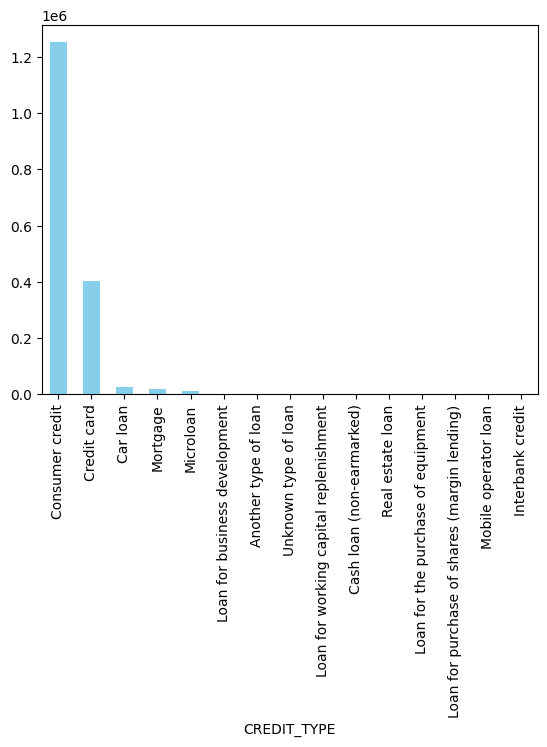

In [376]:
bureau_merged['CREDIT_TYPE'].value_counts().plot(kind="bar", color="skyblue")

- **CREDIT_ACTIVE** : We no longer need to keep this column, as the information has already been encoded as dummy variables (BUREAU_ACTIVE_*) just before.
- **CREDIT_CURRENCY** : Almost always the same value for everyone, with virtually no variation, so we do not need it.
- **CREDIT_TYPE (consumer credit, mortgage, car loan, etc.)** : A categorical but secondary column; encoding it would result in many columns for a modest gain, so we’ll deliberately choose not to keep it

We encode the important category as dummy variables (it becomes numerical, then it is aggregated), and we let `select_dtypes(include=“number”)` discard the secondary categories that we’ve chosen not to encode. It’s not a case of ‘discarding text at random’; it’s ‘we’ve already converted what matters into numbers beforehand’.

In [377]:
# Select the numeric columns to aggregate (exclude the ID keys)
bureau_numeric_cols = (bureau_merged
                       .select_dtypes(include='number')
                       .columns
                       .drop(['SK_ID_CURR', 'SK_ID_BUREAU']))

bureau_numeric_cols

Index(['DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY', '0', '1',
       '2', '3', '4', '5', 'C', 'X', 'BUREAU_ACTIVE_Active',
       'BUREAU_ACTIVE_Bad debt', 'BUREAU_ACTIVE_Closed', 'BUREAU_ACTIVE_Sold'],
      dtype='object')

In [378]:
# Summarise each numeric column with 4 functions, per client
bureau_final = (bureau_merged
                .groupby('SK_ID_CURR')[bureau_numeric_cols]
                .agg(['mean', 'max', 'min', 'sum']))

bureau_final

DAYS_CREDIT                    CREDIT_DAY_OVERDUE              \
                  mean   max   min    sum               mean max min sum   
SK_ID_CURR                                                                 
100001         -735.00   -49 -1572  -5145               0.00   0   0   0   
100002         -874.00  -103 -1437  -6992               0.00   0   0   0   
100003       -1,400.75  -606 -2586  -5603               0.00   0   0   0   
100004         -867.00  -408 -1326  -1734               0.00   0   0   0   
100005         -190.67   -62  -373   -572               0.00   0   0   0   
...                ...   ...   ...    ...                ...  ..  ..  ..   
456249       -1,667.08  -483 -2713 -21672               0.00   0   0   0   
456250         -862.00  -760 -1002  -2586               0.00   0   0   0   
456253         -867.50  -713  -919  -3470               0.00   0   0   0   
456254       -1,104.00 -1104 -1104  -1104               0.00   0   0   0   
456255       -1,089.45  -363 -2337 -11984               0.00   0   0   0   

           DAYS_CREDIT_ENDDATE            ... BUREAU_ACTIVE_Bad debt      \
                          mean       max  ...                    min sum   
SK_ID_CURR                                ...                              
100001                   82.43  1,778.00  ...                      0   0   
100002                 -349.00    780.00  ...                      0   0   
100003                 -544.50  1,216.00  ...                      0   0   
100004                 -488.50   -382.00  ...                      0   0   
100005                  439.33  1,324.00  ...                      0   0   
...                        ...       ...  ...                    ...  ..   
456249               -1,232.33  1,363.00  ...                      0   0   
456250                1,288.33  2,340.00  ...                      0   0   
456253                  280.50  1,113.00  ...                      0   0   
456254                 -859.00   -859.00  ...                      0   0   
456255                3,231.27 27,320.00  ...                      0   0   

           BUREAU_ACTIVE_Closed             BUREAU_ACTIVE_Sold              
                           mean max min sum               mean max min sum  
SK_ID_CURR                                                                  
100001                     0.57   1   0   4               0.00   0   0   0  
100002                     0.75   1   0   6               0.00   0   0   0  
100003                     0.75   1   0   3               0.00   0   0   0  
100004                     1.00   1   1   2               0.00   0   0   0  
100005                     0.33   1   0   1               0.00   0   0   0  
...                         ...  ..  ..  ..                ...  ..  ..  ..  
456249                     0.85   1   0  11               0.00   0   0   0  
456250                     0.33   1   0   1               0.00   0   0   0  
456253                     0.50   1   0   2               0.00   0   0   0  
456254                     1.00   1   1   1               0.00   0   0   0  
456255                     0.55   1   0   6               0.00   0   0   0  

[305811 rows x 96 columns]

In [379]:
# Flatten the two-level column names: ('AMT_CREDIT_SUM', 'mean') -> 'BUREAU_AMT_CREDIT_SUM_MEAN'
bureau_final.columns = ['BUREAU_' + str(col[0]) + '_' + col[1].upper() for col in bureau_final.columns]
bureau_final = bureau_final.reset_index()

bureau_final

,SK_ID_CURR,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_SUM,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MIN,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,...,BUREAU_BUREAU_ACTIVE_Bad debt_MIN,BUREAU_BUREAU_ACTIVE_Bad debt_SUM,BUREAU_BUREAU_ACTIVE_Closed_MEAN,BUREAU_BUREAU_ACTIVE_Closed_MAX,BUREAU_BUREAU_ACTIVE_Closed_MIN,BUREAU_BUREAU_ACTIVE_Closed_SUM,BUREAU_BUREAU_ACTIVE_Sold_MEAN,BUREAU_BUREAU_ACTIVE_Sold_MAX,BUREAU_BUREAU_ACTIVE_Sold_MIN,BUREAU_BUREAU_ACTIVE_Sold_SUM
0,100001,-735.00,-49,-1572,-5145,0.00,0,0,0,82.43,...,0,0,0.57,1,0,4,0.00,0,0,0
1,100002,-874.00,-103,-1437,-6992,0.00,0,0,0,-349.00,...,0,0,0.75,1,0,6,0.00,0,0,0
2,100003,"-1,400.75",-606,-2586,-5603,0.00,0,0,0,-544.50,...,0,0,0.75,1,0,3,0.00,0,0,0
3,100004,-867.00,-408,-1326,-1734,0.00,0,0,0,-488.50,...,0,0,1.00,1,1,2,0.00,0,0,0
4,100005,-190.67,-62,-373,-572,0.00,0,0,0,439.33,...,0,0,0.33,1,0,1,0.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305806,456249,"-1,667.08",-483,-2713,-21672,0.00,0,0,0,"-1,232.33",...,0,0,0.85,1,0,11,0.00,0,0,0
305807,456250,-862.00,-760,-1002,-2586,0.00,0,0,0,"1,288.33",...,0,0,0.33,1,0,1,0.00,0,0,0
305808,456253,-867.50,-713,-919,-3470,0.00,0,0,0,280.50,...,0,0,0.50,1,0,2,0.00,0,0,0
305809,456254,"-1,104.00",-1104,-1104,-1104,0.00,0,0,0,-859.00,...,0,0,1.00,1,1,1,0.00,0,0,0


In [380]:
# Number of external credits per client
bureau_final['BUREAU_NB_CREDITS'] = bureau_merged.groupby('SK_ID_CURR').size().values

bureau_final

,SK_ID_CURR,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_SUM,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MIN,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,...,BUREAU_BUREAU_ACTIVE_Bad debt_SUM,BUREAU_BUREAU_ACTIVE_Closed_MEAN,BUREAU_BUREAU_ACTIVE_Closed_MAX,BUREAU_BUREAU_ACTIVE_Closed_MIN,BUREAU_BUREAU_ACTIVE_Closed_SUM,BUREAU_BUREAU_ACTIVE_Sold_MEAN,BUREAU_BUREAU_ACTIVE_Sold_MAX,BUREAU_BUREAU_ACTIVE_Sold_MIN,BUREAU_BUREAU_ACTIVE_Sold_SUM,BUREAU_NB_CREDITS
0,100001,-735.00,-49,-1572,-5145,0.00,0,0,0,82.43,...,0,0.57,1,0,4,0.00,0,0,0,7
1,100002,-874.00,-103,-1437,-6992,0.00,0,0,0,-349.00,...,0,0.75,1,0,6,0.00,0,0,0,8
2,100003,"-1,400.75",-606,-2586,-5603,0.00,0,0,0,-544.50,...,0,0.75,1,0,3,0.00,0,0,0,4
3,100004,-867.00,-408,-1326,-1734,0.00,0,0,0,-488.50,...,0,1.00,1,1,2,0.00,0,0,0,2
4,100005,-190.67,-62,-373,-572,0.00,0,0,0,439.33,...,0,0.33,1,0,1,0.00,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305806,456249,"-1,667.08",-483,-2713,-21672,0.00,0,0,0,"-1,232.33",...,0,0.85,1,0,11,0.00,0,0,0,13
305807,456250,-862.00,-760,-1002,-2586,0.00,0,0,0,"1,288.33",...,0,0.33,1,0,1,0.00,0,0,0,3
305808,456253,-867.50,-713,-919,-3470,0.00,0,0,0,280.50,...,0,0.50,1,0,2,0.00,0,0,0,4
305809,456254,"-1,104.00",-1104,-1104,-1104,0.00,0,0,0,-859.00,...,0,1.00,1,1,1,0.00,0,0,0,1


## 2. PREVIOUS APPLICATION - POS_CASH_balance, credit_card_balance, installments_payments

### 2. 1. Aggregation on SK_ID_PREV

#### 2. 1. a) Installments Payments

In [381]:
dfs['installments_payments'].sort_values(by=['SK_ID_CURR', 'SK_ID_PREV']).head(20)

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
1478621,1369693,100001,1.00,1,"-1,709.00","-1,715.00","3,951.00","3,951.00"
2568722,1369693,100001,1.00,2,"-1,679.00","-1,715.00","3,951.00","3,951.00"
2624024,1369693,100001,2.00,4,"-1,619.00","-1,628.00","17,397.90","17,397.90"
3458712,1369693,100001,1.00,3,"-1,649.00","-1,660.00","3,951.00","3,951.00"
1761012,1851984,100001,1.00,2,"-2,916.00","-2,916.00","3,982.05","3,982.05"
3435373,1851984,100001,1.00,4,"-2,856.00","-2,856.00","3,980.93","3,980.93"
3774071,1851984,100001,1.00,3,"-2,886.00","-2,875.00","3,982.05","3,982.05"
185679,1038818,100002,1.00,16,-115.00,-133.00,"9,251.77","9,251.77"
210205,1038818,100002,1.00,8,-355.00,-375.00,"9,251.77","9,251.77"
442432,1038818,100002,2.00,19,-25.00,-49.00,"53,093.75","53,093.75"


Before any aggregation, we need to understand the columns.

AMT_INSTALMENT, AMT_PAYMENT, DAYS_INSTALMENT and DAYS_ENTRY_PAYMENT do not provide explicit information unless we manually engineer the features.

In [382]:
inst = dfs['installments_payments'].copy()

Let's create two features : 

`Payment gap`: amount due – amount paid (>0 = the customer has underpaid)
inst[“PAYMENT_DIFF”] = inst[“AMT_INSTALMENT”] - inst[“AMT_PAYMENT”]

`Delay`: actual payment date – due date (>0 = paid late)
inst[“DAYS_LATE”] = inst[“DAYS_ENTRY_PAYMENT”] - inst[“DAYS_INSTALMENT”]

In [383]:
inst['PAYMENT_DIFF'] = inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT']
inst['DAYS_LATE'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']

inst

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,PAYMENT_DIFF,DAYS_LATE
0,1054186,161674,1.00,6,"-1,180.00","-1,187.00","6,948.36","6,948.36",0.00,-7.00
1,1330831,151639,0.00,34,"-2,156.00","-2,156.00","1,716.53","1,716.53",0.00,0.00
2,2085231,193053,2.00,1,-63.00,-63.00,"25,425.00","25,425.00",0.00,0.00
3,2452527,199697,1.00,3,"-2,418.00","-2,426.00","24,350.13","24,350.13",0.00,-8.00
4,2714724,167756,1.00,2,"-1,383.00","-1,366.00","2,165.04","2,160.59",4.45,17.00
...,...,...,...,...,...,...,...,...,...,...
13605396,2186857,428057,0.00,66,"-1,624.00",NaN,67.50,NaN,NaN,NaN
13605397,1310347,414406,0.00,47,"-1,539.00",NaN,67.50,NaN,NaN,NaN
13605398,1308766,402199,0.00,43,-7.00,NaN,"43,737.43",NaN,NaN,NaN
13605399,1062206,409297,0.00,43,"-1,986.00",NaN,67.50,NaN,NaN,NaN


In [384]:
inst_agg = (inst
                .groupby('SK_ID_PREV', as_index=False)
                .agg({
                    'PAYMENT_DIFF':'max', 
                    'DAYS_LATE':'max'
                }))

inst_agg

,SK_ID_PREV,PAYMENT_DIFF,DAYS_LATE
0,1000001,0.00,-6.00
1,1000002,0.00,-5.00
2,1000003,0.00,-14.00
3,1000004,0.00,-10.00
4,1000005,"14,710.81",3.00
...,...,...,...
997747,2843495,0.00,1.00
997748,2843496,"4,664.70",0.00
997749,2843497,0.00,0.00
997750,2843498,0.00,0.00


#### 2. 1. b) POS_CASH

In [385]:
dfs['POS_CASH'].sort_values(by=['SK_ID_CURR', 'SK_ID_PREV']).head(20)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
2197888,1369693,100001,-53,4.00,0.00,Completed,0,0
4704415,1369693,100001,-54,4.00,1.00,Active,0,0
7167007,1369693,100001,-57,4.00,4.00,Active,0,0
7823681,1369693,100001,-55,4.00,2.00,Active,0,0
8789081,1369693,100001,-56,4.00,3.00,Active,0,0
1261679,1851984,100001,-96,4.00,2.00,Active,0,0
1891462,1851984,100001,-95,4.00,1.00,Active,7,7
4928574,1851984,100001,-93,4.00,0.00,Completed,0,0
8531326,1851984,100001,-94,4.00,0.00,Active,0,0
513222,1038818,100002,-13,24.00,18.00,Active,0,0


In [386]:
dfs['POS_CASH']['NAME_CONTRACT_STATUS'].nunique()

9

In [387]:
dfs['POS_CASH']['NAME_CONTRACT_STATUS'].unique()

array(['Active', 'Completed', 'Signed', 'Approved',
       'Returned to the store', 'Demand', 'Canceled', 'XNA',
       'Amortized debt'], dtype=object)

In [388]:
pd.set_option('display.float_format', '{:,.2f}'.format)

dfs['POS_CASH'][['CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE']].describe()

,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE
count,"9,975,287.00","9,975,271.00"
mean,17.09,10.48
std,12.00,11.11
min,1.00,0.00
25%,10.00,3.00
50%,12.00,7.00
75%,24.00,14.00
max,92.00,85.00


In [389]:
# A. LET’S CONVERT THE VALUES OF ‘NAME_CONTRACT_STATUS’ INTO DUMMY VARIABLES
# A. 1. Convert the dummy variables to binary 0/1
status_dummies = pd.get_dummies(dfs['POS_CASH']['NAME_CONTRACT_STATUS']
                                , prefix='POS_STATUS')
status_dummies

,POS_STATUS_Active,POS_STATUS_Amortized debt,POS_STATUS_Approved,POS_STATUS_Canceled,POS_STATUS_Completed,POS_STATUS_Demand,POS_STATUS_Returned to the store,POS_STATUS_Signed,POS_STATUS_XNA
0,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
10001353,True,False,False,False,False,False,False,False,False
10001354,True,False,False,False,False,False,False,False,False
10001355,True,False,False,False,False,False,False,False,False
10001356,True,False,False,False,False,False,False,False,False


In [390]:
# A. 2. Add the dummy variables “status_dummies” to “POS_CASH”
pos = pd.concat([dfs['POS_CASH'], status_dummies], axis=1)
pos

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF,POS_STATUS_Active,POS_STATUS_Amortized debt,POS_STATUS_Approved,POS_STATUS_Canceled,POS_STATUS_Completed,POS_STATUS_Demand,POS_STATUS_Returned to the store,POS_STATUS_Signed,POS_STATUS_XNA
0,1803195,182943,-31,48.00,45.00,Active,0,0,True,False,False,False,False,False,False,False,False
1,1715348,367990,-33,36.00,35.00,Active,0,0,True,False,False,False,False,False,False,False,False
2,1784872,397406,-32,12.00,9.00,Active,0,0,True,False,False,False,False,False,False,False,False
3,1903291,269225,-35,48.00,42.00,Active,0,0,True,False,False,False,False,False,False,False,False
4,2341044,334279,-35,36.00,35.00,Active,0,0,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10001353,2448283,226558,-20,6.00,0.00,Active,843,0,True,False,False,False,False,False,False,False,False
10001354,1717234,141565,-19,12.00,0.00,Active,602,0,True,False,False,False,False,False,False,False,False
10001355,1283126,315695,-21,10.00,0.00,Active,609,0,True,False,False,False,False,False,False,False,False
10001356,1082516,450255,-22,12.00,0.00,Active,614,0,True,False,False,False,False,False,False,False,False


In [391]:
# B. AGGREGATE
# B. 1. Prepare the aggregation dictionary
agg_dict = {
    'MONTHS_BALANCE':'count', 
    'CNT_INSTALMENT':'mean', 
    'CNT_INSTALMENT_FUTURE':'mean',
    'SK_DPD':'max',
    'SK_DPD_DEF':'max'
}

# B. 2. Create a ‘for’ loop to add each dummy variable to the agg_dict
for col in status_dummies.columns:
    agg_dict[col] = 'sum'

agg_dict

{'MONTHS_BALANCE': 'count',
 'CNT_INSTALMENT': 'mean',
 'CNT_INSTALMENT_FUTURE': 'mean',
 'SK_DPD': 'max',
 'SK_DPD_DEF': 'max',
 'POS_STATUS_Active': 'sum',
 'POS_STATUS_Amortized debt': 'sum',
 'POS_STATUS_Approved': 'sum',
 'POS_STATUS_Canceled': 'sum',
 'POS_STATUS_Completed': 'sum',
 'POS_STATUS_Demand': 'sum',
 'POS_STATUS_Returned to the store': 'sum',
 'POS_STATUS_Signed': 'sum',
 'POS_STATUS_XNA': 'sum'}

In [392]:
# B. 3. Final aggregation
pos_agg = (pos
           .groupby('SK_ID_PREV', as_index=False)
           .agg(agg_dict))

pos_agg

,SK_ID_PREV,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,SK_DPD,SK_DPD_DEF,POS_STATUS_Active,POS_STATUS_Amortized debt,POS_STATUS_Approved,POS_STATUS_Canceled,POS_STATUS_Completed,POS_STATUS_Demand,POS_STATUS_Returned to the store,POS_STATUS_Signed,POS_STATUS_XNA
0,1000001,3,8.67,7.67,0,0,2,0,0,0,1,0,0,0,0
1,1000002,5,5.20,2.00,0,0,4,0,0,0,1,0,0,0,0
2,1000003,4,12.00,10.50,0,0,4,0,0,0,0,0,0,0,0
3,1000004,8,9.62,6.12,0,0,7,0,0,0,1,0,0,0,0
4,1000005,11,10.00,5.00,0,0,10,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936320,2843494,3,32.67,31.67,0,0,2,0,0,0,1,0,0,0,0
936321,2843495,8,53.38,49.88,0,0,7,0,0,0,1,0,0,0,0
936322,2843497,21,24.00,14.00,0,0,21,0,0,0,0,0,0,0,0
936323,2843498,7,27.43,24.29,0,0,6,0,0,0,1,0,0,0,0


#### 2. 1. c) Credit Card Balance

In [393]:
dfs['credit_card_balance'].sort_values(by=['SK_ID_CURR', 'SK_ID_PREV']).head(20)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
520387,1489396,100006,-2,0.00,270000,NaN,0.00,NaN,NaN,0.00,...,0.00,0.00,NaN,0,NaN,NaN,0.00,Active,0,0
584804,1489396,100006,-1,0.00,270000,NaN,0.00,NaN,NaN,0.00,...,0.00,0.00,NaN,0,NaN,NaN,0.00,Active,0,0
655566,1489396,100006,-5,0.00,270000,NaN,0.00,NaN,NaN,0.00,...,0.00,0.00,NaN,0,NaN,NaN,0.00,Active,0,0
1347528,1489396,100006,-3,0.00,270000,NaN,0.00,NaN,NaN,0.00,...,0.00,0.00,NaN,0,NaN,NaN,0.00,Active,0,0
1399895,1489396,100006,-4,0.00,270000,NaN,0.00,NaN,NaN,0.00,...,0.00,0.00,NaN,0,NaN,NaN,0.00,Active,0,0
1636141,1489396,100006,-6,0.00,270000,NaN,0.00,NaN,NaN,0.00,...,0.00,0.00,NaN,0,NaN,NaN,0.00,Active,0,0
35799,1843384,100011,-48,"75,109.95",180000,0.00,0.00,0.00,0.00,"9,000.00",...,"75,109.95","75,109.95",0.00,0,0.00,0.00,27.00,Active,0,0
51047,1843384,100011,-4,0.00,90000,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0,0.00,0.00,33.00,Active,0,0
131693,1843384,100011,-6,0.00,90000,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0,0.00,0.00,33.00,Active,0,0
153898,1843384,100011,-54,"104,130.63",180000,0.00,0.00,0.00,0.00,"9,000.00",...,"104,130.63","104,130.63",0.00,0,0.00,0.00,21.00,Active,0,0


In [394]:
# A. LET’S CONVERT THE VALUES OF ‘NAME_CONTRACT_STATUS’ INTO DUMMY VARIABLES
# A. 1. Convert the dummy variables to binary 0/1
status_dummies = pd.get_dummies(dfs['credit_card_balance']['NAME_CONTRACT_STATUS']
                                , prefix='CC_STATUS')
status_dummies

,CC_STATUS_Active,CC_STATUS_Approved,CC_STATUS_Completed,CC_STATUS_Demand,CC_STATUS_Refused,CC_STATUS_Sent proposal,CC_STATUS_Signed
0,True,False,False,False,False,False,False
1,True,False,False,False,False,False,False
2,True,False,False,False,False,False,False
3,True,False,False,False,False,False,False
4,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...
3840307,True,False,False,False,False,False,False
3840308,True,False,False,False,False,False,False
3840309,True,False,False,False,False,False,False
3840310,True,False,False,False,False,False,False


In [395]:
# A. 2. Add the dummy variables “status_dummies” to “credit_card_balance”
cc = pd.concat([dfs['credit_card_balance'], status_dummies], axis=1)
cc

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF,CC_STATUS_Active,CC_STATUS_Approved,CC_STATUS_Completed,CC_STATUS_Demand,CC_STATUS_Refused,CC_STATUS_Sent proposal,CC_STATUS_Signed
0,2562384,378907,-6,56.97,135000,0.00,877.50,0.00,877.50,"1,700.33",...,Active,0,0,True,False,False,False,False,False,False
1,2582071,363914,-1,"63,975.56",45000,"2,250.00","2,250.00",0.00,0.00,"2,250.00",...,Active,0,0,True,False,False,False,False,False,False
2,1740877,371185,-7,"31,815.22",450000,0.00,0.00,0.00,0.00,"2,250.00",...,Active,0,0,True,False,False,False,False,False,False
3,1389973,337855,-4,"236,572.11",225000,"2,250.00","2,250.00",0.00,0.00,"11,795.76",...,Active,0,0,True,False,False,False,False,False,False
4,1891521,126868,-1,"453,919.46",450000,0.00,"11,547.00",0.00,"11,547.00","22,924.89",...,Active,0,0,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3840307,1036507,328243,-9,0.00,45000,NaN,0.00,NaN,NaN,0.00,...,Active,0,0,True,False,False,False,False,False,False
3840308,1714892,347207,-9,0.00,45000,0.00,0.00,0.00,0.00,0.00,...,Active,0,0,True,False,False,False,False,False,False
3840309,1302323,215757,-9,"275,784.97",585000,"270,000.00","270,000.00",0.00,0.00,"2,250.00",...,Active,0,0,True,False,False,False,False,False,False
3840310,1624872,430337,-10,0.00,450000,NaN,0.00,NaN,NaN,0.00,...,Active,0,0,True,False,False,False,False,False,False


In [396]:
# B. AGGREGATE
# B. 1. Prepare the aggregation dictionary
agg_dict = {
    'AMT_BALANCE': 'mean',
    'AMT_CREDIT_LIMIT_ACTUAL': 'mean',
    'AMT_DRAWINGS_CURRENT': 'mean',
    'AMT_PAYMENT_CURRENT': 'mean',
    'SK_DPD': 'max',
    'SK_DPD_DEF': 'max'
}

# B. 2. Create a ‘for’ loop to add each dummy variable to the agg_dict
for col in status_dummies.columns:
    agg_dict[col] = 'sum'

agg_dict

{'AMT_BALANCE': 'mean',
 'AMT_CREDIT_LIMIT_ACTUAL': 'mean',
 'AMT_DRAWINGS_CURRENT': 'mean',
 'AMT_PAYMENT_CURRENT': 'mean',
 'SK_DPD': 'max',
 'SK_DPD_DEF': 'max',
 'CC_STATUS_Active': 'sum',
 'CC_STATUS_Approved': 'sum',
 'CC_STATUS_Completed': 'sum',
 'CC_STATUS_Demand': 'sum',
 'CC_STATUS_Refused': 'sum',
 'CC_STATUS_Sent proposal': 'sum',
 'CC_STATUS_Signed': 'sum'}

In [397]:
# B. 3. Final aggregation
cc_agg = (cc
          .groupby('SK_ID_PREV', as_index=False)
          .agg(
              agg_dict
              ))

cc_agg

,SK_ID_PREV,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_CURRENT,AMT_PAYMENT_CURRENT,SK_DPD,SK_DPD_DEF,CC_STATUS_Active,CC_STATUS_Approved,CC_STATUS_Completed,CC_STATUS_Demand,CC_STATUS_Refused,CC_STATUS_Sent proposal,CC_STATUS_Signed
0,1000018,"74,946.29","81,000.00","29,479.00","5,541.75",0,0,5,0,0,0,0,0,0
1,1000030,"55,991.06","81,562.50","17,257.44","6,188.63",0,0,8,0,0,0,0,0,0
2,1000031,"52,394.44","149,625.00","28,959.62","29,543.26",0,0,16,0,0,0,0,0,0
3,1000035,0.00,"225,000.00",0.00,NaN,0,0,5,0,0,0,0,0,0
4,1000077,0.00,"94,090.91",0.00,NaN,0,0,11,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104302,2843476,"37,937.81","161,526.32",947.37,"3,467.42",243,32,95,0,0,0,0,0,0
104303,2843477,"1,663.08","15,882.35",688.24,955.27,0,0,85,0,0,0,0,0,0
104304,2843478,"5,111.40","21,000.00","1,000.00","1,355.80",0,0,90,0,0,0,0,0,0
104305,2843493,"59,139.93","153,000.00","7,217.16","5,625.93",0,0,15,0,0,0,0,0,0


### 2. 2. Merge the POS_CASH, credit card and installments aggregations into previous_application (one row per previous credit, SK_ID_PREV)

In [398]:
dfs['prev_application']

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,"1,730.43","17,145.00","17,145.00",0.00,"17,145.00",SATURDAY,15,...,Connectivity,12.00,middle,POS mobile with interest,"365,243.00",-42.00,300.00,-42.00,-37.00,0.00
1,2802425,108129,Cash loans,"25,188.62","607,500.00","679,671.00",NaN,"607,500.00",THURSDAY,11,...,XNA,36.00,low_action,Cash X-Sell: low,"365,243.00",-134.00,916.00,"365,243.00","365,243.00",1.00
2,2523466,122040,Cash loans,"15,060.74","112,500.00","136,444.50",NaN,"112,500.00",TUESDAY,11,...,XNA,12.00,high,Cash X-Sell: high,"365,243.00",-271.00,59.00,"365,243.00","365,243.00",1.00
3,2819243,176158,Cash loans,"47,041.33","450,000.00","470,790.00",NaN,"450,000.00",MONDAY,7,...,XNA,12.00,middle,Cash X-Sell: middle,"365,243.00",-482.00,-152.00,-182.00,-177.00,1.00
4,1784265,202054,Cash loans,"31,924.40","337,500.00","404,055.00",NaN,"337,500.00",THURSDAY,9,...,XNA,24.00,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,"14,704.29","267,295.50","311,400.00",0.00,"267,295.50",WEDNESDAY,12,...,Furniture,30.00,low_normal,POS industry with interest,"365,243.00",-508.00,362.00,-358.00,-351.00,0.00
1670210,2357031,334635,Consumer loans,"6,622.02","87,750.00","64,291.50","29,250.00","87,750.00",TUESDAY,15,...,Furniture,12.00,middle,POS industry with interest,"365,243.00","-1,604.00","-1,274.00","-1,304.00","-1,297.00",0.00
1670211,2659632,249544,Consumer loans,"11,520.85","105,237.00","102,523.50","10,525.50","105,237.00",MONDAY,12,...,Consumer electronics,10.00,low_normal,POS household with interest,"365,243.00","-1,457.00","-1,187.00","-1,187.00","-1,181.00",0.00
1670212,2785582,400317,Cash loans,"18,821.52","180,000.00","191,880.00",NaN,"180,000.00",WEDNESDAY,9,...,XNA,12.00,low_normal,Cash X-Sell: low,"365,243.00","-1,155.00",-825.00,-825.00,-817.00,1.00


In [399]:
# Verify 'SK_ID_PREV' is an aggregated version and that it can be used as an id key
print(
    dfs['prev_application'].shape[0],
    dfs['prev_application']['SK_ID_PREV'].nunique()
    )

1670214 1670214


In [400]:
# Check the values in 'NAME_CONTRACT_STATUS'
dfs['prev_application']['NAME_CONTRACT_STATUS'].unique()

array(['Approved', 'Refused', 'Canceled', 'Unused offer'], dtype=object)

In [401]:
# Merge into dfs['prev_application'] on 'SK_ID_PREV'
prev_merged = (dfs['prev_application']
               .merge(pos_agg, on='SK_ID_PREV', how='left')
               .merge(cc_agg, on='SK_ID_PREV', how='left', suffixes=('_POS', '_CC')) # _POS for SK_DPD_POS from pos_agg, and _CC for SK_DPD_CC from cc_agg 
               .merge(inst_agg, on='SK_ID_PREV', how='left')
               )

In [402]:
prev_merged.sort_values(by=['SK_ID_CURR', 'SK_ID_PREV']).head(20)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,SK_DPD_DEF_CC,CC_STATUS_Active,CC_STATUS_Approved,CC_STATUS_Completed,CC_STATUS_Demand,CC_STATUS_Refused,CC_STATUS_Sent proposal,CC_STATUS_Signed,PAYMENT_DIFF,DAYS_LATE
201668,1369693,100001,Consumer loans,"3,951.00","24,835.50","23,787.00","2,520.00","24,835.50",FRIDAY,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-6.00
892077,1038818,100002,Consumer loans,"9,251.77","179,055.00","179,055.00",0.00,"179,055.00",SATURDAY,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-12.00
575941,1810518,100003,Cash loans,"98,356.99","900,000.00","1,035,882.00",NaN,"900,000.00",FRIDAY,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-3.00
1223745,2396755,100003,Consumer loans,"6,737.31","68,809.50","68,053.50","6,885.00","68,809.50",SATURDAY,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-1.00
1021650,2636178,100003,Consumer loans,"64,567.67","337,500.00","348,637.50",0.00,"337,500.00",SUNDAY,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-9.00
935548,1564014,100004,Consumer loans,"5,357.25","24,282.00","20,106.00","4,860.00","24,282.00",FRIDAY,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-3.00
1259112,1857999,100005,Cash loans,NaN,0.00,0.00,NaN,NaN,FRIDAY,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1378978,2495675,100005,Consumer loans,"4,813.20","44,617.50","40,153.50","4,464.00","44,617.50",THURSDAY,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,1.00
1131133,1020698,100006,Cash loans,"39,954.51","454,500.00","481,495.50",NaN,"454,500.00",SATURDAY,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1232752,1243599,100006,Cash loans,NaN,0.00,0.00,NaN,NaN,THURSDAY,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. 3. Merge into prev_final on 'SK_ID_CURR'

In [403]:
prev_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 66 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   SK_ID_PREV                        1670214 non-null  int64  
 1   SK_ID_CURR                        1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE                1670214 non-null  object 
 3   AMT_ANNUITY                       1297979 non-null  float64
 4   AMT_APPLICATION                   1670214 non-null  float64
 5   AMT_CREDIT                        1670213 non-null  float64
 6   AMT_DOWN_PAYMENT                  774370 non-null   float64
 7   AMT_GOODS_PRICE                   1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START        1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START           1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT       1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY            167

In [404]:
# Encode the results of previous queries (Approved / Rejected / ...) as 0/1
prev_merged = pd.concat(
    [prev_merged,
     pd.get_dummies(prev_merged['NAME_CONTRACT_STATUS'], prefix='PREV_DECISION', dtype=int)],
    axis=1
)
prev_merged

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,CC_STATUS_Demand,CC_STATUS_Refused,CC_STATUS_Sent proposal,CC_STATUS_Signed,PAYMENT_DIFF,DAYS_LATE,PREV_DECISION_Approved,PREV_DECISION_Canceled,PREV_DECISION_Refused,PREV_DECISION_Unused offer
0,2030495,271877,Consumer loans,"1,730.43","17,145.00","17,145.00",0.00,"17,145.00",SATURDAY,15,...,NaN,NaN,NaN,NaN,0.00,0.00,1,0,0,0
1,2802425,108129,Cash loans,"25,188.62","607,500.00","679,671.00",NaN,"607,500.00",THURSDAY,11,...,NaN,NaN,NaN,NaN,0.00,-7.00,1,0,0,0
2,2523466,122040,Cash loans,"15,060.74","112,500.00","136,444.50",NaN,"112,500.00",TUESDAY,11,...,NaN,NaN,NaN,NaN,0.00,1.00,1,0,0,0
3,2819243,176158,Cash loans,"47,041.33","450,000.00","470,790.00",NaN,"450,000.00",MONDAY,7,...,NaN,NaN,NaN,NaN,0.00,0.00,1,0,0,0
4,1784265,202054,Cash loans,"31,924.40","337,500.00","404,055.00",NaN,"337,500.00",THURSDAY,9,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,"14,704.29","267,295.50","311,400.00",0.00,"267,295.50",WEDNESDAY,12,...,NaN,NaN,NaN,NaN,0.00,-1.00,1,0,0,0
1670210,2357031,334635,Consumer loans,"6,622.02","87,750.00","64,291.50","29,250.00","87,750.00",TUESDAY,15,...,NaN,NaN,NaN,NaN,0.00,-27.00,1,0,0,0
1670211,2659632,249544,Consumer loans,"11,520.85","105,237.00","102,523.50","10,525.50","105,237.00",MONDAY,12,...,NaN,NaN,NaN,NaN,0.00,4.00,1,0,0,0
1670212,2785582,400317,Cash loans,"18,821.52","180,000.00","191,880.00",NaN,"180,000.00",WEDNESDAY,9,...,NaN,NaN,NaN,NaN,0.00,-3.00,1,0,0,0


In [405]:
# Numeric columns to be aggregated (excluding IDs)
numeric_cols = (prev_merged
                .select_dtypes(include='number')
                .columns
                .drop(['SK_ID_CURR', 'SK_ID_PREV']))
numeric_cols

Index(['AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT',
       'AMT_GOODS_PRICE', 'HOUR_APPR_PROCESS_START', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'DAYS_DECISION', 'SELLERPLACE_AREA',
       'CNT_PAYMENT', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE',
       'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION',
       'NFLAG_INSURED_ON_APPROVAL', 'MONTHS_BALANCE', 'CNT_INSTALMENT',
       'CNT_INSTALMENT_FUTURE', 'SK_DPD_POS', 'SK_DPD_DEF_POS',
       'POS_STATUS_Active', 'POS_STATUS_Amortized debt', 'POS_STATUS_Approved',
       'POS_STATUS_Canceled', 'POS_STATUS_Completed', 'POS_STATUS_Demand',
       'POS_STATUS_Returned to the store', 'POS_STATUS_Signed',
       'POS_STATUS_XNA', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL',
       'AMT_DRAWINGS_CURRENT', 'AMT_PAYMENT_CURRENT', 'SK_DPD_CC',
       'SK_DPD_DEF_CC', 'CC_STATUS_Active', 'CC_STATUS_Approved',
       'CC_STATUS_Completed', '

In [406]:
# Summarise each numerical column using 4 functions in one go
prev_final = (prev_merged
              .groupby('SK_ID_CURR')[numeric_cols]
              .agg(['mean', 'max', 'min', 'sum']))
prev_final

AMT_ANNUITY                                AMT_APPLICATION  \
                  mean       max       min        sum            mean   
SK_ID_CURR                                                              
100001        3,951.00  3,951.00  3,951.00   3,951.00       24,835.50   
100002        9,251.77  9,251.77  9,251.77   9,251.77      179,055.00   
100003       56,553.99 98,356.99  6,737.31 169,661.97      435,436.50   
100004        5,357.25  5,357.25  5,357.25   5,357.25       24,282.00   
100005        4,813.20  4,813.20  4,813.20   4,813.20       22,308.75   
...                ...       ...       ...        ...             ...   
456251        6,605.91  6,605.91  6,605.91   6,605.91       40,455.00   
456252       10,074.47 10,074.47 10,074.47  10,074.47       57,595.50   
456253        4,770.40  5,567.72  3,973.09   9,540.81       24,162.75   
456254       10,681.13 19,065.83  2,296.44  21,362.26      121,317.75   
456255       20,775.39 54,022.14  2,250.00 166,203.14      362,770.88   

                                                AMT_CREDIT               ...  \
                    max        min          sum       mean          max  ...   
SK_ID_CURR                                                               ...   
100001        24,835.50  24,835.50    24,835.50  23,787.00    23,787.00  ...   
100002       179,055.00 179,055.00   179,055.00 179,055.00   179,055.00  ...   
100003       900,000.00  68,809.50 1,306,309.50 484,191.00 1,035,882.00  ...   
100004        24,282.00  24,282.00    24,282.00  20,106.00    20,106.00  ...   
100005        44,617.50       0.00    44,617.50  20,076.75    40,153.50  ...   
...                 ...        ...          ...        ...          ...  ...   
456251        40,455.00  40,455.00    40,455.00  40,455.00    40,455.00  ...   
456252        57,595.50  57,595.50    57,595.50  56,821.50    56,821.50  ...   
456253        28,912.50  19,413.00    48,325.50  20,625.75    27,306.00  ...   
456254       223,789.50  18,846.00   242,635.50 134,439.75   247,423.50  ...   
456255     1,170,000.00  45,000.00 2,902,167.00 424,431.00 1,271,929.50  ...   

           PREV_DECISION_Canceled     PREV_DECISION_Refused              \
                              min sum                  mean max min sum   
SK_ID_CURR                                                                
100001                          0   0                  0.00   0   0   0   
100002                          0   0                  0.00   0   0   0   
100003                          0   0                  0.00   0   0   0   
100004                          0   0                  0.00   0   0   0   
100005                          0   1                  0.00   0   0   0   
...                           ...  ..                   ...  ..  ..  ..   
456251                          0   0                  0.00   0   0   0   
456252                          0   0                  0.00   0   0   0   
456253                          0   0                  0.00   0   0   0   
456254                          0   0                  0.00   0   0   0   
456255                          0   0                  0.25   1   0   2   

           PREV_DECISION_Unused offer              
                                 mean max min sum  
SK_ID_CURR                                         
100001                           0.00   0   0   0  
100002                           0.00   0   0   0  
100003                           0.00   0   0   0  
100004                           0.00   0   0   0  
100005                           0.00   0   0   0  
...                               ...  ..  ..  ..  
456251                           0.00   0   0   0  
456252                           0.00   0   0   0  
456253                           0.00   0   0   0  
456254                           0.00   0   0   0  
456255                           0.00   0   0   0  

[338857 rows x 208 columns]

In [407]:
with pd.option_context('display.max_columns', None):
    display(prev_final)

AMT_ANNUITY                                AMT_APPLICATION  \
                  mean       max       min        sum            mean   
SK_ID_CURR                                                              
100001        3,951.00  3,951.00  3,951.00   3,951.00       24,835.50   
100002        9,251.77  9,251.77  9,251.77   9,251.77      179,055.00   
100003       56,553.99 98,356.99  6,737.31 169,661.97      435,436.50   
100004        5,357.25  5,357.25  5,357.25   5,357.25       24,282.00   
100005        4,813.20  4,813.20  4,813.20   4,813.20       22,308.75   
...                ...       ...       ...        ...             ...   
456251        6,605.91  6,605.91  6,605.91   6,605.91       40,455.00   
456252       10,074.47 10,074.47 10,074.47  10,074.47       57,595.50   
456253        4,770.40  5,567.72  3,973.09   9,540.81       24,162.75   
456254       10,681.13 19,065.83  2,296.44  21,362.26      121,317.75   
456255       20,775.39 54,022.14  2,250.00 166,203.14      362,770.88   

                                                AMT_CREDIT               \
                    max        min          sum       mean          max   
SK_ID_CURR                                                                
100001        24,835.50  24,835.50    24,835.50  23,787.00    23,787.00   
100002       179,055.00 179,055.00   179,055.00 179,055.00   179,055.00   
100003       900,000.00  68,809.50 1,306,309.50 484,191.00 1,035,882.00   
100004        24,282.00  24,282.00    24,282.00  20,106.00    20,106.00   
100005        44,617.50       0.00    44,617.50  20,076.75    40,153.50   
...                 ...        ...          ...        ...          ...   
456251        40,455.00  40,455.00    40,455.00  40,455.00    40,455.00   
456252        57,595.50  57,595.50    57,595.50  56,821.50    56,821.50   
456253        28,912.50  19,413.00    48,325.50  20,625.75    27,306.00   
456254       223,789.50  18,846.00   242,635.50 134,439.75   247,423.50   
456255     1,170,000.00  45,000.00 2,902,167.00 424,431.00 1,271,929.50   

                                   AMT_DOWN_PAYMENT                    \
                  min          sum             mean      max      min   
SK_ID_CURR                                                              
100001      23,787.00    23,787.00         2,520.00 2,520.00 2,520.00   
100002     179,055.00   179,055.00             0.00     0.00     0.00   
100003      68,053.50 1,452,573.00         3,442.50 6,885.00     0.00   
100004      20,106.00    20,106.00         4,860.00 4,860.00 4,860.00   
100005           0.00    40,153.50         4,464.00 4,464.00 4,464.00   
...               ...          ...              ...      ...      ...   
456251      40,455.00    40,455.00             0.00     0.00     0.00   
456252      56,821.50    56,821.50         3,456.00 3,456.00 3,456.00   
456253      13,945.50    41,251.50         4,403.25 5,913.00 2,893.50   
456254      21,456.00   268,879.50             0.00     0.00     0.00   
456255      45,000.00 3,395,448.00         4,941.00 9,000.00     0.00   

                     AMT_GOODS_PRICE                                       \
                 sum            mean          max        min          sum   
SK_ID_CURR                                                                  
100001      2,520.00       24,835.50    24,835.50  24,835.50    24,835.50   
100002          0.00      179,055.00   179,055.00 179,055.00   179,055.00   
100003      6,885.00      435,436.50   900,000.00  68,809.50 1,306,309.50   
100004      4,860.00       24,282.00    24,282.00  24,282.00    24,282.00   
100005      4,464.00       44,617.50    44,617.50  44,617.50    44,617.50   
...              ...             ...          ...        ...          ...   
456251          0.00       40,455.00    40,455.00  40,455.00    40,455.00   
456252      3,456.00       57,595.50    57,595.50  57,595.50    57,595.50   
456253      8,806.50       24,162.75    28,912.50  19,413.00    48,

In [408]:
# Flatten column names:(“AMT_CREDIT”, “mean”) → 'PREV_AMT_CREDIT_MEAN'
prev_final.columns = (['PREV_' + col[0] + '_' + col[1].upper() #  'PREV_' + 'AMT_CREDIT' + '_' + 'MEAN'
                       for col in prev_final.columns])

prev_final = prev_final.reset_index()
prev_final

,SK_ID_CURR,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,PREV_AMT_ANNUITY_SUM,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_APPLICATION_MIN,PREV_AMT_APPLICATION_SUM,PREV_AMT_CREDIT_MEAN,...,PREV_PREV_DECISION_Canceled_MIN,PREV_PREV_DECISION_Canceled_SUM,PREV_PREV_DECISION_Refused_MEAN,PREV_PREV_DECISION_Refused_MAX,PREV_PREV_DECISION_Refused_MIN,PREV_PREV_DECISION_Refused_SUM,PREV_PREV_DECISION_Unused offer_MEAN,PREV_PREV_DECISION_Unused offer_MAX,PREV_PREV_DECISION_Unused offer_MIN,PREV_PREV_DECISION_Unused offer_SUM
0,100001,"3,951.00","3,951.00","3,951.00","3,951.00","24,835.50","24,835.50","24,835.50","24,835.50","23,787.00",...,0,0,0.00,0,0,0,0.00,0,0,0
1,100002,"9,251.77","9,251.77","9,251.77","9,251.77","179,055.00","179,055.00","179,055.00","179,055.00","179,055.00",...,0,0,0.00,0,0,0,0.00,0,0,0
2,100003,"56,553.99","98,356.99","6,737.31","169,661.97","435,436.50","900,000.00","68,809.50","1,306,309.50","484,191.00",...,0,0,0.00,0,0,0,0.00,0,0,0
3,100004,"5,357.25","5,357.25","5,357.25","5,357.25","24,282.00","24,282.00","24,282.00","24,282.00","20,106.00",...,0,0,0.00,0,0,0,0.00,0,0,0
4,100005,"4,813.20","4,813.20","4,813.20","4,813.20","22,308.75","44,617.50",0.00,"44,617.50","20,076.75",...,0,1,0.00,0,0,0,0.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338852,456251,"6,605.91","6,605.91","6,605.91","6,605.91","40,455.00","40,455.00","40,455.00","40,455.00","40,455.00",...,0,0,0.00,0,0,0,0.00,0,0,0
338853,456252,"10,074.47","10,074.47","10,074.47","10,074.47","57,595.50","57,595.50","57,595.50","57,595.50","56,821.50",...,0,0,0.00,0,0,0,0.00,0,0,0
338854,456253,"4,770.40","5,567.72","3,973.09","9,540.81","24,162.75","28,912.50","19,413.00","48,325.50","20,625.75",...,0,0,0.00,0,0,0,0.00,0,0,0
338855,456254,"10,681.13","19,065.83","2,296.44","21,362.26","121,317.75","223,789.50","18,846.00","242,635.50","134,439.75",...,0,0,0.00,0,0,0,0.00,0,0,0


In [409]:
# Add up the number of previous credits per customer
prev_final['PREV_NB_CREDITS'] = (prev_merged
                                 .groupby('SK_ID_CURR')
                                 .size()
                                 .values)

prev_final

,SK_ID_CURR,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,PREV_AMT_ANNUITY_SUM,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_APPLICATION_MIN,PREV_AMT_APPLICATION_SUM,PREV_AMT_CREDIT_MEAN,...,PREV_PREV_DECISION_Canceled_SUM,PREV_PREV_DECISION_Refused_MEAN,PREV_PREV_DECISION_Refused_MAX,PREV_PREV_DECISION_Refused_MIN,PREV_PREV_DECISION_Refused_SUM,PREV_PREV_DECISION_Unused offer_MEAN,PREV_PREV_DECISION_Unused offer_MAX,PREV_PREV_DECISION_Unused offer_MIN,PREV_PREV_DECISION_Unused offer_SUM,PREV_NB_CREDITS
0,100001,"3,951.00","3,951.00","3,951.00","3,951.00","24,835.50","24,835.50","24,835.50","24,835.50","23,787.00",...,0,0.00,0,0,0,0.00,0,0,0,1
1,100002,"9,251.77","9,251.77","9,251.77","9,251.77","179,055.00","179,055.00","179,055.00","179,055.00","179,055.00",...,0,0.00,0,0,0,0.00,0,0,0,1
2,100003,"56,553.99","98,356.99","6,737.31","169,661.97","435,436.50","900,000.00","68,809.50","1,306,309.50","484,191.00",...,0,0.00,0,0,0,0.00,0,0,0,3
3,100004,"5,357.25","5,357.25","5,357.25","5,357.25","24,282.00","24,282.00","24,282.00","24,282.00","20,106.00",...,0,0.00,0,0,0,0.00,0,0,0,1
4,100005,"4,813.20","4,813.20","4,813.20","4,813.20","22,308.75","44,617.50",0.00,"44,617.50","20,076.75",...,1,0.00,0,0,0,0.00,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338852,456251,"6,605.91","6,605.91","6,605.91","6,605.91","40,455.00","40,455.00","40,455.00","40,455.00","40,455.00",...,0,0.00,0,0,0,0.00,0,0,0,1
338853,456252,"10,074.47","10,074.47","10,074.47","10,074.47","57,595.50","57,595.50","57,595.50","57,595.50","56,821.50",...,0,0.00,0,0,0,0.00,0,0,0,1
338854,456253,"4,770.40","5,567.72","3,973.09","9,540.81","24,162.75","28,912.50","19,413.00","48,325.50","20,625.75",...,0,0.00,0,0,0,0.00,0,0,0,2
338855,456254,"10,681.13","19,065.83","2,296.44","21,362.26","121,317.75","223,789.50","18,846.00","242,635.50","134,439.75",...,0,0.00,0,0,0,0.00,0,0,0,2


## 3. FINAL MERGE ON SK_ID_CURR INTO APPLICATION_TRAIN / APPLICATION_TEST

In [410]:
# Merge the two client-level tables (bureau_final, prev_final)
# into application_train and application_test

df_train_final = dfs['application_train'].merge(bureau_final, on='SK_ID_CURR', how='left')
df_train_final = df_train_final.merge(prev_final, on='SK_ID_CURR', how='left')
df_train_final

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PREV_PREV_DECISION_Canceled_SUM,PREV_PREV_DECISION_Refused_MEAN,PREV_PREV_DECISION_Refused_MAX,PREV_PREV_DECISION_Refused_MIN,PREV_PREV_DECISION_Refused_SUM,PREV_PREV_DECISION_Unused offer_MEAN,PREV_PREV_DECISION_Unused offer_MAX,PREV_PREV_DECISION_Unused offer_MIN,PREV_PREV_DECISION_Unused offer_SUM,PREV_NB_CREDITS
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50",...,3.00,0.11,1.00,0.00,1.00,0.00,0.00,0.00,0.00,9.00
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,"157,500.00","254,700.00","27,558.00",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
307507,456252,0,Cash loans,F,N,Y,0,"72,000.00","269,550.00","12,001.50",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
307508,456253,0,Cash loans,F,N,Y,0,"153,000.00","677,664.00","29,979.00",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
307509,456254,1,Cash loans,F,N,Y,0,"171,000.00","370,107.00","20,205.00",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00


In [411]:
df_test_final = dfs['application_test'].merge(bureau_final, on='SK_ID_CURR', how='left')
df_test_final = df_test_final.merge(prev_final, on='SK_ID_CURR', how='left')

df_test_final

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,PREV_PREV_DECISION_Canceled_SUM,PREV_PREV_DECISION_Refused_MEAN,PREV_PREV_DECISION_Refused_MAX,PREV_PREV_DECISION_Refused_MIN,PREV_PREV_DECISION_Refused_SUM,PREV_PREV_DECISION_Unused offer_MEAN,PREV_PREV_DECISION_Unused offer_MAX,PREV_PREV_DECISION_Unused offer_MIN,PREV_PREV_DECISION_Unused offer_SUM,PREV_NB_CREDITS
0,100001,Cash loans,F,N,Y,0,"135,000.00","568,800.00","20,560.50","450,000.00",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
1,100005,Cash loans,M,N,Y,0,"99,000.00","222,768.00","17,370.00","180,000.00",...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
2,100013,Cash loans,M,Y,Y,0,"202,500.00","663,264.00","69,777.00","630,000.00",...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00
3,100028,Cash loans,F,N,Y,2,"315,000.00","1,575,000.00","49,018.50","1,575,000.00",...,1.00,0.00,0.00,0.00,0.00,0.20,1.00,0.00,1.00,5.00
4,100038,Cash loans,M,Y,N,1,"180,000.00","625,500.00","32,067.00","625,500.00",...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,"121,500.00","412,560.00","17,473.50","270,000.00",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
48740,456222,Cash loans,F,N,N,2,"157,500.00","622,413.00","31,909.50","495,000.00",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00
48741,456223,Cash loans,F,Y,Y,1,"202,500.00","315,000.00","33,205.50","315,000.00",...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
48742,456224,Cash loans,M,N,N,0,"225,000.00","450,000.00","25,128.00","450,000.00",...,1.00,0.40,1.00,0.00,2.00,0.00,0.00,0.00,0.00,5.00


In [412]:
print(df_train_final.shape, df_test_final.shape)

(307511, 428) (48744, 427)


## Additional Feature Engineering

In [413]:
import numpy as np

# --- Fix a known anomaly: 365243 days of employment means "not employed" (365243 days ≈ 1000 years)
df_train_final['DAYS_EMPLOYED'] = df_train_final['DAYS_EMPLOYED'].replace(365243, np.nan)
df_test_final['DAYS_EMPLOYED']  = df_test_final['DAYS_EMPLOYED'].replace(365243, np.nan)

# --- Ratio features: raw amounts mean little without a reference point
for df in [df_train_final, df_test_final]: # iterating through the training and test dataframes
    df['DAYS_EMPLOYED_PERC']  = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']          # seniority / age
    df['INCOME_CREDIT_PERC']  = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']       # income / borrowed
    df['INCOME_PER_PERSON']   = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']  # income per household member
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']      # debt-to-income ratio
    df['PAYMENT_RATE']        = df['AMT_ANNUITY'] / df['AMT_CREDIT']            # instalment / total credit

print("5 ratio features added:", df_train_final.shape)

5 ratio features added: (307511, 433)


# C. MODELLING

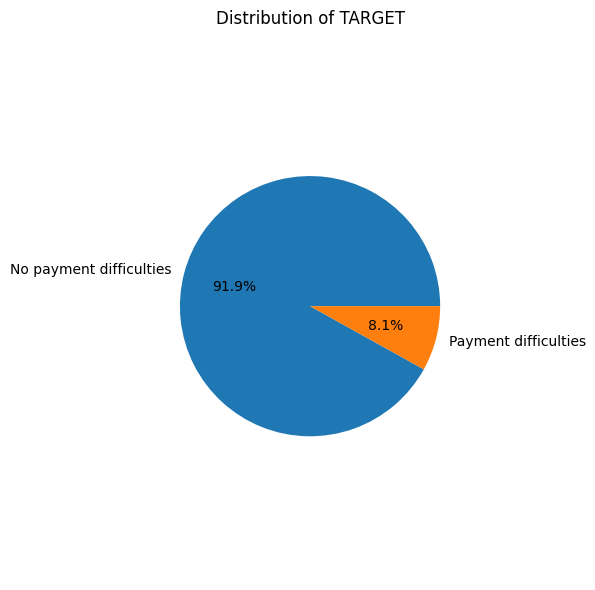

In [414]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

df_train_final['TARGET'].value_counts().sort_index().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No payment difficulties', 'Payment difficulties'],
    ax=ax
)

ax.set_ylabel('')
ax.axis('equal')
ax.set_title('Distribution of TARGET')
plt.tight_layout()
plt.show()

## 1. Train-test split

**Naming convention used in this notebook**

- `X_train` / `y_train` — 80% of `df_train_final`, used to fit the models
- `X_valid` / `y_valid` — 20% of `df_train_final`, used to evaluate them
  (this is the "test set" in the usual ML sense; we call it *valid* to avoid
  confusion with the Kaggle `application_test` file)
- `X_test` — from `application_test`, **unlabelled**: final predictions only,
  never used for evaluation

In [415]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import numpy as np

features = [f for f in df_train_final.columns
            if f not in ['TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV', 'index']]

X = df_train_final[features].replace([np.inf, -np.inf], np.nan) # replace inf if any
y = df_train_final['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42 # we use 'stratify' to address class unbalance
)

X_test = df_test_final[features].replace([np.inf, -np.inf], np.nan) 

In [416]:
# Sanity checks
print("1. Overlap between train and valid:", len(set(X_train.index) & set(X_valid.index)))
print("2. Sizes add up:", len(X_train) + len(X_valid), "vs", len(X))
print("3. About same Default rate (train / valid / full):",
      round(y_train.mean(), 4), round(y_valid.mean(), 4), round(y.mean(), 4)) # to verify the "stratify"
print("4. Same columns:", list(X_train.columns) == list(X_valid.columns) == list(X_test.columns))
print("5. TARGET leaked into features?", 'TARGET' in X.columns)

1. Overlap between train and valid: 0
2. Sizes add up: 307511 vs 307511
3. About same Default rate (train / valid / full): 0.0807 0.0807 0.0807
4. Same columns: True
5. TARGET leaked into features? False


## 2. Reusable functions: business_cost, find_best_threshold, train_and_save, log_to_mlflow

In [417]:
from pathlib import Path
import json
import joblib
import pandas as pd
from sklearn.metrics import precision_score, recall_score, average_precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

In [418]:
import mlflow
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

mlflow.set_experiment("home_credit_scoring")

<Experiment: artifact_location='/Users/elodiechen/Downloads/2025_2027_Alternance/OpenClassrooms/Projets/projet_6/mlruns/1', creation_time=1788594217929, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788594217929, lifecycle_stage='active', name='home_credit_scoring', tags={}, trace_location=None, workspace='default'>

In [419]:
def business_cost(y_true, y_pred, cost_fn=10, cost_fp=1):
    """Business cost of prediction errors.

    FN = defaulting client predicted as creditworthy -> credit granted -> capital loss (which is assumed 10 times worse than not granting credit when you're not convinced) 
    FP = good client predicted as defaulting  -> credit refused -> lost margin

    A false negative  (capital loss) is assumed 10x more expensive than a false positive (lost margin).
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * cost_fn + fp * cost_fp

In [420]:
def find_best_threshold(y_true, proba, cost_fn=10, cost_fp=1, plot=True, save_path=None):
    """Test many thresholds on the same probabilities and return the cheapest one."""

    thresholds = np.linspace(0.05, 0.95, 91)    # 0.05, 0.06, ..., 0.94, 0.95
    costs = [business_cost(y_true, (proba >= t).astype(int), cost_fn, cost_fp)
             for t in thresholds]

    best_idx = int(np.argmin(costs))
    best_threshold = thresholds[best_idx]

    if plot or save_path:
        plt.figure(figsize=(7, 4))
        plt.plot(thresholds, costs)
        plt.axvline(best_threshold, color='red', linestyle='--',
                    label=f'best = {best_threshold:.2f}')
        plt.axvline(0.5, color='grey', linestyle=':', label='default = 0.50')
        plt.xlabel('Decision threshold')
        plt.ylabel('Business cost')
        plt.title('Business cost vs decision threshold')
        plt.legend()

        if save_path:
            plt.savefig(save_path, dpi=100, bbox_inches='tight')
        if plot:
            plt.show()
        else:
            plt.close()

    return best_threshold, costs[best_idx]

In [421]:
def train_and_save(model, model_name, features, output_folder, nan_threshold=0.80, decision_threshold=0.50, use_cv=False):
    """Train a model and save model + features + params + metrics into a folder.
    No MLflow involved here."""

    folder = Path(output_folder)
    folder.mkdir(parents=True, exist_ok=True)

    # --- keep only the requested features
    Xtr = X_train[features]
    Xva = X_valid[features]

    # --- drop the columns too empty to be imputed (threshold from train only)
    nan_pct = Xtr.isnull().mean()
    too_empty = nan_pct[nan_pct > nan_threshold].index.tolist()
    Xtr = Xtr.drop(columns=too_empty)
    Xva = Xva.drop(columns=too_empty)

    cat_cols = Xtr.select_dtypes(include='object').columns.tolist()
    num_cols = Xtr.select_dtypes(include='number').columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
            ('scaler',  StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cat_cols),
    ])

    pipe = Pipeline([('preprocessing', preprocessor), ('model', model)])
    pipe.fit(Xtr, y_train)

    if use_cv:
        from sklearn.model_selection import cross_validate, StratifiedKFold
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        cv_scores = cross_validate(
            pipe, 
            Xtr, 
            y_train, 
            cv=cv, 
            scoring=['roc_auc', 'average_precision','precision', 'recall', 'f1'], 
            n_jobs=-1
            )

    # --- save everything to the folder
    joblib.dump(pipe, folder / "model.joblib")

    (folder / "features.txt").write_text("\n".join(Xtr.columns))

    params = {
        "model": model_name,
        "nan_threshold": nan_threshold,
        "decision_threshold": decision_threshold,
        "n_features_in": len(features),
        "n_features_used": Xtr.shape[1],
        "n_columns_dropped": len(too_empty),
    }

    # only add the model's hyperparameters that differ from the library defaults (instead of including them all)
    defauts  = type(model)().get_params()
    modifies = {f"model__{k}": v for k, v in model.get_params().items()
                if v != defauts.get(k)}
    params.update(modifies)

    # library versions cover the defaults
    import sklearn
    params["sklearn_version"] = sklearn.__version__
    params["model_class"]     = type(model).__name__


    (folder / "params.json").write_text(json.dumps(params, indent=2))

    proba_valid = pipe.predict_proba(Xva)[:, 1]
    pred_valid = (proba_valid >= decision_threshold).astype(int)

    # --- search the cost-optimal threshold on the same probabilities (nearly free)
    best_thr, best_cost = find_best_threshold(y_valid, proba_valid, plot=False, 
                                              save_path=folder / "cost_vs_threshold.png")

    # --- computed once, reused below in metrics
    proba_train = pipe.predict_proba(Xtr)[:, 1]
    cost_valid    = business_cost(y_valid, pred_valid)
    cost_baseline = business_cost(y_valid, np.zeros(len(y_valid), dtype=int))

    metrics = {
        "roc_auc_train":   roc_auc_score(y_train, proba_train),
        "roc_auc_valid":   roc_auc_score(y_valid, proba_valid),
        "pr_auc_train":    average_precision_score(y_train, proba_train),
        "pr_auc_valid":    average_precision_score(y_valid, proba_valid),
        "recall_valid":    recall_score(y_valid, pred_valid),
        "precision_valid": precision_score(y_valid, pred_valid),
        "f1_valid":        f1_score(y_valid, pred_valid), 
        "business_cost_valid":            cost_valid,                 # at decision_threshold
        "business_cost_per_client_valid": cost_valid / len(y_valid),
        "best_threshold": best_thr,       # the optimum found
        "best_cost":      best_cost,      # its cost

        # the following metric 'business_cost_baseline' = Reference bar, discussed in "Reference points for the business cost" below:
        # granting every loan is the cheapest decision that needs no model at all.
        # It plays the same role as 0.50 for ROC AUC or pi = 0.08 for PR AUC:
        # the level below which the modelling work brought nothing.
        "business_cost_baseline":  cost_baseline,
        "business_cost_saved":     cost_baseline - cost_valid,        # positive -> the model pays off
        "business_cost_saved_pct": 1 - cost_valid / cost_baseline,    # same thing, scale-free
    }
    metrics["roc_auc_gap"] = metrics["roc_auc_train"] - metrics["roc_auc_valid"]
    metrics["pr_auc_gap"]  = metrics["pr_auc_train"]  - metrics["pr_auc_valid"]

    if use_cv:
        for m in ['roc_auc', 'average_precision','precision', 'recall', 'f1']:
            metrics[f"cv_{m}_mean"] = cv_scores[f'test_{m}'].mean()
            metrics[f"cv_{m}_std"] = cv_scores[f'test_{m}'].std() # model's stability 

    pd.DataFrame([metrics]).to_csv(folder / "metrics.csv", index=False)

    print(f"{model_name} | {Xtr.shape[1]} features "
          f"| AUC valid = {metrics['roc_auc_valid']:.4f} "
          f"| cost@{decision_threshold} = {metrics['business_cost_valid']:.0f} "
          f"| saved in {folder}"
          f"| best thr = {best_thr:.2f} -> {best_cost:.0f}")

    return folder

In [422]:
from sklearn.metrics import roc_curve, precision_recall_curve

def plot_roc_pr(folders, output_path, title="ROC and Precision-Recall curves"):
    """Draw ROC and PR curves of one or several saved models, on the VALIDATION set.
    Nothing is retrained: each pipeline is reloaded from its folder."""

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for f in [Path(x) for x in folders]:
        pipe_i = joblib.load(f / "model.joblib")
        feats  = [c for c in (f / "features.txt").read_text().split("\n") if c]
        name   = json.loads((f / "params.json").read_text())["model"]
        proba  = pipe_i.predict_proba(X_valid[feats])[:, 1]

        fpr, tpr, _ = roc_curve(y_valid, proba)
        axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_valid, proba):.3f})")

        prec, rec, _ = precision_recall_curve(y_valid, proba)
        axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(y_valid, proba):.3f})")

    baseline = y_valid.mean()    # the positive rate IS the random baseline of a PR curve

    axes[0].plot([0, 1], [0, 1], 'k:', label='random (0.500)')
    axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
    axes[0].set_title('ROC'); axes[0].legend(fontsize=8)

    axes[1].axhline(baseline, color='k', linestyle=':', label=f'random ({baseline:.3f})')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall'); axes[1].legend(fontsize=8)

    fig.suptitle(title)
    fig.savefig(output_path, dpi=100, bbox_inches='tight')
    plt.show()
    return output_path

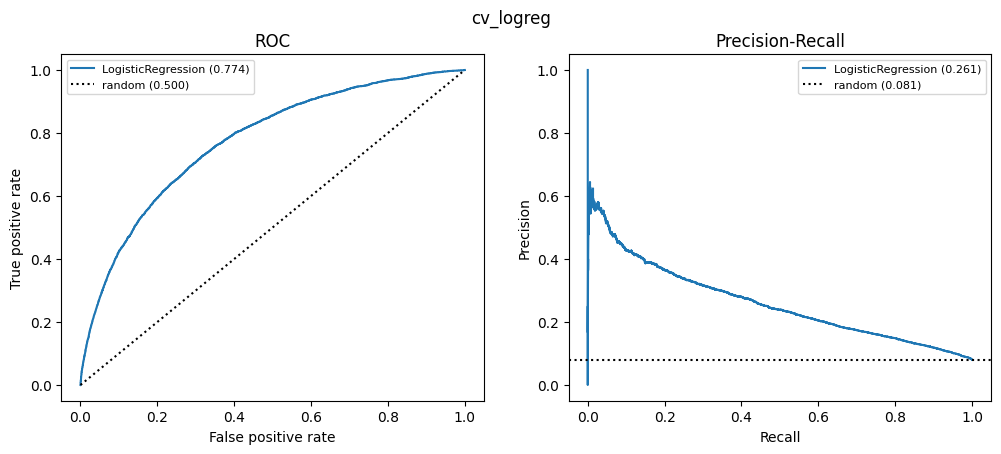

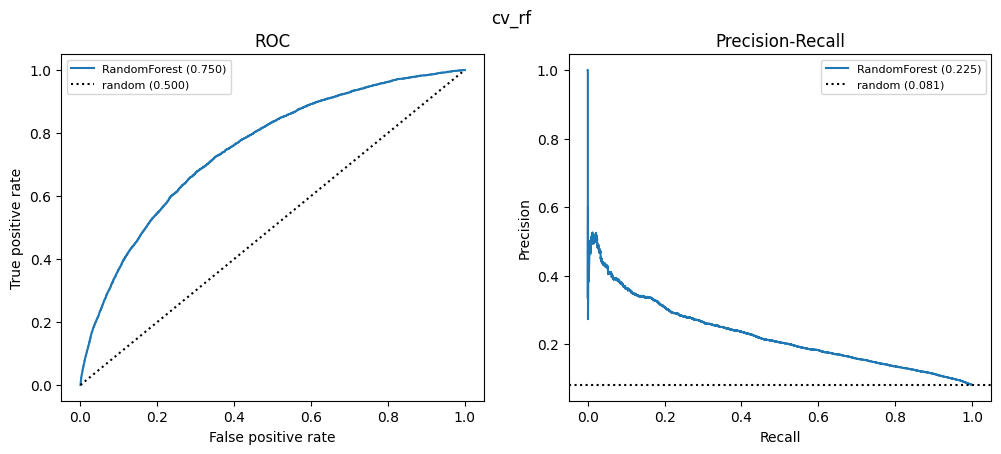

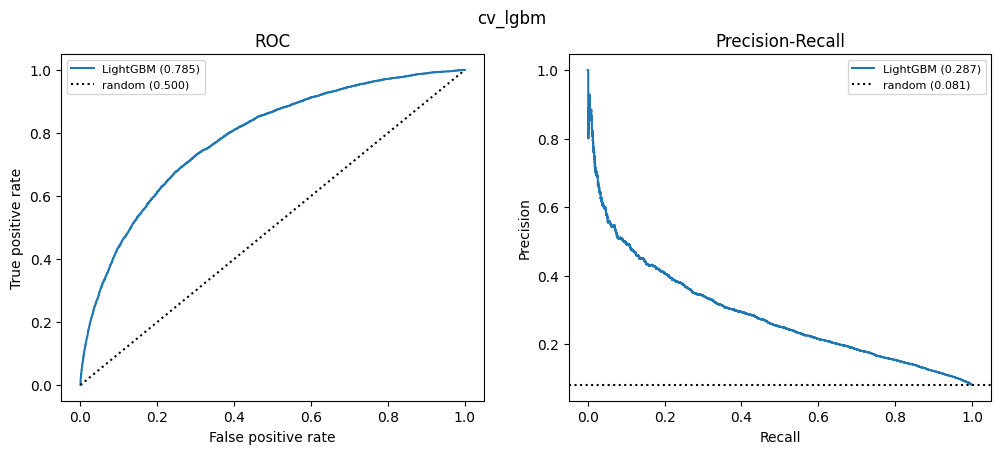

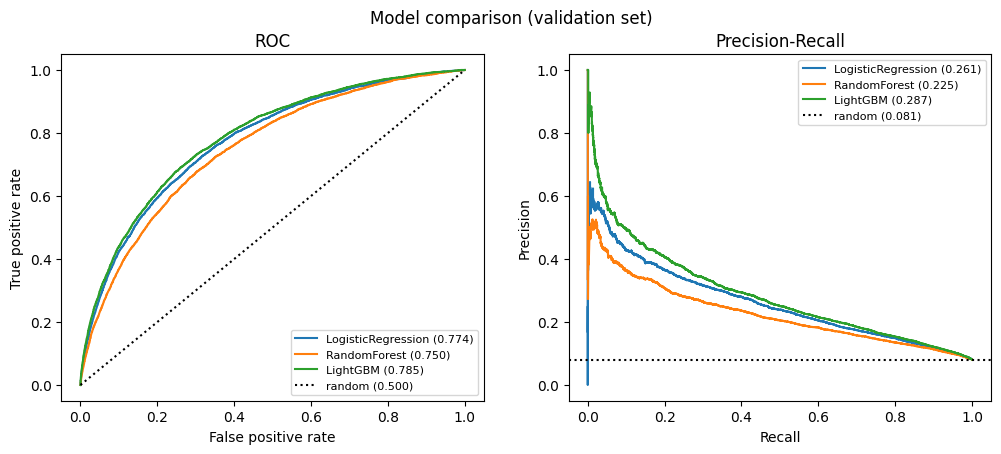

'runs/model_comparison_curves.png'

In [423]:
# Draw ROC and PR curves from the saved pipelines - nothing is retrained

# 1) one PNG per model, saved inside its own folder so log_to_mlflow picks it up
for r in ['runs/cv_logreg', 'runs/cv_rf', 'runs/cv_lgbm']:
    plot_roc_pr([r], Path(r) / "roc_pr_curves.png", title=Path(r).name)

# 2) one PNG comparing the three model families -> the figure for the presentation
plot_roc_pr(['runs/cv_logreg', 'runs/cv_rf', 'runs/cv_lgbm'],
            "runs/model_comparison_curves.png",
            title="Model comparison (validation set)") 


In [424]:
def log_to_mlflow(output_folder, run_name=None, tags=None, register=False):
    """Read a training folder and push its content to MLflow. No training here."""

    import mlflow

    folder = Path(output_folder)

    params  = json.loads((folder / "params.json").read_text())
    metrics = pd.read_csv(folder / "metrics.csv").iloc[0].to_dict()

    with mlflow.start_run(run_name=run_name or folder.name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)

        if tags:
            mlflow.set_tags(tags)

        mlflow.log_artifact(folder / "features.txt")

        # --- any plot saved in the folder
        for png in folder.glob("*.png"):
            mlflow.log_artifact(png)
        # --- any shap file
        for f in folder.glob("shap_*.csv"):
            mlflow.log_artifact(f)
        # --- predictions on the unlabelled test file, if any
        for csv in folder.glob("predictions_*.csv"):
            mlflow.log_artifact(csv)

        # --- the model, versioned in the registry
        if register:
            mlflow.sklearn.log_model(
                joblib.load(folder / "model.joblib"),
                name=params.get("model", "model"),
                registered_model_name="credit_scoring_model",
                serialization_format="cloudpickle",
            )
        else:
            mlflow.log_artifact(folder / "model.joblib")

    print(f"{folder.name} logged to MLflow")


## 3. Reference points for the business cost

A business cost is an absolute count, so a value of 30 000 means nothing on its own.
Two decisions require no model at all, and the cheaper of the two is the bar any
model has to beat. This plays the same role as 0.50 for ROC AUC, or the positive
rate pi = 0.08 for PR AUC: the level below which the modelling work brought nothing.


In [425]:
# --- reference points: the two decisions that require no model at all

import numpy as np

accept_all = np.zeros(len(y_valid), dtype=int)   # grant every loan
refuse_all = np.ones(len(y_valid),  dtype=int)   # refuse every loan

cost_accept_all = business_cost(y_valid, accept_all)
cost_refuse_all = business_cost(y_valid, refuse_all)
best_trivial    = min(cost_accept_all, cost_refuse_all)

print(f"accept everyone : {cost_accept_all:8.0f}")
print(f"refuse everyone : {cost_refuse_all:8.0f}")
print(f"best trivial    : {best_trivial:8.0f}   <- the bar any model must beat")

accept everyone :    49650
refuse everyone :    56538
best trivial    :    49650   <- the bar any model must beat


## 4. Model Comparison : Find the Best Model Using Cross-validation

In [426]:
# Find the Best Model Using the Cross-Validation function built into the train_and_save function

# 1. Logistic Regression

train_and_save(
    LogisticRegression(max_iter=300, class_weight='balanced'),
    "LogisticRegression", features, "runs/cv_logreg", use_cv=True
    )

Python(2591) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2592) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2593) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2594) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2595) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2596) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2597) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2598) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2599) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2600) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


LogisticRegression | 422 features | AUC valid = 0.7740 | cost@0.5 = 31416 | saved in runs/cv_logreg| best thr = 0.56 -> 31251


PosixPath('runs/cv_logreg')

In [427]:
# 2. Random Forest

train_and_save(
    RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=42
        ),
    "RandomForest", features, "runs/cv_rf", use_cv=True
)

RandomForest | 422 features | AUC valid = 0.7504 | cost@0.5 = 33356 | saved in runs/cv_rf| best thr = 0.48 -> 33147


PosixPath('runs/cv_rf')

In [428]:
# 3. Light Gradient Boosting Machine

import warnings 

warnings.filterwarnings('ignore', category=UserWarning)
train_and_save(
    lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                  class_weight='balanced', random_state=42, verbose=-1),
    "LightGBM", features, "runs/cv_lgbm", use_cv=True
)

Python(2697) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2698) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2699) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2700) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2701) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


LightGBM | 422 features | AUC valid = 0.7850 | cost@0.5 = 30222 | saved in runs/cv_lgbm| best thr = 0.52 -> 30073


PosixPath('runs/cv_lgbm')

In [429]:
log_to_mlflow("runs/cv_logreg",
              run_name="logreg_nan0.8_cv3",       # Run name : Model name / what varies / evaluation method
              tags={"phase": "model_comparison",
                    "model_family": "linear",
                    "note": "baseline, 3-fold CV, same preprocessing as others"})

log_to_mlflow("runs/cv_rf",
              run_name="rf_nan0.8_cv3",
              tags={"phase": "model_comparison",
                    "model_family": "bagging",
                    "note": "200 trees, depth 10, 3-fold CV"})

log_to_mlflow("runs/cv_lgbm",
              run_name="lgbm_nan0.8_cv3",
              tags={"phase": "model_comparison",
                    "model_family": "boosting",
                    "note": "winner: best AUC and lowest business cost"},
              register=True)      # Register the model because it performed the best

cv_logreg logged to MLflow
cv_rf logged to MLflow


2026/10/02 16:05:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Python(2873) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


cv_lgbm logged to MLflow


Registered model 'credit_scoring_model' already exists. Creating a new version of this model...
Created version '5' of model 'credit_scoring_model'.


## 5. Decision threshold analysis

In [430]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

lgbm_params = dict(n_estimators=200, learning_rate=0.05,
                   class_weight='balanced', random_state=42, verbose=-1)

train_and_save(lgb.LGBMClassifier(**lgbm_params),
               "LightGBM", features, "runs/thr_050", decision_threshold=0.50)

train_and_save(lgb.LGBMClassifier(**lgbm_params),
               "LightGBM", features, "runs/thr_020", decision_threshold=0.20)

train_and_save(lgb.LGBMClassifier(**lgbm_params),
               "LightGBM", features, "runs/thr_010", decision_threshold=0.10)

LightGBM | 422 features | AUC valid = 0.7850 | cost@0.5 = 30222 | saved in runs/thr_050| best thr = 0.52 -> 30073
LightGBM | 422 features | AUC valid = 0.7850 | cost@0.2 = 44196 | saved in runs/thr_020| best thr = 0.52 -> 30073
LightGBM | 422 features | AUC valid = 0.7850 | cost@0.1 = 53626 | saved in runs/thr_010| best thr = 0.52 -> 30073


PosixPath('runs/thr_010')

In [431]:
# Log to MlFlow
log_to_mlflow("runs/thr_050", run_name="lgbm_thr0.50", tags={"phase": "threshold_test"})
log_to_mlflow("runs/thr_020", run_name="lgbm_thr0.20", tags={"phase": "threshold_test"})
log_to_mlflow("runs/thr_010", run_name="lgbm_thr0.10", tags={"phase": "threshold_test"})

thr_050 logged to MLflow
thr_020 logged to MLflow
thr_010 logged to MLflow


## 6. Hyperparameters Tuning Using GridSearchCV

In [432]:
from sklearn.metrics import make_scorer

cost_scorer = make_scorer(
    business_cost, 
    greater_is_better=False # We want it to be kept to a minimum
    )

In [433]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import lightgbm as lgb

# --- Preparation process similar to that of train_and_save
features = X_train.columns.tolist()
Xtr = X_train[features]
nan_pct = Xtr.isnull().mean()
too_empty = nan_pct[nan_pct > 0.80].index.tolist()
Xtr = Xtr.drop(columns=too_empty)

cat_cols = Xtr.select_dtypes(include='object').columns.tolist()
num_cols = Xtr.select_dtypes(include='number').columns.tolist()

prep = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median', add_indicator=True)),
                      ('scaler',  StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                      ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

pipe = Pipeline([
    ('preprocessing', prep),
    ('model', lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)),
])

# --- The Grid: Parameters are named using the step prefix
grid = {
    'model__num_leaves':    [15, 31],
    'model__learning_rate': [0.04],
    'model__n_estimators':  [200],
    'model__min_child_samples': [20, 100],
    'model__colsample_bytree':  [0.8],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = GridSearchCV(
    pipe,
    param_grid=grid,
    scoring={'auc': 'roc_auc', 'cost': cost_scorer},
    refit='cost',              # we keep the model that minimizes the cost
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

search.fit(Xtr, y_train)

print("Best parameters :", search.best_params_)
print("Best cost (CV)   :", -search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


Python(2987) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2991) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2992) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(2993) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Best parameters : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.04, 'model__min_child_samples': 100, 'model__n_estimators': 200, 'model__num_leaves': 31}
Best cost (CV)   : 40979.333333333336


In [434]:
import pandas as pd

results = pd.DataFrame(search.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__colsample_bytree,param_model__learning_rate,param_model__min_child_samples,param_model__n_estimators,param_model__num_leaves,params,...,split2_test_auc,mean_test_auc,std_test_auc,rank_test_auc,split0_test_cost,split1_test_cost,split2_test_cost,mean_test_cost,std_test_cost,rank_test_cost
0,363.99,12.01,35.12,2.97,0.80,0.04,20,200,15,"{'model__colsample_bytree': 0.8, 'model__learn...",...,0.78,0.78,0.00,4,"-41,823.00","-41,039.00","-41,558.00","-41,473.33",325.62,3
1,402.35,4.69,16.26,1.31,0.80,0.04,20,200,31,"{'model__colsample_bytree': 0.8, 'model__learn...",...,0.78,0.78,0.00,1,"-41,625.00","-40,412.00","-41,189.00","-41,075.33",501.69,2
2,374.14,11.93,29.93,4.74,0.80,0.04,100,200,15,"{'model__colsample_bytree': 0.8, 'model__learn...",...,0.78,0.78,0.00,3,"-41,868.00","-41,032.00","-41,744.00","-41,548.00",368.36,4
3,189.22,147.61,7.48,5.35,0.80,0.04,100,200,31,"{'model__colsample_bytree': 0.8, 'model__learn...",...,0.78,0.78,0.00,2,"-41,322.00","-40,458.00","-41,158.00","-40,979.33",374.67,1


In [435]:
for i, row in results.iterrows():
    with mlflow.start_run(run_name=f"gs_lgbm_combo{i}"):
        mlflow.log_params(row['params'])
        mlflow.log_metric("cv_roc_auc",  row['mean_test_auc'])
        mlflow.log_metric("cv_cost", -row['mean_test_cost'])
        mlflow.log_metric("rank_cost", row['rank_test_cost'])
        mlflow.set_tags({"phase": "hyperparameter_tuning", "search": "GridSearchCV"})

In [436]:
best_pipe = search.best_estimator_
best_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](422,)","['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR',...,'INCOME_PER_PERSON', 'ANNUITY_INCOME_PERC','PAYMENT_RATE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,422
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

## 7. Final Model

In [437]:
# Read the winning hyperparameters straight from the search, so the final model
# can never drift away from what GridSearchCV actually selected
best_params = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
print("Retraining the final model with:", best_params)

train_and_save(
    lgb.LGBMClassifier(**best_params, class_weight='balanced', random_state=42, verbose=-1),
    "LightGBM_tuned", features, "runs/lgbm_tuned"
)

Retraining the final model with: {'colsample_bytree': 0.8, 'learning_rate': 0.04, 'min_child_samples': 100, 'n_estimators': 200, 'num_leaves': 31}
LightGBM_tuned | 422 features | AUC valid = 0.7844 | cost@0.5 = 30272 | saved in runs/lgbm_tuned| best thr = 0.52 -> 30192


PosixPath('runs/lgbm_tuned')

The final model is applied to `application_test`, which has no TARGET. These are
real production predictions: a probability of default per client, and the accept /
refuse decision taken at the cost-optimal threshold.

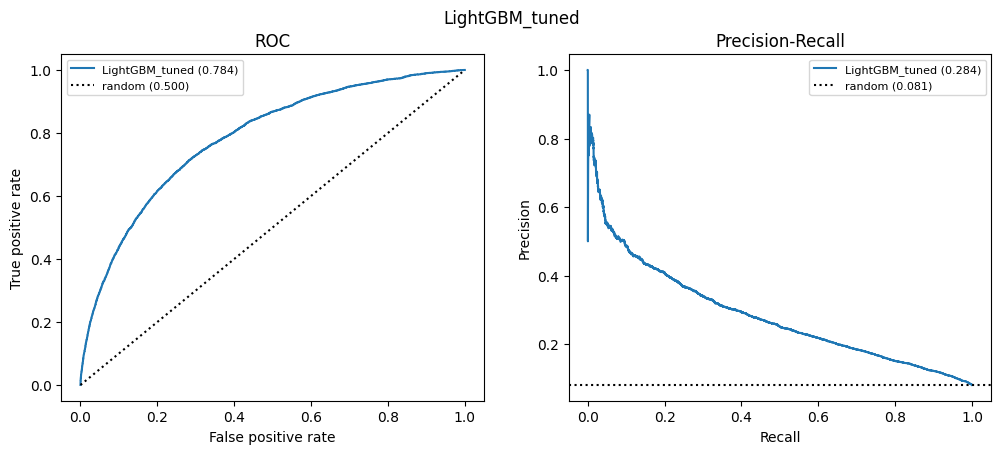

   SK_ID_CURR  proba_default  decision
0      100001           0.33         0
1      100005           0.58         1
2      100013           0.22         0
3      100028           0.22         0
4      100038           0.61         1

13253 loans refused out of 48744 (27.2%) at threshold 0.52


In [438]:
# --- Final predictions on the unlabelled Kaggle test file
final_pipe = joblib.load("runs/lgbm_tuned/model.joblib")
used_feats = [c for c in Path("runs/lgbm_tuned/features.txt").read_text().split("\n") if c]
best_thr   = pd.read_csv("runs/lgbm_tuned/metrics.csv")['best_threshold'].iloc[0]

predictions = pd.DataFrame({
    'SK_ID_CURR':    df_test_final['SK_ID_CURR'],
    'proba_default': final_pipe.predict_proba(X_test[used_feats])[:, 1],
})
predictions['decision'] = (predictions['proba_default'] >= best_thr).astype(int)
predictions.to_csv("runs/lgbm_tuned/predictions_test.csv", index=False)

# --- ROC and PR curves of the final model
plot_roc_pr(['runs/lgbm_tuned'], "runs/lgbm_tuned/roc_pr_curves.png", title="LightGBM_tuned")

print(predictions.head())
print(f"\n{predictions['decision'].sum()} loans refused out of {len(predictions)} "
      f"({predictions['decision'].mean():.1%}) at threshold {best_thr:.2f}")

In [439]:
log_to_mlflow("runs/lgbm_tuned/",
              run_name='lgbm_tuned_final', 
              tags={
                  "phase" : "final", 
                  "note": "best params from GridSearchCV"
              },
              register=True)

2026/10/02 16:18:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Python(3507) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


lgbm_tuned logged to MLflow


Registered model 'credit_scoring_model' already exists. Creating a new version of this model...
Created version '6' of model 'credit_scoring_model'.


## 8. Sensitivity to the missing-value threshold

`nan_threshold` decides which columns are dropped before imputation: with 0.30, any
column missing more than 30% of its train values is removed. The threshold is always
computed on the train set only, so the validation set never influences the decision.

LightGBM handles NaN natively and `add_indicator=True` turns "value is missing" into
a usable feature, so we expect high thresholds to perform at least as well.

In [440]:
for nan_thr in [0.30, 0.60, 0.95]:
    train_and_save(
        lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                           colsample_bytree=0.8, min_child_samples=20,
                           class_weight='balanced', random_state=42, verbose=-1),
        f"LightGBM_nan{nan_thr}", features, f"runs/lgbm_nan{nan_thr}",
        nan_threshold=nan_thr
    )
    log_to_mlflow(f"runs/lgbm_nan{nan_thr}", run_name=f"lgbm_nan{nan_thr}",
                  tags={"phase": "nan_threshold_study",
                        "note": f"drop columns with more than {nan_thr:.0%} missing values"})

LightGBM_nan0.3 | 306 features | AUC valid = 0.7819 | cost@0.5 = 30211 | saved in runs/lgbm_nan0.3| best thr = 0.51 -> 30205
lgbm_nan0.3 logged to MLflow
LightGBM_nan0.6 | 342 features | AUC valid = 0.7858 | cost@0.5 = 30084 | saved in runs/lgbm_nan0.6| best thr = 0.52 -> 30051
lgbm_nan0.6 logged to MLflow
LightGBM_nan0.95 | 425 features | AUC valid = 0.7862 | cost@0.5 = 30176 | saved in runs/lgbm_nan0.95| best thr = 0.54 -> 30009
lgbm_nan0.95 logged to MLflow


# D. EXPLAINABILITY

## 1. Feature importance (global SHAP)

Python(3554) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.
Explaining 61503 clients


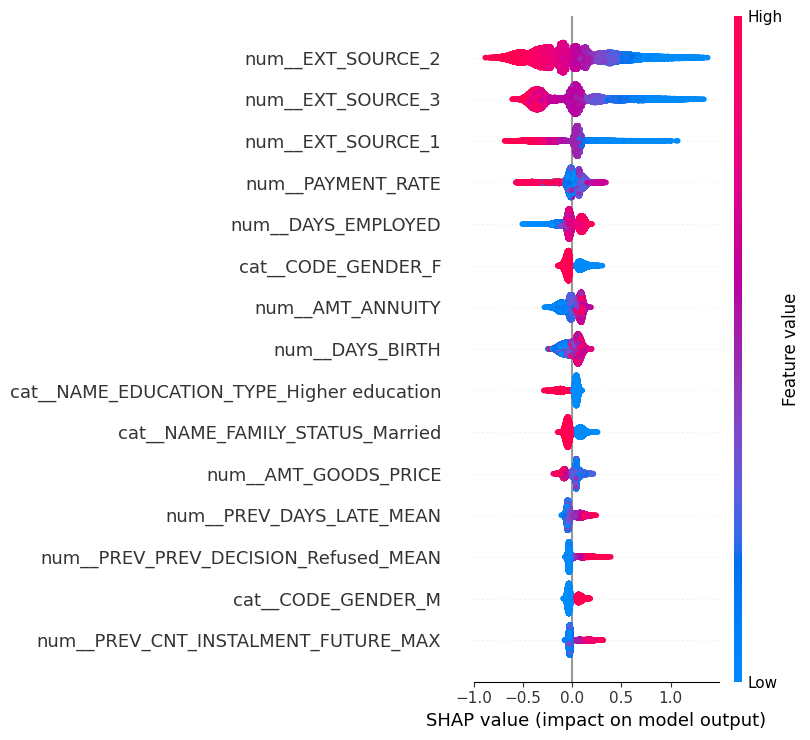

In [441]:
%pip install shap

import shap, joblib
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

folder = Path("runs/lgbm_tuned")
pipe = joblib.load(folder / "model.joblib")
used_features = [c for c in (folder / "features.txt").read_text().split("\n") if c]

X_expl = X_valid[used_features]
print(f"Explaining {len(X_expl)} clients")

# --- split the pipeline: SHAP explains the model, not the preprocessing
X_prep        = pipe.named_steps['preprocessing'].transform(X_expl)
feature_names = pipe.named_steps['preprocessing'].get_feature_names_out()
model         = pipe.named_steps['model']

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_prep)

shap.summary_plot(shap_values, X_prep, feature_names, max_display=15, show=False)
plt.savefig(folder / "shap_global.png", dpi=100, bbox_inches='tight')
plt.show()

In [442]:
import numpy as np, pandas as pd

importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(importance.head(20).to_string())

importance.to_csv(folder / "shap_importance.csv", index=False)

                                      feature  mean_abs_shap
0                           num__EXT_SOURCE_2           0.32
1                           num__EXT_SOURCE_3           0.28
2                           num__EXT_SOURCE_1           0.13
3                           num__PAYMENT_RATE           0.09
4                          num__DAYS_EMPLOYED           0.08
5                          cat__CODE_GENDER_F           0.07
6                            num__AMT_ANNUITY           0.07
7                             num__DAYS_BIRTH           0.07
8   cat__NAME_EDUCATION_TYPE_Higher education           0.06
9             cat__NAME_FAMILY_STATUS_Married           0.06
10                       num__AMT_GOODS_PRICE           0.06
11                   num__PREV_DAYS_LATE_MEAN           0.06
12       num__PREV_PREV_DECISION_Refused_MEAN           0.05
13                         cat__CODE_GENDER_M           0.05
14        num__PREV_CNT_INSTALMENT_FUTURE_MAX           0.05
15       num__PREV_CNT_I

## 2. Individual prediction (local SHAP)

FN : client 91121 | proba = 0.059 | actual = 1 | 1606 clients in this quadrant


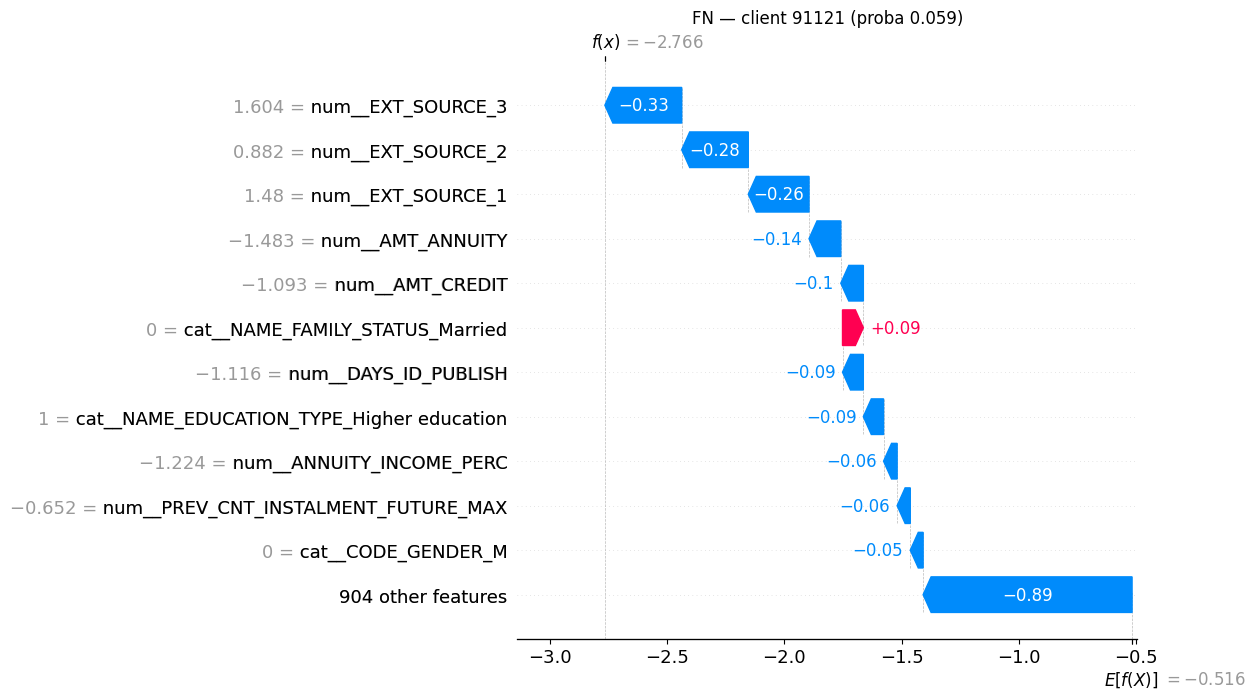

FP : client 274668 | proba = 0.933 | actual = 0 | 14132 clients in this quadrant


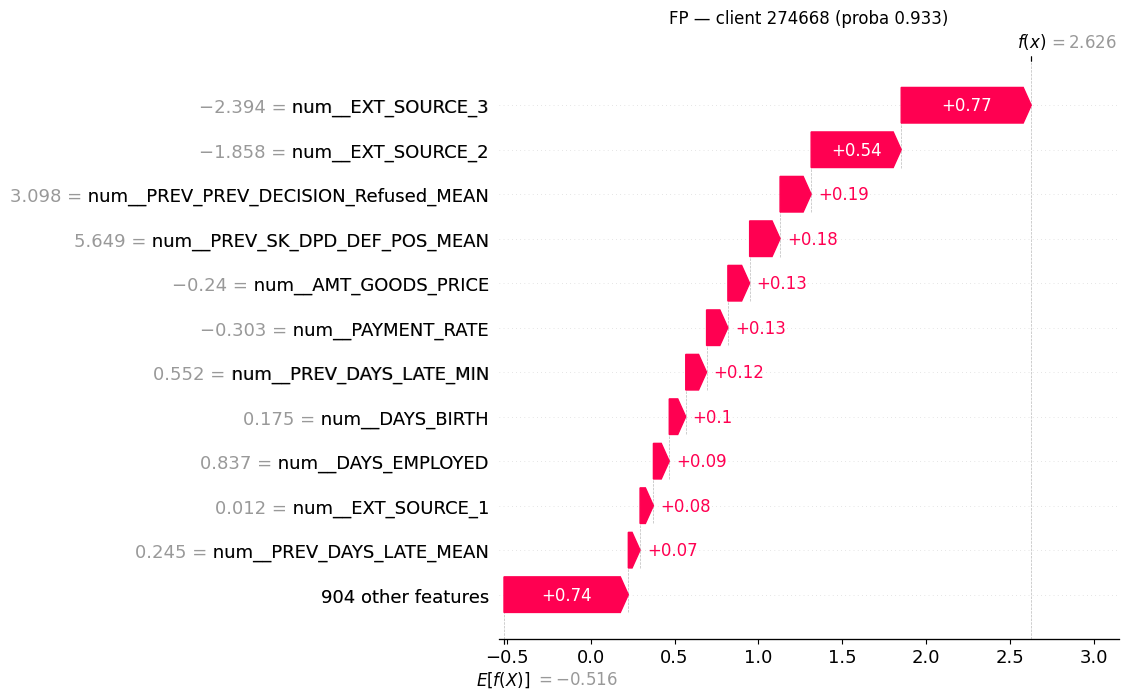

TP : client 156963 | proba = 0.760 | actual = 1 | 3359 clients in this quadrant


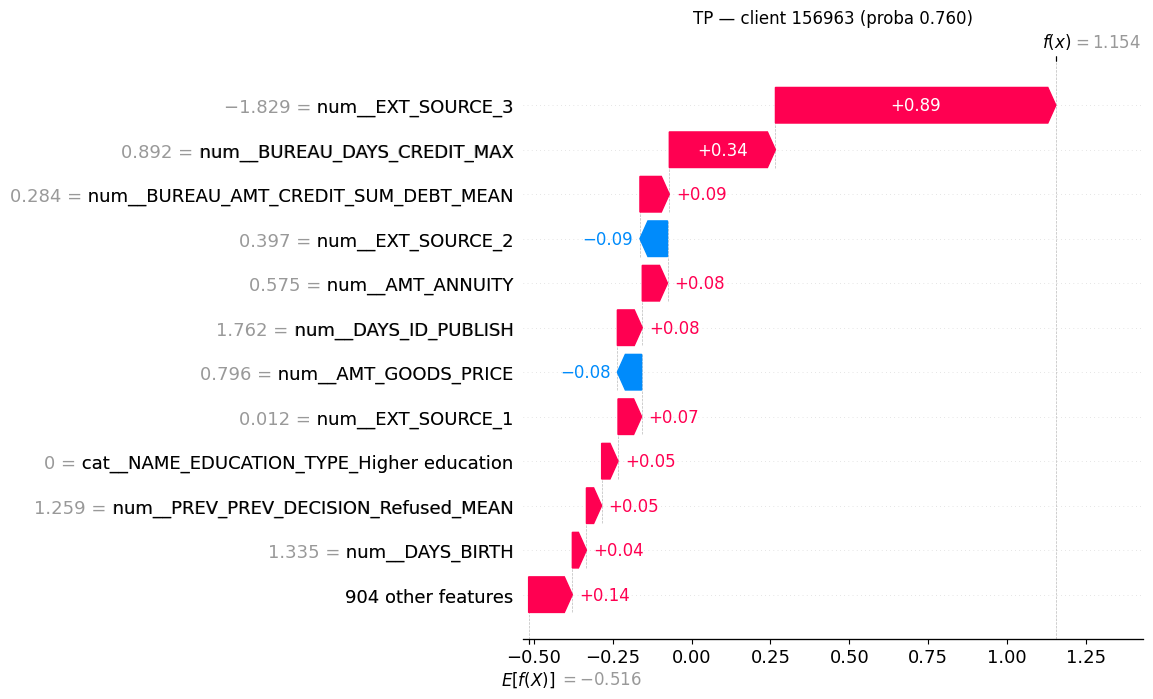

TN : client 256571 | proba = 0.300 | actual = 0 | 42406 clients in this quadrant


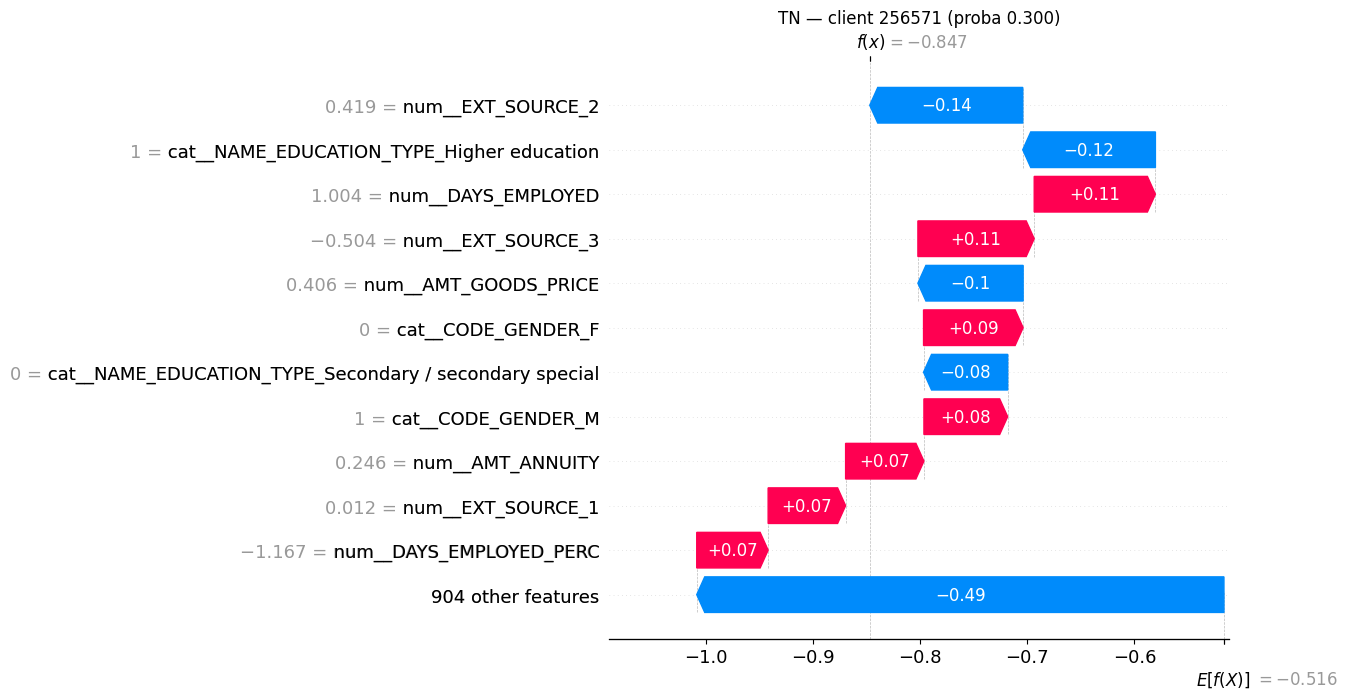

In [443]:
import numpy as np

# --- We retrieve the actual answers and the predictions for the expl
proba_expl = pipe.predict_proba(X_expl)[:, 1]
y_expl     = y_valid.loc[X_expl.index]
pred_expl  = (proba_expl >= 0.52).astype(int)      # optimal threshold at 0.52

quadrants = {
    'FN': (y_expl == 1) & (pred_expl == 0),   # missed default -> the most expensive error
    'FP': (y_expl == 0) & (pred_expl == 1),   # good client wrongly rejected
    'TP': (y_expl == 1) & (pred_expl == 1),   # default correctly caught
    'TN': (y_expl == 0) & (pred_expl == 0),   # good client correctly accepted
}

for quad_name, mask in quadrants.items():
    positions = np.where(mask.values)[0]
    if len(positions) == 0:
        print(f"{quad_name} : No client in this quadrant")
        continue

    if quad_name == 'FN':
        # lowest probability among the FNs: the default the model was most wrong about
        i = positions[np.argmin(proba_expl[positions])]   # argmin: what the model predicted to have the lowest risk of default
    elif quad_name == 'FP':
        i = positions[np.argmax(proba_expl[positions])]   # argmax : good client the model rejected hardest, what the model predicted to have the highest risk of default
    else:
        i = positions[0]

    client_id = X_expl.index[i]

    print(f"{quad_name} : client {client_id} | proba = {proba_expl[i]:.3f} "
          f"| actual = {y_expl.iloc[i]} | {len(positions)} clients in this quadrant")

    shap.plots.waterfall(
        shap.Explanation(values=shap_values[i],
                         base_values=explainer.expected_value,
                         data=X_prep[i],
                         feature_names=list(feature_names)),
        max_display=12, show=False
    )
    plt.title(f"{quad_name} — client {client_id} (proba {proba_expl[i]:.3f})")
    plt.savefig(folder / f"shap_local_{quad_name}.png", dpi=100, bbox_inches='tight')
    plt.show()


In [444]:
# Reload important features
from pathlib import Path
import pandas as pd

folder = Path("runs/lgbm_tuned")

shap_imp      = pd.read_csv(folder / "shap_importance.csv")
used_features = [c for c in (folder / "features.txt").read_text().split("\n") if c]

print(shap_imp.head(10).to_string())
print(f"\n{len(shap_imp)} transformed features / {len(used_features)} original columns")

                                     feature  mean_abs_shap
0                          num__EXT_SOURCE_2           0.32
1                          num__EXT_SOURCE_3           0.28
2                          num__EXT_SOURCE_1           0.13
3                          num__PAYMENT_RATE           0.09
4                         num__DAYS_EMPLOYED           0.08
5                         cat__CODE_GENDER_F           0.07
6                           num__AMT_ANNUITY           0.07
7                            num__DAYS_BIRTH           0.07
8  cat__NAME_EDUCATION_TYPE_Higher education           0.06
9            cat__NAME_FAMILY_STATUS_Married           0.06

915 transformed features / 422 original columns


In [445]:
# Clean the prefixes

shap_imp['clean'] = (shap_imp['feature']
                     .str.replace('num__', '', regex=False)
                     .str.replace('cat__', '', regex=False)
                     .str.replace('missingindicator_', '', regex=False))

print(shap_imp[['feature', 'clean']].head(10).to_string())

                                     feature                                 clean
0                          num__EXT_SOURCE_2                          EXT_SOURCE_2
1                          num__EXT_SOURCE_3                          EXT_SOURCE_3
2                          num__EXT_SOURCE_1                          EXT_SOURCE_1
3                          num__PAYMENT_RATE                          PAYMENT_RATE
4                         num__DAYS_EMPLOYED                         DAYS_EMPLOYED
5                         cat__CODE_GENDER_F                         CODE_GENDER_F
6                           num__AMT_ANNUITY                           AMT_ANNUITY
7                            num__DAYS_BIRTH                            DAYS_BIRTH
8  cat__NAME_EDUCATION_TYPE_Higher education  NAME_EDUCATION_TYPE_Higher education
9            cat__NAME_FAMILY_STATUS_Married            NAME_FAMILY_STATUS_Married


In [446]:
# Find the original columns

originals = []

for name in shap_imp['clean']:
    if name in used_features:
        originals.append(name)                    # numeric column, or its missing-value flag
    else:
        parents = [c for c in used_features if name.startswith(c + '_')] # the appended '_' must land at the end of a real column name, not inside one
        originals.append(max(parents, key=len) if parents else None)   # several matches -> the longest one is the real parent column
        # (ex: 'FLAG_OWN' and 'FLAG_OWN_CAR' both match 'FLAG_OWN_CAR_Y', but we would only append 'FLAG_OWN_CAR')

shap_imp['original_column'] = originals

print(shap_imp['original_column'].isnull().sum(), "names could not be mapped")

0 names could not be mapped


In [447]:
# A test to see what this line of code does

for name in shap_imp['clean']:
    print([c for c in used_features if name.startswith(c + '_')])

[]
[]
[]
[]
[]
['CODE_GENDER']
[]
[]
['NAME_EDUCATION_TYPE']
['NAME_FAMILY_STATUS']
[]
[]
[]
['CODE_GENDER']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['FLAG_OWN_CAR']
[]
[]
['REGION_RATING_CLIENT']
[]
['DAYS_EMPLOYED']
[]
[]
[]
['NAME_CONTRACT_TYPE']
[]
['NAME_EDUCATION_TYPE']
[]
[]
[]
['NAME_INCOME_TYPE']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['OCCUPATION_TYPE']
[]
[]
[]
[]
[]
[]
[]
[]
['ORGANIZATION_TYPE']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['NAME_CONTRACT_TYPE']
[]
[]
[]
[]
[]
['WALLSMATERIAL_MODE']
[]
[]
[]
[]
[]
['NAME_INCOME_TYPE']
[]
[]
[]
[]
[]
['FLAG_OWN_CAR']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['ORGANIZATION_TYPE']
[]
[]
[]
['ORGANIZATION_TYPE']
[]
[]
[]
[]
[]
[]
[]
['OCCUPATION_TYPE']
[]
[]
[]
[]
[]
[]
[]
[]
[]
['OCCUPATION_TYPE']
[]
['OCCUPATION_TYPE']
[]
[]
[]
[]
[]
[]
[]
[]
['OCCUPATION_TYPE']
[]
[]
[]
[]
[]
[]
[]
[]
['ORGANIZATION_TYPE']
[]
[]
[]
[]
[]
['ORGANIZATION_TYPE']
[]
['OCCUPATION_TYPE']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]

In [448]:
# Add column_importance to the csv

# A categorical column is split into several dummies, so its influence is spread over several rows. 
# sum() puts it back together; mean() would unfairly divide it by the number of categories 

column_importance = (shap_imp
                     .dropna(subset=['original_column'])
                     .groupby('original_column')['mean_abs_shap']
                     .sum() # dropping a column removes ALL its dummies at once, so its real importance is their total (sum)
                     .sort_values(ascending=False))

print(column_importance.head(25).to_string())
column_importance.to_csv(folder / "shap_column_importance.csv")

original_column
EXT_SOURCE_2                      0.32
EXT_SOURCE_3                      0.28
EXT_SOURCE_1                      0.15
CODE_GENDER                       0.12
PAYMENT_RATE                      0.09
NAME_EDUCATION_TYPE               0.08
DAYS_EMPLOYED                     0.08
AMT_ANNUITY                       0.07
DAYS_BIRTH                        0.07
NAME_FAMILY_STATUS                0.06
AMT_GOODS_PRICE                   0.06
PREV_DAYS_LATE_MEAN               0.06
PREV_PREV_DECISION_Refused_MEAN   0.05
PREV_CNT_INSTALMENT_FUTURE_MAX    0.05
PREV_CNT_INSTALMENT_FUTURE_MEAN   0.05
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN   0.04
ANNUITY_INCOME_PERC               0.04
OWN_CAR_AGE                       0.04
PREV_DAYS_LATE_MIN                0.03
PREV_AMT_ANNUITY_MEAN             0.03
AMT_CREDIT                        0.03
PREV_DAYS_LATE_MAX                0.03
PREV_PAYMENT_DIFF_MEAN            0.03
PREV_POS_STATUS_Active_SUM        0.03
BUREAU_DAYS_CREDIT_MAX            0.03


## 3. Feature selection from SHAP importance

In [449]:
# Train and save again, then log the key features
import lightgbm as lgb

for n_top in [30, 60, 120]:
    top_features = column_importance.head(n_top).index.tolist()

    train_and_save(
        lgb.LGBMClassifier(n_estimators=200, learning_rate=0.04, num_leaves=15,
                           class_weight='balanced', random_state=42, verbose=-1),
        f"LightGBM_top{n_top}", top_features, f"runs/lgbm_top{n_top}"
    )

    log_to_mlflow(f"runs/lgbm_top{n_top}",
                  run_name=f"lgbm_top{n_top}features",
                  tags={"phase": "feature_selection",
                        "note": f"top {n_top} columns by aggregated SHAP importance"})

LightGBM_top30 | 30 features | AUC valid = 0.7735 | cost@0.5 = 31466 | saved in runs/lgbm_top30| best thr = 0.55 -> 31149
lgbm_top30 logged to MLflow
LightGBM_top60 | 60 features | AUC valid = 0.7793 | cost@0.5 = 30691 | saved in runs/lgbm_top60| best thr = 0.53 -> 30460
lgbm_top60 logged to MLflow
LightGBM_top120 | 120 features | AUC valid = 0.7798 | cost@0.5 = 30745 | saved in runs/lgbm_top120| best thr = 0.52 -> 30544
lgbm_top120 logged to MLflow


## 4. A fourth model on the selected features

This MLP belongs with the model comparison, but it is placed here because it reuses
the 60 columns selected from SHAP importance above.

Note: `sklearn`'s `MLPClassifier` has **no `class_weight` parameter**, so unlike the
three other models it cannot be rebalanced. Handling the imbalance would require
resampling (SMOTE) or another framework. This is a concrete reason to prefer LightGBM
on this dataset.

In [450]:
# Multi-layer Perceptron classifier

from sklearn.neural_network import MLPClassifier

top60 = column_importance.head(60).index.tolist()

train_and_save(
    MLPClassifier(hidden_layer_sizes=(64, 32),   # two small layers, enough for tabular data
                  max_iter=40,
                  early_stopping=True,           # stop as soon as validation stops improving
                  n_iter_no_change=5,
                  random_state=42),
    "MLP_top60", top60, "runs/mlp_top60"
)

log_to_mlflow("runs/mlp_top60", run_name="mlp_top60",
              tags={"phase": "model_comparison",
                    "note": "no class_weight available in sklearn MLPClassifier"})

MLP_top60 | 60 features | AUC valid = 0.7716 | cost@0.5 = 48259 | saved in runs/mlp_top60| best thr = 0.09 -> 31130
mlp_top60 logged to MLflow


# E. EVALUATION ARTIFACTS IN MLFLOW

ROC/PR curves and confusion matrices were added after the runs had already been
logged. Rather than retraining 14 models, they are regenerated from the saved
pipelines and attached to the existing runs with `MlflowClient`, which writes into
a closed run without creating a duplicate. The four confusion-matrix cells are also
logged as metrics, so the business cost (10 x FN + FP) can be checked by anyone.

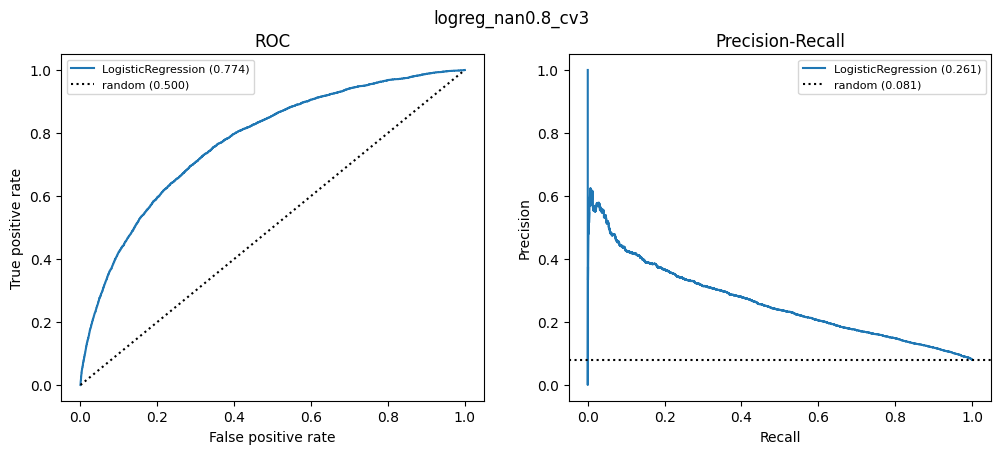

logreg_nan0.8_cv3: curves + confusion matrix attached


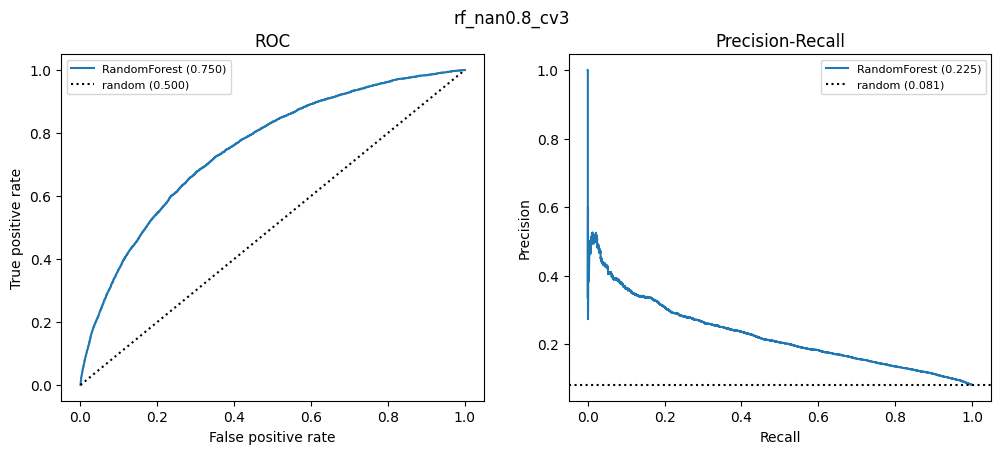

rf_nan0.8_cv3: curves + confusion matrix attached


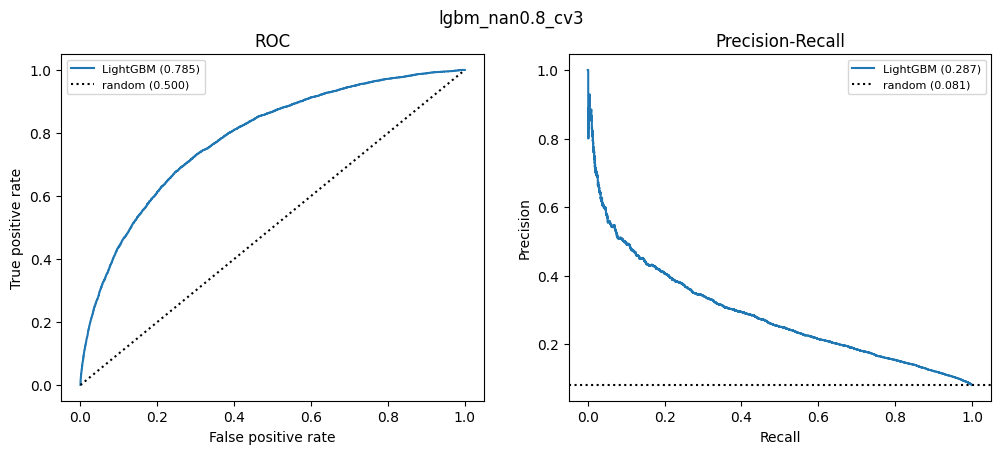

lgbm_nan0.8_cv3: curves + confusion matrix attached


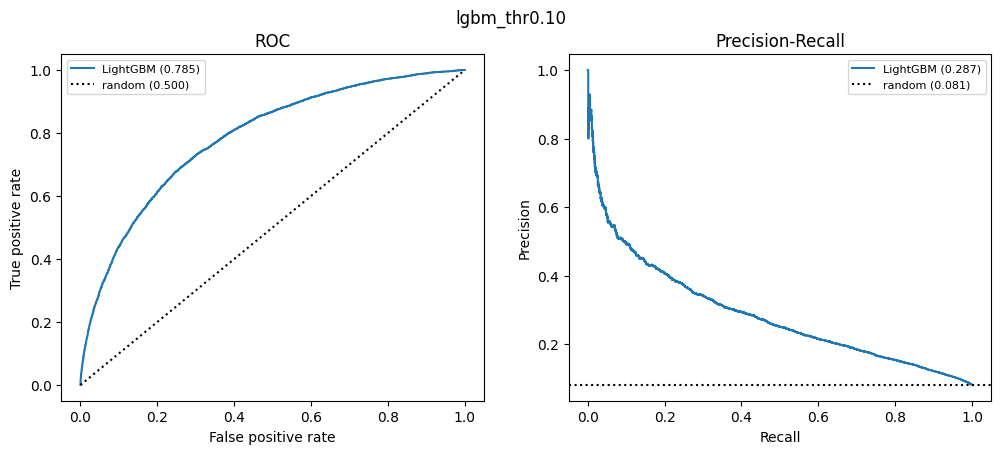

lgbm_thr0.10: curves + confusion matrix attached


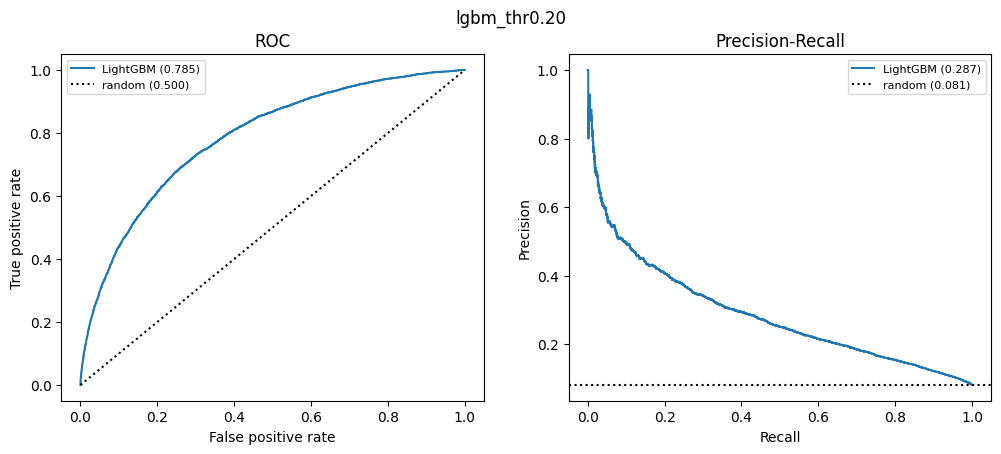

lgbm_thr0.20: curves + confusion matrix attached


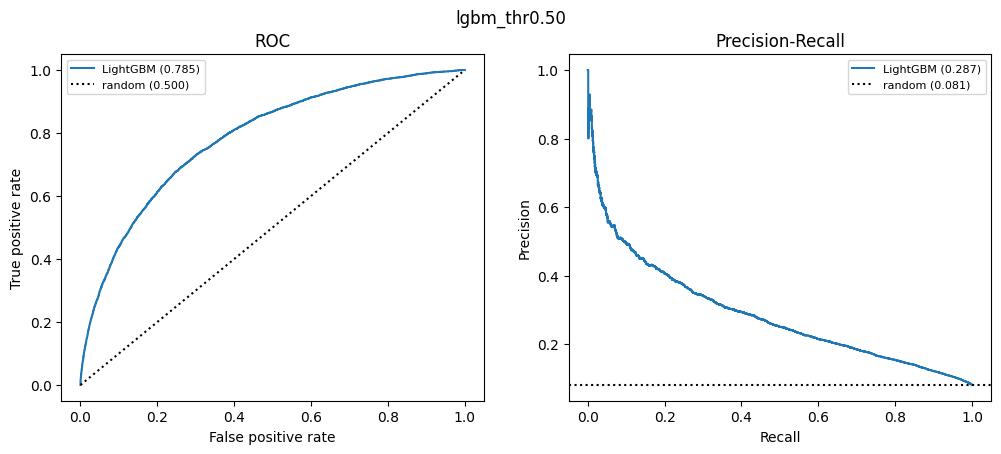

lgbm_thr0.50: curves + confusion matrix attached


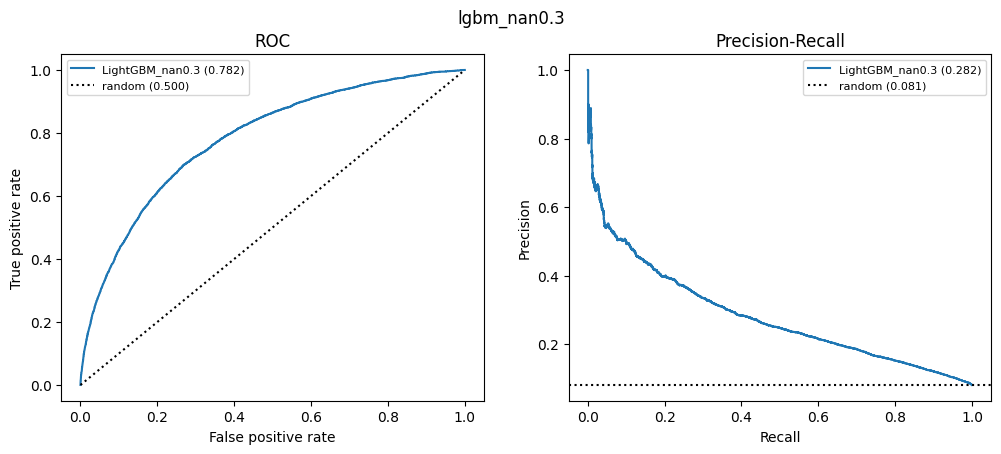

lgbm_nan0.3: curves + confusion matrix attached


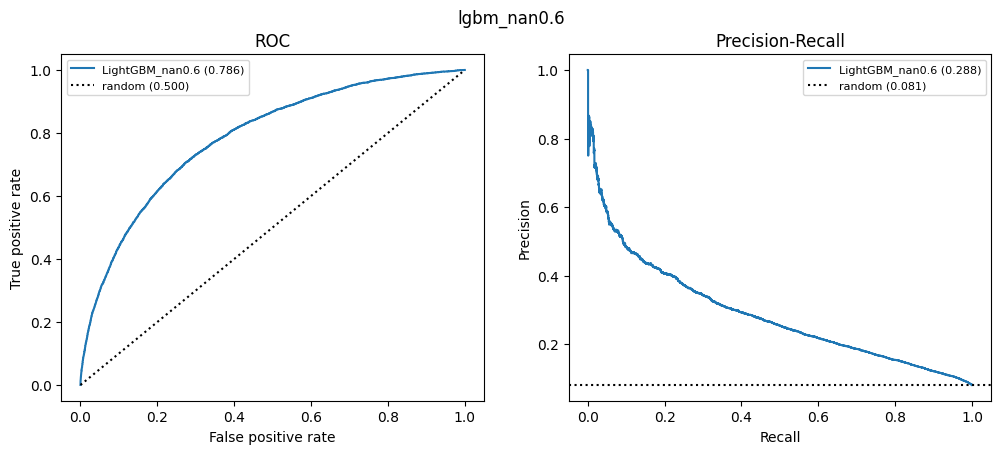

lgbm_nan0.6: curves + confusion matrix attached


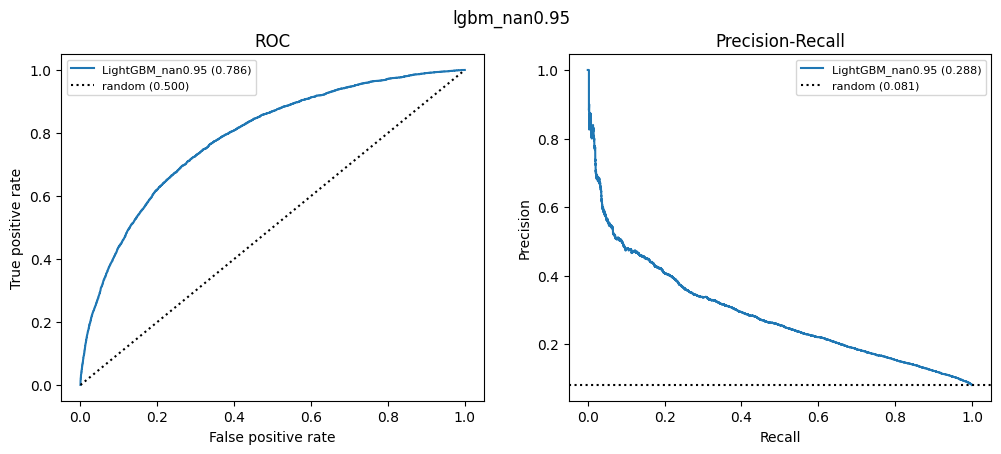

lgbm_nan0.95: curves + confusion matrix attached


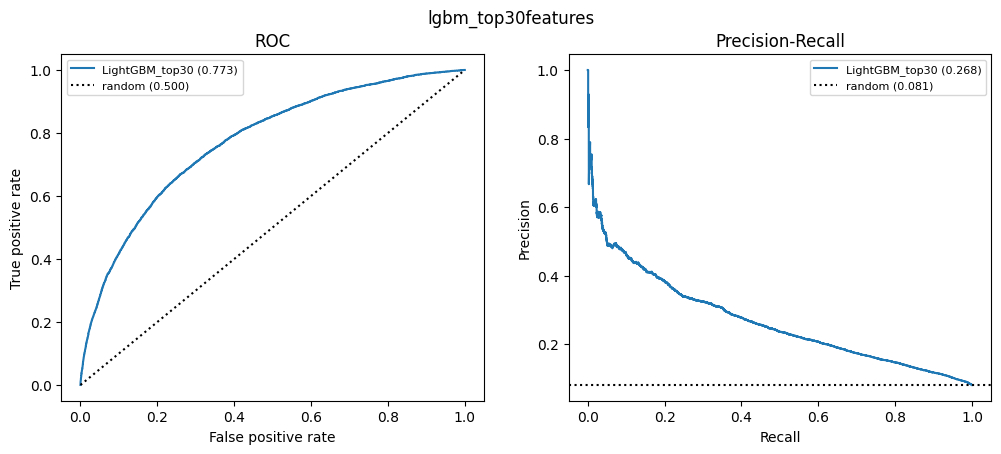

lgbm_top30features: curves + confusion matrix attached


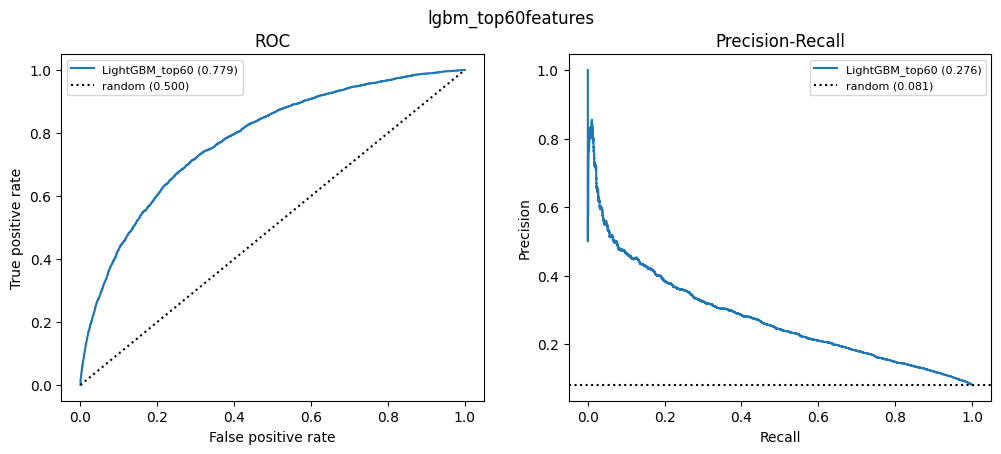

lgbm_top60features: curves + confusion matrix attached


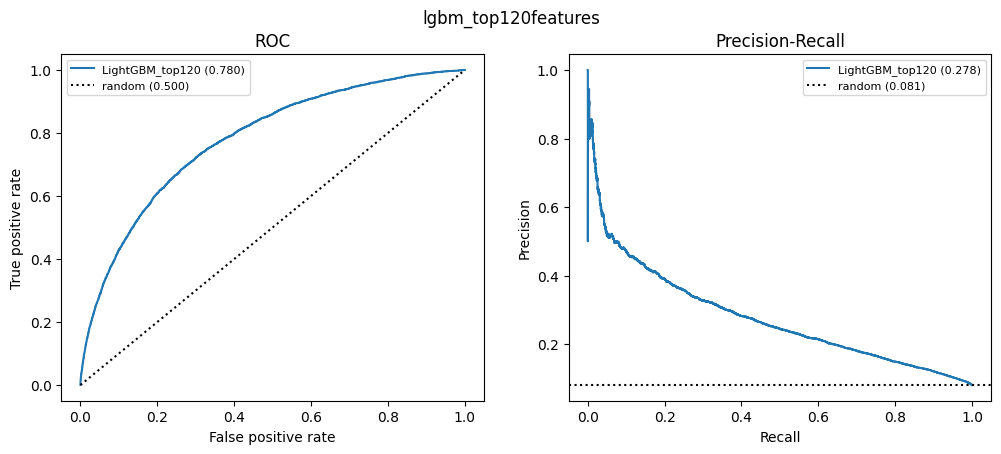

lgbm_top120features: curves + confusion matrix attached


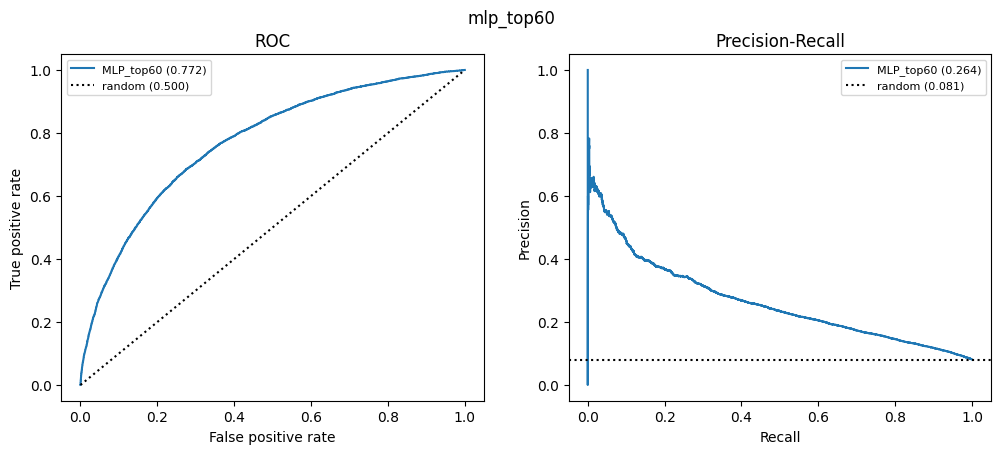

mlp_top60: curves + confusion matrix attached


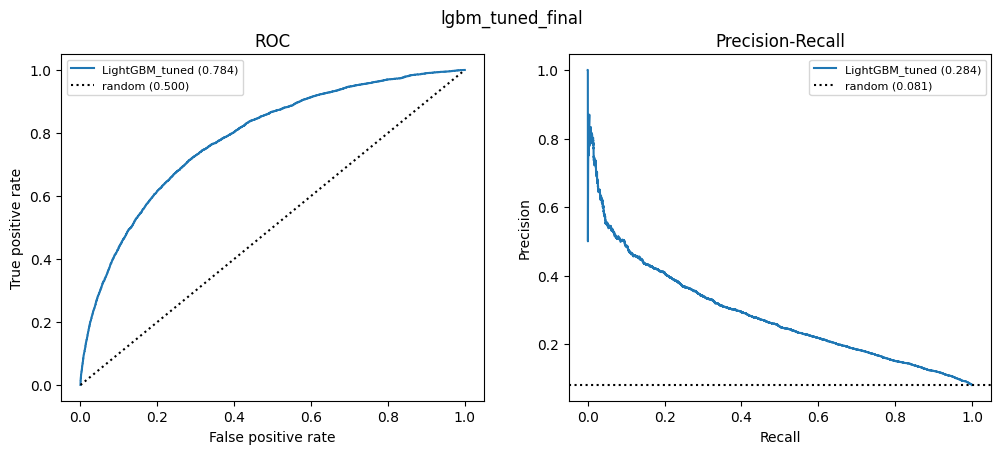

lgbm_tuned_final: curves + confusion matrix attached


In [451]:
from mlflow.tracking import MlflowClient
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

client = MlflowClient()
exp_id = client.get_experiment_by_name("home_credit_scoring").experiment_id

mapping = {
    "runs/cv_logreg":    "logreg_nan0.8_cv3",
    "runs/cv_rf":        "rf_nan0.8_cv3",
    "runs/cv_lgbm":      "lgbm_nan0.8_cv3",
    "runs/thr_010":      "lgbm_thr0.10",
    "runs/thr_020":      "lgbm_thr0.20",
    "runs/thr_050":      "lgbm_thr0.50",
    "runs/lgbm_nan0.3":  "lgbm_nan0.3",
    "runs/lgbm_nan0.6":  "lgbm_nan0.6",
    "runs/lgbm_nan0.95": "lgbm_nan0.95",
    "runs/lgbm_top30":   "lgbm_top30features",
    "runs/lgbm_top60":   "lgbm_top60features",
    "runs/lgbm_top120":  "lgbm_top120features",
    "runs/mlp_top60":    "mlp_top60",
    "runs/lgbm_tuned":   "lgbm_tuned_final",
}

for folder, run_name in mapping.items():
    f = Path(folder)
    if not (f / "model.joblib").exists():
        print(f"skipped {folder} (no saved model)")
        continue

    found = client.search_runs([exp_id], filter_string=f"tags.mlflow.runName = '{run_name}'")
    if not found:
        print(f"no MLflow run named '{run_name}'")
        continue
    run_id = found[0].info.run_id

    pipe_i = joblib.load(f / "model.joblib")
    feats  = [c for c in (f / "features.txt").read_text().split("\n") if c]
    thr    = pd.read_csv(f / "metrics.csv")['best_threshold'].iloc[0]
    pred   = (pipe_i.predict_proba(X_valid[feats])[:, 1] >= thr).astype(int)

    # --- ROC and PR curves
    plot_roc_pr([folder], f / "roc_pr_curves.png", title=run_name)

    # --- confusion matrix at the cost-optimal threshold
    cm = confusion_matrix(y_valid, pred)
    tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['repaid', 'defaulted']).plot(ax=ax, values_format=',d')
    ax.set_title(f"{run_name} (threshold {thr:.2f})")
    fig.savefig(f / "confusion_matrix.png", dpi=100, bbox_inches='tight')
    plt.close(fig)

    # --- push onto the EXISTING run: no new run is created
    client.log_artifact(run_id, str(f / "roc_pr_curves.png"))
    client.log_artifact(run_id, str(f / "confusion_matrix.png"))
    for k, v in {'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}.items():
        client.log_metric(run_id, f"{k}_valid", int(v))

    print(f"{run_name}: curves + confusion matrix attached")

The superimposed figure compares the three model families trained on the same features (LogisticRegression, RandomForest, LightGBM), the tuned LightGBM, and the MLP (trained on the 60 SHAP-selected features only, so not a perfectly fair
comparison). 

The threshold runs are left out on purpose: they reuse the cv_lgbm model and only change the decision threshold, while ROC and PR curves sweep every
threshold, so they would draw the exact same curve four times.

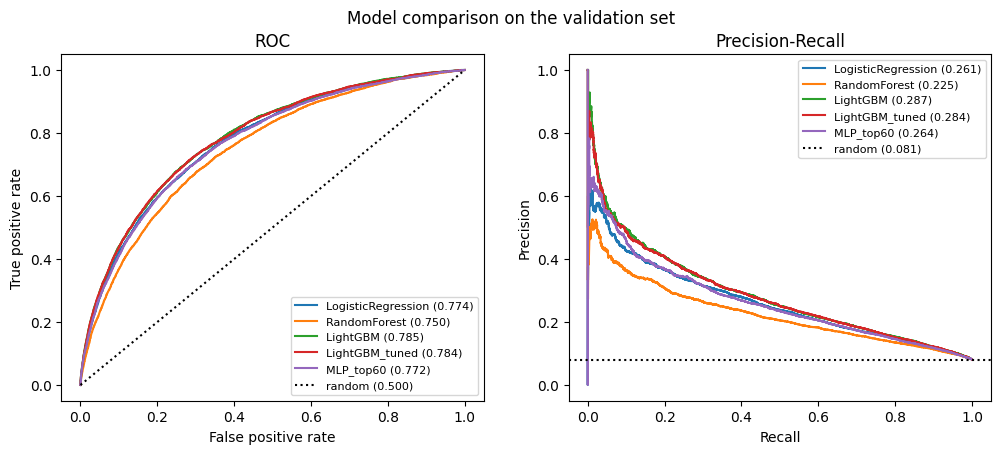

comparison figure attached to logreg_nan0.8_cv3
comparison figure attached to rf_nan0.8_cv3
comparison figure attached to lgbm_nan0.8_cv3
comparison figure attached to lgbm_tuned_final
comparison figure attached to mlp_top60


In [452]:
compared = ['runs/cv_logreg', 'runs/cv_rf', 'runs/cv_lgbm', 'runs/lgbm_tuned', 'runs/mlp_top60']

plot_roc_pr(compared, "runs/model_comparison_curves.png",
            title="Model comparison on the validation set")

# attach the same figure to every run that appears on it
for folder in compared:
    run_name = mapping[folder]
    found = client.search_runs([exp_id], filter_string=f"tags.mlflow.runName = '{run_name}'")
    if found:
        client.log_artifact(found[0].info.run_id, "runs/model_comparison_curves.png")
        print(f"comparison figure attached to {run_name}")

## 9. Final model for the business

**Decision rule**: the model with the lowest business cost per client wins, each model
being evaluated at its own cost-optimal decision threshold, unless a simpler model
is within 1 % of that cost. In that case the model with the fewest input columns is
preferred: every column is a value to compute, monitor and keep available in production.

A business-oriented variant was built to challenge the full model:
- the 60 most important columns from the SHAP analysis instead of 422, with a
  missing-value threshold of 0.80 so that all 60 are kept (SHAP already measured
  that their missingness is informative);
- the hyperparameters selected by GridSearchCV on the full feature set, reused here
  rather than re-searched on 60 features.

| Model | Columns | Business cost per client | Optimal threshold | PR AUC | ROC AUC |
|---|---|---|---|---|---|
| Full model (`lgbm_tuned_final`, version 6) | 422 | 0.4909 | 0.52 | 0.2845 | 0.7844 |
| **Top-60 business model** (`lgbm_top60_business`, version 8) | 60 | 0.4943 | 0.54 | 0.2813 | 0.7832 |

The full model has the lowest business cost (30 192 against 30 402 on the validation
set), but the top-60 model is only 0.7 % more expensive with 7 times fewer input
columns, a gap measured on a single validation split. It is therefore promoted to
**champion** and is the model deployed in the next project. The full model keeps no alias.

An earlier variant with a missing-value threshold of 0.60 (version 7) dropped 3 of the
60 columns and scored slightly worse (30 423).

LightGBM_top60_business | 60 features | AUC valid = 0.7832 | cost@0.5 = 30640 | saved in runs/lgbm_top60_business| best thr = 0.54 -> 30402


LightGBM_top60_business | 60 features | AUC valid = 0.7832 | cost@0.54 = 30402 | saved in runs/lgbm_top60_business| best thr = 0.54 -> 30402
60 features used | decision threshold: 0.54


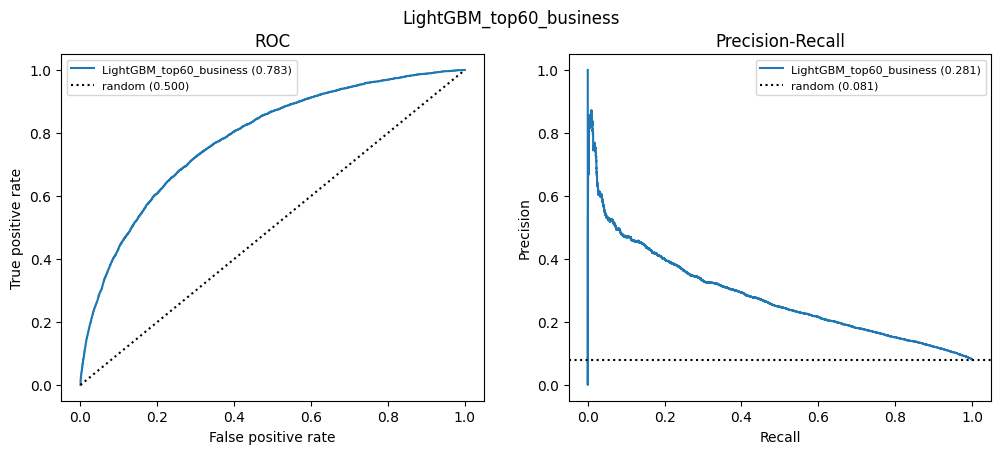

12742 loans refused out of 48744 (26.1%) at threshold 0.54


In [453]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

final_dir = Path("runs/lgbm_top60_business")
NAN_THR   = 0.80    # keeps all 60 SHAP columns: SHAP already measured that their missingness is informative

# --- the 60 most important columns from the aggregated SHAP importance
top60 = [c for c in Path("runs/lgbm_top60/features.txt").read_text().split("\n") if c]

# --- hyperparameters selected by GridSearchCV
lgbm_business = dict(learning_rate=0.04, min_child_samples=100, n_estimators=200, num_leaves=31,
                     class_weight='balanced', random_state=42, verbose=-1)

# --- 1. First fit, only to find this model's own cost-optimal decision threshold
train_and_save(lgb.LGBMClassifier(**lgbm_business), "LightGBM_top60_business", top60, final_dir,
               nan_threshold=NAN_THR)
DECISION_THR = round(float(pd.read_csv(final_dir / "metrics.csv")['best_threshold'].iloc[0]), 2)

# --- 2. Same model (fixed random_state), now reporting every metric at that operating threshold
train_and_save(lgb.LGBMClassifier(**lgbm_business), "LightGBM_top60_business", top60, final_dir,
               nan_threshold=NAN_THR, decision_threshold=DECISION_THR)

# --- 3. Load the saved pipeline once, reuse it for every artifact below
final_pipe = joblib.load(final_dir / "model.joblib")
used_feats = [c for c in (final_dir / "features.txt").read_text().split("\n") if c]
print(f"{len(used_feats)} features used | decision threshold: {DECISION_THR}")

# --- 4. Confusion matrix on the validation set, at the decision threshold
pred_valid = (final_pipe.predict_proba(X_valid[used_feats])[:, 1] >= DECISION_THR).astype(int)
cm = confusion_matrix(y_valid, pred_valid)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=['repaid', 'defaulted']).plot(ax=ax, values_format=',d')
ax.set_title(f"LightGBM_top60_business (threshold {DECISION_THR:.2f})")
fig.savefig(final_dir / "confusion_matrix.png", dpi=100, bbox_inches='tight')
plt.close(fig)

# the four cells are added to metrics.csv, so log_to_mlflow logs them like any other metric
m = pd.read_csv(final_dir / "metrics.csv")
m["tn_valid"], m["fp_valid"], m["fn_valid"], m["tp_valid"] = tn, fp, fn, tp
m.to_csv(final_dir / "metrics.csv", index=False)

# --- 5. ROC and PR curves
plot_roc_pr([final_dir], final_dir / "roc_pr_curves.png", title="LightGBM_top60_business")

# --- 6. Predictions on the unlabelled Kaggle test file, at the same decision threshold
predictions = pd.DataFrame({
    'SK_ID_CURR':    df_test_final['SK_ID_CURR'],
    'proba_default': final_pipe.predict_proba(X_test[used_feats])[:, 1],
})
predictions['decision'] = (predictions['proba_default'] >= DECISION_THR).astype(int)
predictions.to_csv(final_dir / "predictions_test.csv", index=False)

print(f"{predictions['decision'].sum()} loans refused out of {len(predictions)} "
      f"({predictions['decision'].mean():.1%}) at threshold {DECISION_THR}")

In [454]:
log_to_mlflow(final_dir,
              run_name="lgbm_top60_business",
              tags={"phase": "final_business",
                    "model_family": "boosting",
                    "note": "top-60 SHAP features, GridSearchCV hyperparameters, nan_threshold 0.80"},
              register=True)

2026/10/04 19:32:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


lgbm_top60_business logged to MLflow


Registered model 'credit_scoring_model' already exists. Creating a new version of this model...
Created version '8' of model 'credit_scoring_model'.


In [455]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
exp_id = client.get_experiment_by_name("home_credit_scoring").experiment_id

# --- decision rule: the lowest business cost per client wins (each model at its own
#     cost-optimal threshold), unless a simpler model is within 1 % of that cost:
#     then the model with the fewest input columns is preferred
TOLERANCE = 0.01

candidates = {
    "lgbm_tuned_final":    "runs/lgbm_tuned",            # full model
    "lgbm_top60_business": "runs/lgbm_top60_business",   # 60 SHAP columns
}

rows = []
for run_name, d in candidates.items():
    m = pd.read_csv(Path(d) / "metrics.csv").iloc[0]
    p = json.loads((Path(d) / "params.json").read_text())
    rows.append({"run":             run_name,
                 "n_columns":       p["n_features_used"],
                 "cost_per_client": m["best_cost"] / len(y_valid),
                 "best_threshold":  m["best_threshold"],
                 "pr_auc_valid":    m["pr_auc_valid"],
                 "roc_auc_valid":   m["roc_auc_valid"]})

comparison = pd.DataFrame(rows).sort_values("cost_per_client")
comparison["extra_cost"] = comparison["cost_per_client"] / comparison["cost_per_client"].min() - 1
# float_format overrides the global 2-decimal display option set in section B
print(comparison.to_string(index=False, float_format="{:.4f}".format))

# --- among the models within the tolerance, keep the one with the fewest columns
eligible = comparison[comparison["extra_cost"] <= TOLERANCE]
champion = eligible.sort_values("n_columns")["run"].iloc[0]

# --- point the champion alias to the registry version created from the winning run
run     = client.search_runs([exp_id], filter_string=f"tags.mlflow.runName = '{champion}'")[0]
version = client.search_model_versions(
    f"name = 'credit_scoring_model' and run_id = '{run.info.run_id}'")[0].version
client.set_registered_model_alias("credit_scoring_model", "champion", version)
print(f"\nchampion -> {champion} (version {version})")

# --- no challenger alias: a model that is not promoted simply keeps no alias
if "challenger" in client.get_registered_model("credit_scoring_model").aliases:
    client.delete_registered_model_alias("credit_scoring_model", "challenger")
    print("challenger alias removed")

                run  n_columns  cost_per_client  best_threshold  pr_auc_valid  roc_auc_valid  extra_cost
   lgbm_tuned_final        422           0.4909          0.5200        0.2845         0.7844      0.0000
lgbm_top60_business         60           0.4943          0.5400        0.2813         0.7832      0.0070

champion -> lgbm_top60_business (version 8)


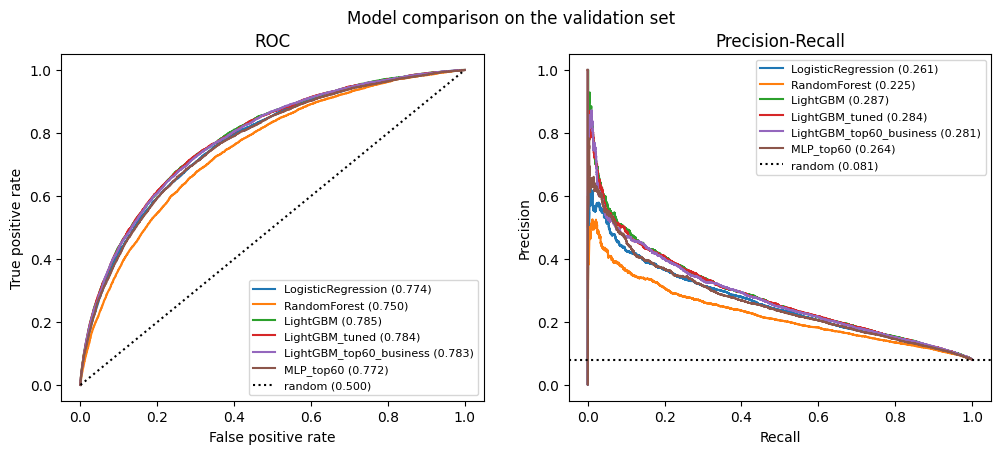

comparison figure attached to logreg_nan0.8_cv3
comparison figure attached to rf_nan0.8_cv3
comparison figure attached to lgbm_nan0.8_cv3
comparison figure attached to lgbm_tuned_final
comparison figure attached to lgbm_top60_business
comparison figure attached to mlp_top60


In [456]:
# one dict instead of a list + a separate mapping: the two can never get out of sync
compared = {
    "runs/cv_logreg":            "logreg_nan0.8_cv3",
    "runs/cv_rf":                "rf_nan0.8_cv3",
    "runs/cv_lgbm":              "lgbm_nan0.8_cv3",
    "runs/lgbm_tuned":           "lgbm_tuned_final",
    "runs/lgbm_top60_business":  "lgbm_top60_business",
    "runs/mlp_top60":            "mlp_top60",
}

plot_roc_pr(list(compared), "runs/model_comparison_curves.png",
            title="Model comparison on the validation set")

for folder_i, run_name in compared.items():
    found = client.search_runs([exp_id], filter_string=f"tags.mlflow.runName = '{run_name}'")
    if found:
        client.log_artifact(found[0].info.run_id, "runs/model_comparison_curves.png")
        print(f"comparison figure attached to {run_name}")